# 📋 Changelog (2026-01-31)

本次重构将原"单阶段用硬/软规则拟合淘汰"的方案，升级为**两阶段训练 + R1 pairwise ranking loss + R3 mixture规则**的新方案。

## 主要改动

### 1. 新增/重构函数
- `loss_r1_pairwise()`: R1 使用 pairwise ranking loss（替代原 softmax-argmax）
- `elim_prob_R3_mixture()`: R3 使用 mixture 规则（替代固定 season>=28 用 rank）
- `train_stageA_R2()`: Stage A 训练函数（仅使用 R2 数据训练 Θ_vote）
- `train_stageB_rules()`: Stage B 训练函数（校准规则层参数 Θ_rule）
- `normalize_rank()`: rank 归一化函数 $\bar{r} = (r-1)/(n-1)$

### 2. 模型参数重构
- **Θ_vote** (Stage A 训练): `alphas`, `raw_rho`, `beta`, `raw_kappa_pct`, `raw_tau_rank`
- **Θ_rule** (Stage B 训练): `raw_omega`, `raw_lambda`, `bias_b2`, `raw_kappa_b2`, `raw_gamma`

### 3. 训练逻辑
- Stage A: 仅使用 R2 (S3-27) 数据，最小化 NLL_R2 + 正则化，保存 checkpoint_vote.pt
- Stage B: 加载 Stage A 参数，冻结 Θ_vote（或软冻结 + anchor 正则），训练 Θ_rule

### 4. R1 改动
- **旧**: `P(elim=i) = softmax(κ·R_i)` 拟合 argmax
- **新**: pairwise loss: $L = \sum_{s \in S} \text{softplus}(-(R_e - R_s)/\delta)$
- 新增 rank 归一化: $\bar{r} = (r-1)/(n-1)$
- 新增 omega 参数: $R_i = \omega \bar{r}^J_i + (1-\omega) \bar{r}^V_i$

### 5. R3 改动
- **旧**: `use_percent_for_b2` 固定为 True/False
- **新**: mixture 规则: $\text{risk}_i = \lambda \cdot \text{risk}^{\text{rank}}_i + (1-\lambda) \cdot \text{risk}^{\text{pct}}_i$
- 新增 bias 截距: $p = \sigma(\text{bias} + \gamma(J_j - J_i))$
- $\lambda$ 可学习，解决"回归 rank 的 season 不确定"问题

### 6. 文档更新
- Section 4 数学模型：更新 R1/R3 公式
- Section 5 规则函数：更新实现说明
- Section 8 训练：拆分为两阶段
- 新增 Sanity Check 单元格

### 7. 输出兼容
- `q1_model_results.csv`: 保持兼容，新增 `stage` 列
- `checkpoint_vote.pt`: Stage A 输出
- `checkpoint_stageB.pt`: Stage B 输出

# 🔬 Model Upgrade: Two-Stage Training + Pairwise R1 + Mixture R3

---

## 为什么原方案拟合差？

### R1 (Season 1-2) 问题

**旧方案**: 使用 `softmax(κ·R)` 拟合 `argmax R`

**问题**:
1. **信息损失**: 连续的 pV 转为离散 rank 丢失精度
2. **softmax 不贴合 argmax**: softmax 拟合的是"分布"，而 argmax 是"不等式约束"（淘汰者综合名次最差）
3. **数据量少**: 仅 11 周数据，参数过拟合风险高

### R3 (Season ≥28) 问题

**旧方案**: 固定 `use_percent_for_b2=True/False`，硬编码 season≥28 使用 rank

**问题**:
1. **规则不确定**: 题面说"around this same season 回归 rank"，但确切 season 不确定
2. **潜变量 Bottom-2**: 无法观测，只能通过淘汰结果间接推断
3. **评委投票随机性**: 即使 Bottom-2 正确，评委投票仍有不确定性

---

## 新方案如何修复

### 两阶段训练

| 阶段 | 数据 | 训练参数 | 损失函数 |
|------|------|----------|----------|
| **Stage A** | R2 (S3-27) | Θ_vote (alpha, rho, beta, kappa_pct, tau_rank) | NLL_R2 + 正则化 |
| **Stage B** | R1 + R3 | Θ_rule (omega, lambda, bias, kappa_b2, gamma) | L_R1_pairwise + NLL_R3 |

**优势**:
- R2 有 194 周强信号数据，先学好投票动力学 Θ_vote
- Stage B 冻结 Θ_vote，仅校准规则层参数，避免过拟合

### R1: Pairwise Ranking Loss

**新公式**:
1. Rank 归一化: $\bar{r}_i = \frac{r_i - 1}{n - 1}$ (映射到 [0,1])
2. 合成风险: $R_i = \omega \bar{r}^J_i + (1-\omega) \bar{r}^V_i$, 其中 $\omega = \sigma(\text{raw}_\omega)$
3. Pairwise loss: $L = \sum_{s \in S} \text{softplus}\left(\frac{R_s - R_e}{\delta}\right)$ (淘汰者 e 的 R 应该比幸存者 s 大)

**优势**: 直接优化"淘汰者风险比幸存者高"的不等式约束，不需要拟合概率分布

### R3: Mixture 规则

**新公式**:
1. 混合风险: $\text{risk}_i = \lambda \cdot \text{risk}^{\text{rank}}_i + (1-\lambda) \cdot \text{risk}^{\text{pct}}_i$
2. $\lambda = \sigma(\text{raw}_\lambda)$ 可学习，自动适应"回归 rank"的程度
3. 评委投票加 bias: $p = \sigma(\text{bias} + \gamma(J_j - J_i))$

**优势**: 
- 不需要硬编码 season 阈值
- 模型自动学习 rank vs percent 的混合权重

---

## 淘汰规则概述（与题面一致）

| 季 | 规则 | 合并方式 | 淘汰依据 |
|---|---|---|---|
| Season 1–2 | R1 | Rank 合并 | $R_i = r^J_i + r^V_i$，淘汰综合排名最差者 |
| Season 3–27 | R2 | Percent 合并 | $C_i = p^J_i + p^V_i$，淘汰综合得分最低者 |
| Season ≥28 | R3 | Bottom-2 + 评委投票 | 先定 bottom-2（规则不确定，可能用 rank 或 percent），再由评委多数票决定淘汰谁 |

**关键**: Season ≥28 的 bottom-2 选择方式存在不确定性（rank vs percent），本模型使用 **mixture 参数 λ** 自动估计。

# MCM 2026 Problem C 第1问：动态 Plackett-Luce 模型估计观众票份额

---

## 📚 问题背景与建模目标

**Dancing with the Stars (DWTS)** 是一档著名的真人秀舞蹈竞技节目。每周，参赛者（celebrity）与专业舞伴搭档表演，获得：
1. **评委评分**（Judge Scores）：$J_i$ 分数
2. **观众投票**（Viewer Votes）：$V_i$ 票数

每周末根据规则淘汰一名或多名选手。**核心挑战**：观众投票的**绝对数量不公开**，我们只能观测到淘汰结果。

### 🎯 本教程目标

1. **估计观众票份额** $p^V_{i,t}$：利用动态 Plackett-Luce (dPL) 模型，从淘汰结果"反推"每位选手每周的观众支持程度
2. **预测淘汰概率** $P(\text{elim}=i)$：根据不同季的规则，计算可微的淘汰概率
3. **量化不确定性**：通过 bootstrap 评估票份额估计的可信度

### 📋 淘汰规则概述（与题面一致）

| 季 | 规则 | 合并方式 | 淘汰依据 |
|---|---|---|---|
| Season 1–2 | R1 | Rank 合并 | $R_i = r^J_i + r^V_i$，淘汰综合排名最差者 |
| Season 3–27 | R2 | Percent 合并 | $C_i = p^J_i + p^V_i$，淘汰综合得分最低者 |
| Season ≥28 | R3 | Bottom-2 + 评委投票 | 先定 bottom-2，再由评委多数票决定淘汰谁；**底部选择方式存在不确定性（rank vs percent），使用 mixture 参数估计** |

### 📊 核心数学模型：动态 Plackett-Luce

对于每位选手 $i$ 在第 $t$ 周，定义 **log-worth**：

$$\eta_{i,t} = \rho \cdot \eta_{i,t-1} + (1-\rho) \cdot \alpha_i + \boldsymbol{\beta}^\top \mathbf{x}_{i,t}$$

其中：
- $\alpha_i$：选手 $i$ 的长期基线人气（每季独立参数）
- $\rho \in (0,1)$：惯性参数（历史 vs 当期的权重）
- $\mathbf{x}_{i,t}$：协变量特征（Google Trends 热度等）
- $\boldsymbol{\beta}$：协变量系数（全局共享）

**观众票份额**（softmax over 当周在场选手 $S_t$）：

$$p^V_{i,t} = \frac{\exp(\eta_{i,t})}{\sum_{j \in S_t} \exp(\eta_{j,t})}$$

### 🔄 两阶段训练策略

本模型采用**两阶段训练**，解决 R1/R3 规则数据量少、信号弱的问题：

- **Stage A**: 仅使用 R2 (S3-27, 194周) 训练投票动力学参数 Θ_vote
- **Stage B**: 冻结 Θ_vote，使用 R1+R3 校准规则层参数 Θ_rule

---

**作者**：数据科学建模教程  
**数据来源**：`processed_with_trends.csv`（MCM 2026 官方数据 + Google Trends）  
**最后更新**：2026年1月

## 1. 环境配置与依赖导入

本节设置运行环境：
- 固定随机种子确保可复现性
- 导入必要的数据科学库
- 配置可视化参数

**依赖列表**：
- `pandas`, `numpy`：数据处理
- `matplotlib`, `seaborn`：可视化
- `torch`：自动微分优化（若未安装会给出安装命令）
- `scipy`：统计函数（可选）

In [1]:
# =============================================================================
# 1.1 随机种子固定 & 基础库导入
# =============================================================================
# 固定所有随机种子，确保实验可复现
import random
import numpy as np
import warnings

SEED = 42  # 全局随机种子
random.seed(SEED)
np.random.seed(SEED)

# 忽略不必要的警告
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# 数据处理
import pandas as pd
pd.set_option('display.max_columns', 50)  # 显示更多列
pd.set_option('display.width', 200)       # 加宽显示

# 可视化
import matplotlib.pyplot as plt
import matplotlib as mpl
# 设置中文字体（macOS 使用 PingFang，其他系统可能需要调整）
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
plt.rcParams['figure.figsize'] = (12, 6)    # 默认图形大小
plt.rcParams['figure.dpi'] = 100            # 图形分辨率

# 尝试导入 seaborn
try:
    import seaborn as sns
    sns.set_style('whitegrid')
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False
    print("⚠️ seaborn 未安装，将使用 matplotlib 基础样式")

print(f"✅ 基础环境配置完成")
print(f"   - NumPy 版本: {np.__version__}")
print(f"   - Pandas 版本: {pd.__version__}")
print(f"   - 随机种子: {SEED}")

✅ 基础环境配置完成
   - NumPy 版本: 2.4.1
   - Pandas 版本: 3.0.0
   - 随机种子: 42


In [2]:
# =============================================================================
# 1.2 PyTorch 导入（用于自动微分优化）
# =============================================================================
# PyTorch 用于自动求导，方便优化复杂的似然函数
# 如果未安装，取消下方注释运行安装命令

# !pip install torch  # 取消注释以安装 PyTorch

try:
    import torch
    import torch.nn.functional as F
    # 固定 PyTorch 随机种子
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    # 设置默认数据类型为 float64（提高数值精度）
    torch.set_default_dtype(torch.float64)
    HAS_TORCH = True
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"✅ PyTorch 版本: {torch.__version__}")
    print(f"   - 计算设备: {DEVICE}")
except ImportError:
    HAS_TORCH = False
    DEVICE = None
    print("❌ PyTorch 未安装！")
    print("   请运行: pip install torch")
    print("   本教程将无法执行优化部分")

# 导入 scipy 用于统计函数
try:
    from scipy import stats
    from scipy.special import comb, expit, softmax  # expit = sigmoid
    HAS_SCIPY = True
    print(f"✅ SciPy 已导入")
except ImportError:
    HAS_SCIPY = False
    print("⚠️ SciPy 未安装，部分功能可能受限")

✅ PyTorch 版本: 2.10.0
   - 计算设备: cpu
✅ SciPy 已导入


## 2. 数据读取与探索性分析

### 2.1 目的
- 加载 `processed_with_trends.csv` 数据集
- 验证关键字段是否存在
- 了解数据规模、缺失情况、淘汰模式

### 2.2 关键字段说明

| 字段 | 说明 |
|------|------|
| `season`, `week` | 季和周编号 |
| `celebrity_name` | 参赛者姓名 |
| `in_competition` | 该周是否仍在比赛中 |
| `performed` | 该周是否有表演 |
| `eliminated_end_of_week` | 是否在该周末被淘汰 |
| `results` | 最终结果（含 "Withdrew" 退赛）|
| `j_total`, `j_pct`, `j_rank` | 评委总分、百分比份额、排名 |
| `judge_n` | 评委人数 |
| `trend_used` | Google Trends 搜索热度 |

In [3]:
# =============================================================================
# 2.1 加载数据
# =============================================================================
# 数据文件路径（相对于 Placket 目录）
DATA_PATH = '../data/processed_with_trends.csv'

# 读取 CSV 文件
df_raw = pd.read_csv(DATA_PATH)

print(f"📊 数据集规模: {df_raw.shape[0]:,} 行 × {df_raw.shape[1]} 列")
print(f"📅 季数范围: Season {df_raw['season'].min()} ~ {df_raw['season'].max()}")
print(f"👥 参赛者数: {df_raw['celebrity_name'].nunique()} 人")
print()

# 显示前5行
print("数据预览（前5行）：")
df_raw.head()

📊 数据集规模: 4,631 行 × 40 列
📅 季数范围: Season 1 ~ 34
👥 参赛者数: 408 人

数据预览（前5行）：


,season,week,week_exists,season_len,celebrity_name,ballroom_partner,celebrity_industry,celebrity_homestate,celebrity_homecountry_region,celebrity_age_during_season,results,placement,judge_n,n_alive_w,performed,in_competition,elim_week,eliminated_end_of_week,j_total_raw,j_mean_raw,j_sd_raw,j_total,j_mean,j_sd,j_rank,tie_flag,j_points_rank,j_pct,j_z_within_week,delta_j_total,week_start,week_end,num_episodes,trend_date,window_start,window_end,trend_preday,trend_startday,trend_used_window_mean,trend_used
0,1,1,True,6,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,Eliminated Week 3,5,3,6,True,True,3,False,18.0,6.000000,1.00000,18.0,6.000000,1.00000,4.5,True,2.5,0.165138,-0.061406,NaN,2005/6/1,2005/6/7,1.0,2005/5/31,2005/6/1,2005/6/1,NaN,0.0,0.0,0.0
1,1,1,True,6,Joey McIntyre,Ashly DelGrosso,Singer/Rapper,Massachusetts,United States,32,3rd Place,3,3,6,True,True,5,False,20.0,6.666667,0.57735,20.0,6.666667,0.57735,2.0,True,5.0,0.183486,0.675470,NaN,2005/6/1,2005/6/7,1.0,2005/5/31,2005/6/1,2005/6/1,NaN,0.0,0.0,0.0
2,1,1,True,6,John O'Hurley,Charlotte Jorgensen,Actor/Actress,Maine,United States,50,2nd Place,2,3,6,True,True,6,False,20.0,6.666667,0.57735,20.0,6.666667,0.57735,2.0,True,5.0,0.183486,0.675470,NaN,2005/6/1,2005/6/7,1.0,2005/5/31,2005/6/1,2005/6/1,NaN,0.0,0.0,0.0
3,1,1,True,6,Kelly Monaco,Alec Mazo,Actor/Actress,Pennsylvania,United States,29,1st Place,1,3,6,True,True,6,False,13.0,4.333333,0.57735,13.0,4.333333,0.57735,6.0,False,1.0,0.119266,-1.903597,NaN,2005/6/1,2005/6/7,1.0,2005/5/31,2005/6/1,2005/6/1,NaN,5.0,5.0,5.0
4,1,1,True,6,Rachel Hunter,Jonathan Roberts,Model,NaN,New Zealand,35,Eliminated Week 4,4,3,6,True,True,4,False,20.0,6.666667,0.57735,20.0,6.666667,0.57735,2.0,True,5.0,0.183486,0.675470,NaN,2005/6/1,2005/6/7,1.0,2005/5/31,2005/6/1,2005/6/1,NaN,50.0,50.0,50.0


In [4]:
# =============================================================================
# H21: Generate Table of Figures
# =============================================================================
import os
from pathlib import Path
from IPython.display import display, Markdown

# Define figure directory
fig_dir = Path('../figures')

# Define all figures with descriptions
figure_catalog = {
    # Section A: Data Quality & Structure
    'A1_missing_value_heatmap.png': ('A1', 'Missing Value Heatmap', 'Data Quality', 'Shows missing data patterns across columns'),
    'A2_alive_count_by_week.png': ('A2', 'Alive Contestant Count by Week', 'Data Quality', 'Tracks remaining contestants per season'),
    'A3_elimination_distribution.png': ('A3', 'Elimination Count Distribution', 'Data Quality', 'Histogram and stacked bar of eliminations'),
    'A4_withdrew_events.png': ('A4', 'Withdrew Events Timeline', 'Data Quality', 'Withdrawal events by season and week'),
    
    # Section B: Trends
    'B5_trend_distribution_comparison.png': ('B5', 'Trend Distribution Comparison', 'Trends', 'Raw vs normalized trend_used'),
    'B6_contestant_trend_curves.png': ('B6', 'Contestant Trend Curves', 'Trends', 'Representative trend trajectories with elimination markers'),
    
    # Section C: Training Diagnostics
    'C7_training_loss_with_stages.png': ('C7', 'Training Loss with Stage Markers', 'Training', 'Loss curve with staged training visualization'),
    'C8_parameter_trajectory.png': ('C8', 'Parameter Trajectory', 'Training', 'Parameter values at each training stage'),
    
    # Section D: Core Outputs
    'D9_pV_heatmap.png': ('D9', 'pV Heatmap', 'Core Outputs', 'Vote share heatmap by contestant × week'),
    'D10_pV_with_CI_bands.png': ('D10', 'pV with CI Bands', 'Core Outputs', 'Vote share with bootstrap confidence intervals'),
    'D11_elimination_prob_bars.png': ('D11', 'Elimination Probability Bars', 'Core Outputs', 'pE bar charts for selected weeks'),
    'D12_rule_switch_timeline.png': ('D12', 'Rule Switch Timeline', 'Core Outputs', 'pV/pE evolution with rule change markers'),
    
    # Section E: Consistency
    'E13_pV_sum_verification.png': ('E13', 'pV Sum Verification', 'Consistency', 'Verifies Σp_V = 1 constraint'),
    'E14_metrics_by_rule.png': ('E14', 'Metrics by Rule', 'Consistency', 'Performance comparison across rule types'),
    
    # Section F: Confidence
    'F15_ci_width_distribution.png': ('F15', 'CI Width Distribution', 'Confidence', 'Bootstrap CI width analysis'),
    'F16_parameter_bootstrap.png': ('F16', 'Parameter Bootstrap', 'Confidence', 'Parameter uncertainty quantification'),
    'F17_eliminated_vs_survived_ci.png': ('F17', 'Eliminated vs Survived CI', 'Confidence', 'CI comparison by outcome'),
    
    # Section G: Calibration
    'G18_calibration_curve_with_ci.png': ('G18', 'Calibration Curve with CI', 'Calibration', 'Predicted vs actual with confidence bands'),
    'G19_reliability_diagram.png': ('G19', 'Reliability Diagram', 'Calibration', 'Combined calibration and histogram'),
    'G20_brier_decomposition.png': ('G20', 'Brier Score Decomposition', 'Calibration', 'REL-RES-UNC breakdown'),
    
    # Original figures (from earlier sections)
    '08_training_loss_curves.png': ('08', 'Training Loss Curves', 'Training', 'Original training visualization'),
    '09_pV_by_week.png': ('09a', 'pV by Week', 'Core Outputs', 'Vote share trajectories'),
    '09_pV_relationships.png': ('09b', 'pV Relationships', 'Core Outputs', 'Trend-judge share correlations'),
    '09_elim_prob_examples.png': ('09c', 'Elimination Probability Examples', 'Core Outputs', 'Selected week pE bars'),
    '10_metrics_by_rule.png': ('10', 'Metrics by Rule (Original)', 'Consistency', 'Original rule comparison'),
    '11_bootstrap_ci.png': ('11a', 'Bootstrap CI', 'Confidence', 'Original CI visualization'),
    '11_calibration_curve.png': ('11b', 'Calibration Curve (Original)', 'Calibration', 'Original calibration plot'),
}

# Build markdown table
md_lines = ['# 📊 Table of Figures\n']
md_lines.append('| ID | Figure Name | Section | Description | Exists |')
md_lines.append('|:---|:------------|:--------|:------------|:------:|')

for filename, (fig_id, name, section, desc) in sorted(figure_catalog.items(), key=lambda x: x[1][0]):
    exists = '✅' if (fig_dir / filename).exists() else '❌'
    md_lines.append(f'| {fig_id} | {name} | {section} | {desc} | {exists} |')

md_lines.append('\n---')
md_lines.append(f'\n**Total Figures Defined**: {len(figure_catalog)}')
existing_count = sum(1 for f in figure_catalog if (fig_dir / f).exists())
md_lines.append(f'\n**Figures Generated**: {existing_count}/{len(figure_catalog)}')

# Display table
display(Markdown('\n'.join(md_lines)))

print("\n✅ Figure directory generated successfully!")

# 📊 Table of Figures

| ID | Figure Name | Section | Description | Exists |
|:---|:------------|:--------|:------------|:------:|
| 08 | Training Loss Curves | Training | Original training visualization | ✅ |
| 09a | pV by Week | Core Outputs | Vote share trajectories | ✅ |
| 09b | pV Relationships | Core Outputs | Trend-judge share correlations | ✅ |
| 09c | Elimination Probability Examples | Core Outputs | Selected week pE bars | ✅ |
| 10 | Metrics by Rule (Original) | Consistency | Original rule comparison | ✅ |
| 11a | Bootstrap CI | Confidence | Original CI visualization | ✅ |
| 11b | Calibration Curve (Original) | Calibration | Original calibration plot | ✅ |
| A1 | Missing Value Heatmap | Data Quality | Shows missing data patterns across columns | ✅ |
| A2 | Alive Contestant Count by Week | Data Quality | Tracks remaining contestants per season | ✅ |
| A3 | Elimination Count Distribution | Data Quality | Histogram and stacked bar of eliminations | ✅ |
| A4 | Withdrew Events Timeline | Data Quality | Withdrawal events by season and week | ✅ |
| B5 | Trend Distribution Comparison | Trends | Raw vs normalized trend_used | ✅ |
| B6 | Contestant Trend Curves | Trends | Representative trend trajectories with elimination markers | ✅ |
| C7 | Training Loss with Stage Markers | Training | Loss curve with staged training visualization | ✅ |
| C8 | Parameter Trajectory | Training | Parameter values at each training stage | ❌ |
| D10 | pV with CI Bands | Core Outputs | Vote share with bootstrap confidence intervals | ✅ |
| D11 | Elimination Probability Bars | Core Outputs | pE bar charts for selected weeks | ✅ |
| D12 | Rule Switch Timeline | Core Outputs | pV/pE evolution with rule change markers | ✅ |
| D9 | pV Heatmap | Core Outputs | Vote share heatmap by contestant × week | ✅ |
| E13 | pV Sum Verification | Consistency | Verifies Σp_V = 1 constraint | ✅ |
| E14 | Metrics by Rule | Consistency | Performance comparison across rule types | ✅ |
| F15 | CI Width Distribution | Confidence | Bootstrap CI width analysis | ✅ |
| F16 | Parameter Bootstrap | Confidence | Parameter uncertainty quantification | ✅ |
| F17 | Eliminated vs Survived CI | Confidence | CI comparison by outcome | ❌ |
| G18 | Calibration Curve with CI | Calibration | Predicted vs actual with confidence bands | ❌ |
| G19 | Reliability Diagram | Calibration | Combined calibration and histogram | ❌ |
| G20 | Brier Score Decomposition | Calibration | REL-RES-UNC breakdown | ❌ |

---

**Total Figures Defined**: 27

**Figures Generated**: 22/27


✅ Figure directory generated successfully!


**图表目录说明**

上表列出本 Notebook 生成的所有可视化图表，包括：
- **ID**: 图表编号（按章节组织）
- **Figure Name**: 图表名称（英文）
- **Section**: 所属章节
- **Description**: 简要描述
- **Exists**: 是否已生成（✅=已生成，❌=未生成）

运行完整 Notebook 后所有图表将保存至 `../figures/` 目录，可直接用于论文插图。

## 3. 数据清洗与建模样本构造

### 3.1 目的
- 筛选有效建模样本：`in_competition==True & performed==True`
- 构造每周的在场选手集合 $S_t$ 和淘汰集合 $E_t$
- 处理 Withdrew（退赛）观测
- 创建规则分段标识（R1/R2/R3）

### 3.2 实现要点
- 数据必须按 `(season, week)` 排序
- 每个选手在每季内按周序编号（用于动态模型的时序递推）
- 标记多淘汰周以便后续特殊处理

In [5]:
# =============================================================================
# 3.1 筛选有效建模样本
# =============================================================================
print("=" * 60)
print("📊 构造建模样本")
print("=" * 60)

# 筛选条件：在比赛中 且 有表演
df_model = df_raw[(df_raw['in_competition'] == True) & (df_raw['performed'] == True)].copy()

# 按 season, week, celebrity_name 排序
df_model = df_model.sort_values(['season', 'week', 'celebrity_name']).reset_index(drop=True)

print(f"原始数据行数: {len(df_raw):,}")
print(f"建模样本行数: {len(df_model):,}")
print(f"过滤比例: {(1-len(df_model)/len(df_raw))*100:.1f}%")

# 添加规则分段标识
# R1: Season 1-2 (Rank 合并)
# R2: Season 3-27 (Percent 合并)  
# R3: Season >= 28 (Bottom-2 + 评委投票)
def get_rule_type(season):
    """根据季数返回规则类型"""
    if season <= 2:
        return 'R1_Rank'
    elif season <= 27:
        return 'R2_Percent'
    else:
        return 'R3_Bottom2'

df_model['rule_type'] = df_model['season'].apply(get_rule_type)

print(f"\n规则分段统计：")
print(df_model.groupby('rule_type')['season'].agg(['min', 'max', 'count']))

📊 构造建模样本
原始数据行数: 4,631
建模样本行数: 2,777
过滤比例: 40.0%

规则分段统计：
            min  max  count
rule_type                  
R1_Rank       1    2     78
R2_Percent    3   27   1997
R3_Bottom2   28   34    702


In [6]:
# =============================================================================
# 3.2 构造每周的在场集合 S_t 与淘汰集合 E_t
# =============================================================================
print("=" * 60)
print("📊 构造在场/淘汰集合")
print("=" * 60)

# 标记 Withdrew（退赛）
df_model['is_withdrew'] = df_model['results'].str.contains('Withdrew', case=False, na=False)

# 为每个 (season, week) 创建汇总信息
week_summary = df_model.groupby(['season', 'week']).agg(
    n_alive=('celebrity_name', 'count'),                          # 在场人数
    n_elim=('eliminated_end_of_week', 'sum'),                      # 淘汰人数
    n_withdrew=('is_withdrew', lambda x: (x & df_model.loc[x.index, 'eliminated_end_of_week']).sum()),  # 退赛人数
    rule=('rule_type', 'first'),                                   # 规则类型
    judge_n=('judge_n', 'first')                                   # 评委人数
).reset_index()

# 标记多淘汰周
week_summary['is_multi_elim'] = week_summary['n_elim'] >= 2
week_summary['is_zero_elim'] = week_summary['n_elim'] == 0

print(f"总周数: {len(week_summary)}")
print(f"多淘汰周: {week_summary['is_multi_elim'].sum()}")
print(f"零淘汰周: {week_summary['is_zero_elim'].sum()}")
print(f"含退赛的淘汰周: {(week_summary['n_withdrew'] > 0).sum()}")

# 将汇总信息合并回主表
df_model = df_model.merge(
    week_summary[['season', 'week', 'n_alive', 'n_elim', 'is_multi_elim', 'is_zero_elim']],
    on=['season', 'week'],
    how='left'
)

print("\n周汇总统计预览：")
week_summary.head(10)

📊 构造在场/淘汰集合
总周数: 335
多淘汰周: 40
零淘汰周: 74
含退赛的淘汰周: 10

周汇总统计预览：


,season,week,n_alive,n_elim,n_withdrew,rule,judge_n,is_multi_elim,is_zero_elim
0,1,1,6,0,0,R1_Rank,3,False,True
1,1,2,6,1,0,R1_Rank,3,False,False
2,1,3,5,1,0,R1_Rank,3,False,False
3,1,4,4,1,0,R1_Rank,3,False,False
4,1,5,3,1,0,R1_Rank,3,False,False
5,1,6,2,0,0,R1_Rank,3,False,True
6,2,1,10,1,0,R1_Rank,3,False,False
7,2,2,9,1,0,R1_Rank,3,False,False
8,2,3,8,1,0,R1_Rank,3,False,False
9,2,4,7,1,0,R1_Rank,3,False,False


In [7]:
# =============================================================================
# 3.3 构造选手编码与周内索引
# =============================================================================
print("=" * 60)
print("📊 构造选手编码与索引")
print("=" * 60)

# 为每个 season 内的选手创建唯一编号（从0开始）
# 这将用于参数矩阵的索引
df_model['celeb_id_in_season'] = df_model.groupby('season')['celebrity_name'].transform(
    lambda x: pd.factorize(x)[0]
)

# 为每个 (season, week) 内的选手创建当周索引
df_model['idx_in_week'] = df_model.groupby(['season', 'week']).cumcount()

# 统计每季选手数
celebs_per_season = df_model.groupby('season')['celeb_id_in_season'].max() + 1
print(f"每季选手数范围: {celebs_per_season.min()} ~ {celebs_per_season.max()}")
print(f"最大选手数的季: Season {celebs_per_season.idxmax()} ({celebs_per_season.max()}人)")

# 创建 (season, celeb_id) -> celeb_name 映射
celeb_mapping = df_model.groupby(['season', 'celeb_id_in_season'])['celebrity_name'].first().to_dict()
print(f"\n总计 (season, celeb_id) 组合数: {len(celeb_mapping)}")

# 显示 Season 1 的选手编码
print("\nSeason 1 选手编码示例：")
s1_celebs = df_model[df_model['season']==1][['celebrity_name', 'celeb_id_in_season']].drop_duplicates()
print(s1_celebs.to_string(index=False))

📊 构造选手编码与索引
每季选手数范围: 6 ~ 16
最大选手数的季: Season 9 (16人)

总计 (season, celeb_id) 组合数: 421

Season 1 选手编码示例：
   celebrity_name  celeb_id_in_season
Evander Holyfield                   0
    Joey McIntyre                   1
    John O'Hurley                   2
     Kelly Monaco                   3
    Rachel Hunter                   4
    Trista Sutter                   5


In [8]:
# =============================================================================
# 3.4 构造 Google Trends 特征
# =============================================================================
print("=" * 60)
print("📊 构造 Trend 特征")
print("=" * 60)

# 平滑常数（避免 log(0)）
TREND_SMOOTH = 1.0

# 计算每周相对热度 q_it = (trend_used + c) / sum(trend_used + c)
def compute_relative_trend(group):
    """计算组内相对热度"""
    trend_vals = group['trend_used'].fillna(0) + TREND_SMOOTH
    total = trend_vals.sum()
    return trend_vals / total if total > 0 else trend_vals * 0

df_model['trend_relative'] = df_model.groupby(['season', 'week']).apply(
    lambda g: compute_relative_trend(g)
).reset_index(level=[0,1], drop=True)

# 计算 log(q_it)
df_model['log_trend_rel'] = np.log(df_model['trend_relative'] + 1e-10)

# 计算趋势缺失指示
# 如果整周所有人 trend_used 都是 0 或 NA，标记为缺失
df_model['trend_missing'] = df_model.groupby(['season', 'week'])['trend_used'].transform(
    lambda x: (x.fillna(0) == 0).all()
).astype(float)

# 计算 delta_log_trend（相对于上一周）
# 需要按 (season, celeb) 分组，取上一周的值
df_model = df_model.sort_values(['season', 'celebrity_name', 'week'])
df_model['log_trend_rel_lag'] = df_model.groupby(['season', 'celebrity_name'])['log_trend_rel'].shift(1)
df_model['delta_log_trend'] = df_model['log_trend_rel'] - df_model['log_trend_rel_lag'].fillna(df_model['log_trend_rel'])

# 恢复排序
df_model = df_model.sort_values(['season', 'week', 'celebrity_name']).reset_index(drop=True)

print(f"trend_relative 范围: [{df_model['trend_relative'].min():.4f}, {df_model['trend_relative'].max():.4f}]")
print(f"trend_missing=1 的比例: {df_model['trend_missing'].mean()*100:.1f}%")
print(f"delta_log_trend 范围: [{df_model['delta_log_trend'].min():.4f}, {df_model['delta_log_trend'].max():.4f}]")

📊 构造 Trend 特征
trend_relative 范围: [0.0031, 0.9651]
trend_missing=1 的比例: 0.1%
delta_log_trend 范围: [-3.5570, 4.3656]


## 4. 数学模型详解

本节详细介绍动态 Plackett-Luce (dPL) 模型及三种淘汰规则的概率化实现。

### 4.1 动态 Plackett-Luce 模型

**Plackett-Luce 模型** 是排名数据建模的经典方法。对于 $n$ 个选手，每个选手 $i$ 有一个"worth"值 $w_i > 0$，被选中/获胜的概率与 worth 成正比：

$$P(\text{选中 } i) = \frac{w_i}{\sum_{j \in S} w_j}$$

在本问题中，我们将 worth 参数化为 **log-worth** $\eta_i = \log w_i$，并添加**动态**结构：

$$\eta_{i,t} = \underbrace{\rho \cdot \eta_{i,t-1}}_{\text{历史惯性}} + \underbrace{(1-\rho) \cdot \alpha_i}_{\text{基线人气}} + \underbrace{\boldsymbol{\beta}^\top \mathbf{x}_{i,t}}_{\text{协变量效应}}$$

其中：
- $\rho \in (0,1)$：惯性参数，控制历史 vs 当期的权重
- $\alpha_i$：选手 $i$ 的长期基线人气（每季独立）
- $\boldsymbol{\beta}$：协变量系数向量
- $\mathbf{x}_{i,t}$：协变量特征，包括：
  - $\log(q_{i,t})$：相对趋势热度（$q_{i,t} = \frac{\text{trend}_i + 1}{\sum_j (\text{trend}_j + 1)}$）
  - $\Delta\log(q_{i,t})$：趋势变化
  - $m_{i,t}$：趋势缺失指示

**可辨识约束**：每周在场选手的 $\eta$ 中心化：

$$\eta_{i,t} \leftarrow \eta_{i,t} - \frac{1}{|S_t|}\sum_{j \in S_t} \eta_{j,t}$$

**观众票份额**（softmax）：

$$p^V_{i,t} = \frac{\exp(\eta_{i,t})}{\sum_{j \in S_t} \exp(\eta_{j,t})}$$

### 4.2 参数分组与两阶段训练

模型参数分为两类：

| 参数组 | 符号 | 训练阶段 | 说明 |
|--------|------|----------|------|
| **Θ_vote** | $\alpha_i, \rho, \boldsymbol{\beta}, \kappa_{\text{pct}}, \tau_{\text{rank}}$ | Stage A | 投票动力学参数 |
| **Θ_rule** | $\omega, \lambda, \text{bias}, \kappa_{b2}, \gamma$ | Stage B | 规则映射参数 |

**Stage A**（仅用 R2, S3-27）：
- 损失函数：$\mathcal{L}_A = \text{NLL}_{R2} + \lambda_\alpha \|\boldsymbol{\alpha}\|^2 + \lambda_\beta \|\boldsymbol{\beta}\|^2$
- 输出：`checkpoint_vote.pt`

**Stage B**（用 R1 + R3）：
- 冻结策略：硬冻结 `requires_grad=False` 或软冻结 $+ \mu\|\Theta_{\text{vote}} - \Theta^A_{\text{vote}}\|^2$
- 损失函数：$\mathcal{L}_B = w_1 \cdot L_{R1}^{\text{pairwise}} + w_3 \cdot \text{NLL}_{R3}$

### 4.3 淘汰规则的概率化

#### R1: Pairwise Ranking Loss（Season 1-2）

**题面规则**：淘汰综合排名最差者，$R_i = r^J_i + r^V_i$

**问题**：原 softmax-argmax 方法存在信息损失（连续 pV → 离散 rank）

**新方案**：使用 **pairwise ranking loss**，直接优化"淘汰者风险比幸存者高"的约束。

1. **Rank 归一化**（避免人数变化导致尺度漂移）：
   $$\bar{r}_i = \frac{r_i - 1}{n - 1}$$

2. **可微软排名**（由 pV 计算）：
   $$\tilde{r}^V_i = 1 + \sum_{j \neq i} \sigma\left(\frac{p^V_j - p^V_i}{\tau_{\text{rank}}}\right)$$

3. **合成风险分数**：
   $$R_i = \omega \bar{r}^J_i + (1-\omega) \bar{r}^V_i, \quad \omega = \sigma(\text{raw}_\omega)$$

4. **Pairwise loss**：
   - 单淘汰周（淘汰者 $e$，幸存集合 $S$）：
     $$L_{\text{week}} = \sum_{s \in S} \text{softplus}\left(\frac{R_s - R_e}{\delta}\right)$$
   - 多淘汰周（淘汰集合 $E$，幸存集合 $S$）：
     $$L_{\text{week}} = \sum_{e \in E} \sum_{s \in S} \text{softplus}\left(\frac{R_s - R_e}{\delta}\right)$$

   其中 $\delta$ 为 margin 超参（默认 1.0）。

**直觉**：当 $R_e > R_s$（淘汰者风险更高）时，$\text{softplus}(R_s - R_e) \approx 0$；反之则产生正损失。

#### R2: Percent 合并（Season 3-27）

**硬规则**：淘汰 $\arg\min_i C_i$，其中 $C_i = p^J_i + p^V_i$

**概率化**（保持不变）：
$$P(\text{elim}=i) = \frac{\exp(-\kappa_{\text{pct}} \cdot C_i)}{\sum_j \exp(-\kappa_{\text{pct}} \cdot C_j)}$$

（注意负号：$C$ 越小，淘汰概率越大）

#### R3: Mixture 规则 + 评委投票（Season ≥28）

**题面规则**：先定 bottom-2，再由评委多数票决定淘汰谁。

**关键不确定性**：题面说"around this same season 回归 rank"，但确切 season 不确定。

**新方案**：使用 **mixture 参数 λ** 自动估计 rank vs percent 的权重。

**阶段 A**：确定 bottom-2 风险

$$\text{risk}_i = \lambda \cdot \text{risk}^{\text{rank}}_i + (1-\lambda) \cdot \text{risk}^{\text{pct}}_i$$

其中：
- $\lambda = \sigma(\text{raw}_\lambda)$ 可学习
- $\text{risk}^{\text{rank}}_i = \bar{r}^J_i + \bar{r}^V_i$（归一化 rank 之和）
- $\text{risk}^{\text{pct}}_i = -(p^J_i + p^V_i)$（负合并分数）

**无序对概率**（无放回两次抽取）：
$$P(\{i,j\}=B) = \frac{\exp(\kappa_{b2} \cdot \text{risk}_i) \cdot \exp(\kappa_{b2} \cdot \text{risk}_j)}{\sum_{k<l} \exp(\kappa_{b2} \cdot \text{risk}_k) \cdot \exp(\kappa_{b2} \cdot \text{risk}_l)} \cdot 2$$

**阶段 B**：评委投票（加入 bias 截距项）

给定 bottom-2 = $\{i, j\}$，单个评委投票淘汰 $i$ 的概率：
$$p_{i \leftarrow \text{judge}} = \sigma\left(\text{bias} + \gamma \cdot (J_j - J_i)\right)$$

其中：
- $\text{bias}$：可学习截距项
- $\gamma = \text{softplus}(\text{raw}_\gamma)$：投票敏感度

**多数票淘汰** $i$ 的概率（二项分布）：
$$P(\text{elim}=i | \{i,j\}=B) = \sum_{k=\lceil(m+1)/2\rceil}^{m} \binom{m}{k} p^k (1-p)^{m-k}$$

**最终淘汰概率**：
$$P(\text{elim}=i) = \sum_{j \neq i} P(\{i,j\}=B) \cdot P(\text{elim}=i | \{i,j\})$$

### 4.4 多淘汰周处理

若某周淘汰 $k$ 人（$k \geq 2$），使用**无放回序贯近似**：
1. 将淘汰者按风险从高到低排序
2. 逐个计算条件概率：
   $$\log P = \sum_{l=1}^{k} \log P(\text{elim}=e_l | \text{剩余选手})$$

### 4.5 训练目标

**Stage A**（R2 数据）：
$$\mathcal{L}_A = -\sum_{t \in R2} \log P(\text{观测淘汰}_t | S_t) + \lambda_\alpha \|\boldsymbol{\alpha}\|^2 + \lambda_\beta \|\boldsymbol{\beta}\|^2$$

**Stage B**（R1 + R3 数据，Θ_vote 冻结或软冻结）：
$$\mathcal{L}_B = w_1 \cdot L_{R1}^{\text{pairwise}} + w_3 \cdot \text{NLL}_{R3} + \mu \|\Theta_{\text{vote}} - \Theta^A_{\text{vote}}\|^2$$

## 5. 规则函数实现

本节实现三种淘汰规则的可微概率/损失计算函数。所有函数使用 PyTorch 实现以支持自动求导。

### 5.1 实现要点
- 使用 `torch.softmax` 和 `torch.sigmoid` 保证数值稳定性
- 参数安全化：$\rho = \sigma(\text{raw})$, $\kappa = \text{softplus}(\text{raw})$
- **R1 使用 pairwise ranking loss**（不再用 softmax-argmax）
- **R3 使用 mixture 规则**（不再硬编码 season 阈值）
- Rank 归一化：$\bar{r} = (r-1)/(n-1)$

In [9]:
# =============================================================================
# 5.1 可微软排名函数（Soft Rank）
# =============================================================================
# 用于 R1 Rank 合并规则：将票份额转换为可微的排名
# 原理：r_i = 1 + sum_{j!=i} sigmoid((x_j - x_i) / tau)
# 当 tau -> 0 时，逼近硬排名

def soft_rank_desc(x, tau=0.1):
    """
    计算可微软排名（降序：值越大排名越高=数字越小）
    
    参数:
        x: torch.Tensor, shape (n,), 原始分数（如票份额）
        tau: float, 温度参数，越小越接近硬排名
        
    返回:
        ranks: torch.Tensor, shape (n,), 软排名（1 到 n）
        
    示例:
        x = [0.3, 0.5, 0.2]  # 分数
        soft_rank_desc(x) ≈ [2, 1, 3]  # 0.5最高排1，0.2最低排3
    """
    n = x.shape[0]
    # 计算所有 (i, j) 对之间的差异
    # diff[i,j] = x[j] - x[i]
    x_row = x.unsqueeze(0)  # shape (1, n)
    x_col = x.unsqueeze(1)  # shape (n, 1)
    diff = x_row - x_col    # shape (n, n), diff[i,j] = x[j] - x[i]
    
    # sigmoid((x_j - x_i) / tau)：如果 x_j > x_i，则贡献接近 1
    sigmoid_diff = torch.sigmoid(diff / tau)
    
    # 排名 = 1 + 比自己分数高的人数
    # 对角线置零（不和自己比）
    mask = 1 - torch.eye(n, device=x.device, dtype=x.dtype)
    ranks = 1 + (sigmoid_diff * mask).sum(dim=1)
    
    return ranks

# 测试软排名函数
if HAS_TORCH:
    test_scores = torch.tensor([0.3, 0.5, 0.2, 0.5])  # 含并列
    test_ranks = soft_rank_desc(test_scores, tau=0.01)
    print("软排名测试：")
    print(f"  分数: {test_scores.tolist()}")
    print(f"  软排名(tau=0.01): {test_ranks.tolist()}")
    print(f"  期望（硬排名）: [2.5, 1, 4, 1.5] (并列情况下取平均)")
else:
    print("⚠️ 跳过测试：需要 PyTorch")

软排名测试：
  分数: [0.3, 0.5, 0.2, 0.5]
  软排名(tau=0.01): [3.000045393746395, 1.5000000020612472, 3.9999546021311105, 1.5000000020612472]
  期望（硬排名）: [2.5, 1, 4, 1.5] (并列情况下取平均)


In [10]:
# =============================================================================
# 5.2 R2 Percent 合并规则：淘汰概率
# =============================================================================
# P(elim=i) = softmax(-kappa * C_i), C_i = p_J + p_V
# C 越小，淘汰概率越大（所以取负号）

def elim_prob_percent(pV, j_pct, kappa):
    """
    R2 Percent 合并规则的淘汰概率（Season 3-27）
    
    参数:
        pV: torch.Tensor, shape (n,), 观众票份额
        j_pct: torch.Tensor, shape (n,), 评委评分百分比
        kappa: float or torch.Tensor, 温度参数（越大越接近硬规则）
        
    返回:
        elim_prob: torch.Tensor, shape (n,), 淘汰概率
        
    说明:
        C_i = j_pct_i + pV_i 是合并分数
        淘汰 argmin C，概率化为 softmax(-kappa * C)
    """
    # 合并分数
    C = j_pct + pV
    # 淘汰概率：C 越小概率越大
    elim_prob = F.softmax(-kappa * C, dim=0)
    return elim_prob

# 测试
if HAS_TORCH:
    test_pV = torch.tensor([0.2, 0.3, 0.5])
    test_jpct = torch.tensor([0.3, 0.4, 0.3])
    test_kappa = torch.tensor(10.0)
    test_elim = elim_prob_percent(test_pV, test_jpct, test_kappa)
    print("\nR2 Percent 规则测试：")
    print(f"  pV: {test_pV.tolist()}")
    print(f"  j_pct: {test_jpct.tolist()}")
    print(f"  合并 C = pV + j_pct: {(test_pV + test_jpct).tolist()}")
    print(f"  淘汰概率: {test_elim.tolist()}")
    print(f"  最可能淘汰: 选手 {test_elim.argmax().item()} (C最小)")


R2 Percent 规则测试：
  pV: [0.2, 0.3, 0.5]
  j_pct: [0.3, 0.4, 0.3]
  合并 C = pV + j_pct: [0.5, 0.7, 0.8]
  淘汰概率: [0.8437947344813396, 0.1141951993845945, 0.042010066134066056]
  最可能淘汰: 选手 0 (C最小)


In [11]:
# =============================================================================
# 5.3 R1 规则实现：Pairwise Ranking Loss + 推理概率
# =============================================================================
# 新方案：训练使用 pairwise ranking loss，推理使用 softmax 概率
# 【重构】R1 与 R3 现在共享同一个排序分数 R_i 的计算逻辑

def normalize_rank(r, n):
    """
    Rank 归一化：将 rank 映射到 [0, 1]
    
    参数:
        r: torch.Tensor, shape (n,), 原始排名（1 到 n）
        n: int, 选手人数
        
    返回:
        r_bar: torch.Tensor, shape (n,), 归一化排名 in [0, 1]
        
    公式:
        r_bar = (r - 1) / (n - 1)
        
    说明:
        - 排名 1 -> 0.0 (最好)
        - 排名 n -> 1.0 (最差)
        - 避免人数变化导致的尺度漂移
    """
    if n <= 1:
        return torch.zeros_like(r)
    return (r - 1.0) / (n - 1.0)


def compute_composite_rank_score(pV, j_rank, tau_rank, omega):
    """
    ============================================================================
    【共享函数】计算合成排序分数 R_i（R1 与 R3 完全共用此函数）
    ============================================================================
    
    参数:
        pV: torch.Tensor, shape (n,), 观众票概率向量（softmax 归一化后）
        j_rank: torch.Tensor, shape (n,), 评委排名（1=最好, n=最差）
        tau_rank: float or torch.Tensor, 软排名温度参数
        omega: torch.Tensor, 标量, 评委权重 ∈ (0, 1)，通常是 sigmoid(raw_omega)
        
    返回:
        R: torch.Tensor, shape (n,), 合成危险分数（越大越差/越容易被淘汰）
        
    步骤:
        a) 观众端软排名: rV_soft = soft_rank_desc(pV, tau=tau_rank)
           pV 大的人排名数字小（更好）
        b) 评委端 rank: rJ = j_rank（直接使用，无需重算）
        c) 归一化: rbar = (r - 1) / (n - 1)，映射到 [0, 1]
        d) 合成: R = omega * rbar_J + (1 - omega) * rbar_V
           越大越危险/越差
    """
    n = pV.shape[0]
    
    # (a) 观众端软排名：pV 越大 -> rank 越小（越好）
    rV_soft = soft_rank_desc(pV, tau=tau_rank)  # 降序排名：高值排1
    
    # (b) 评委端 rank 直接使用
    rJ = j_rank
    
    # (c) 归一化到 [0, 1]
    rbar_J = normalize_rank(rJ, n)
    rbar_V = normalize_rank(rV_soft, n)
    
    # (d) 合成危险分数
    R = omega * rbar_J + (1 - omega) * rbar_V
    
    return R


# 【保留向后兼容】compute_composite_risk_R1 现在调用共享函数
def compute_composite_risk_R1(pV, j_rank, omega, tau_rank=0.1):
    """
    计算 R1 规则的合成风险分数（现在调用共享函数）
    
    参数:
        pV: torch.Tensor, shape (n,), 观众票份额
        j_rank: torch.Tensor, shape (n,), 评委排名（1=最高）
        omega: torch.Tensor, 标量, 权重参数 ∈ (0,1)
        tau_rank: float, 软排名温度参数
        
    返回:
        R: torch.Tensor, shape (n,), 合成风险分数（越大越容易被淘汰）
    """
    return compute_composite_rank_score(pV, j_rank, tau_rank, omega)


def loss_r1_pairwise(pV, j_rank, eliminated_idx_in_week, omega, tau_rank=0.1, 
                     delta=1.0, use_weighted=False, hard_temp=0.1):
    """
    R1 规则的 Pairwise Ranking Loss（用于 Stage B 训练）
    
    参数:
        pV: torch.Tensor, shape (n,), 观众票份额
        j_rank: torch.Tensor, shape (n,), 评委排名
        eliminated_idx_in_week: list of int, 被淘汰者在当周的索引
        omega: torch.Tensor, 标量, 评委权重
        tau_rank: float, 软排名温度
        delta: float, margin 参数（默认 1.0）
        use_weighted: bool, 是否使用难例聚焦权重（可选开关）
        hard_temp: float, 难例聚焦温度参数
        
    返回:
        loss: torch.Tensor, 标量, pairwise ranking loss
        
    公式:
        基础版: L = sum_{e in E} sum_{s in S} softplus((R_s - R_e) / delta)
        加权版: L = sum_{e,s} w_es * softplus((R_s - R_e) / delta)
                w_es = sigmoid((R_s - R_e) / hard_temp)  # 难例聚焦
        
    说明:
        - 淘汰者 e 的风险应该比幸存者 s 高（R_e > R_s）
        - 当 R_e > R_s 时，R_s - R_e < 0，softplus 接近 0
        - 当 R_s > R_e 时（模型预测错误），产生正损失
    """
    n = pV.shape[0]
    
    # 使用共享函数计算合成风险
    R = compute_composite_rank_score(pV, j_rank, tau_rank, omega)
    
    # 构建淘汰者和幸存者集合
    eliminated_set = set(eliminated_idx_in_week)
    survived_set = set(range(n)) - eliminated_set
    
    # 计算 pairwise loss
    loss = torch.tensor(0.0, dtype=torch.float64, device=pV.device)
    
    for e in eliminated_set:
        for s in survived_set:
            # 淘汰者 e 应该有更高的风险，即 R_e > R_s
            margin = (R[s] - R[e]) / delta
            
            if use_weighted:
                # 难例聚焦权重：R_s > R_e (预测错误) 时权重大
                w_es = torch.sigmoid((R[s] - R[e]) / hard_temp)
                loss = loss + w_es * F.softplus(margin)
            else:
                loss = loss + F.softplus(margin)
    
    return loss


def elim_prob_rank(pV, j_rank, kappa, tau_rank=0.1, omega=None):
    """
    R1 Rank 合并规则的淘汰概率（用于推理/可视化，不用于训练）
    
    参数:
        pV: torch.Tensor, shape (n,), 观众票份额
        j_rank: torch.Tensor, shape (n,), 评委排名（1=最高）
        kappa: float, 温度参数
        tau_rank: float, 软排名温度参数
        omega: torch.Tensor, 可选，如果提供则使用加权合成
        
    返回:
        elim_prob: torch.Tensor, shape (n,), 淘汰概率
        
    说明:
        此函数保留用于推理阶段生成概率分布，训练使用 loss_r1_pairwise
    """
    n = pV.shape[0]
    
    if omega is not None:
        # 使用共享的合成风险函数
        R = compute_composite_rank_score(pV, j_rank, tau_rank, omega)
    else:
        # 兼容旧版本：直接相加（无归一化）
        r_V = soft_rank_desc(pV, tau=tau_rank)
        R = j_rank + r_V
    
    # 淘汰概率：R 越大（综合排名越差）概率越大
    elim_prob = F.softmax(kappa * R, dim=0)
    
    return elim_prob


# 测试新的 R1 函数
if HAS_TORCH:
    print("=" * 60)
    print("R1 Pairwise Ranking Loss 测试（使用共享 compute_composite_rank_score）")
    print("=" * 60)
    
    test_pV = torch.tensor([0.2, 0.3, 0.5])  # 选手2票最多
    test_jrank = torch.tensor([3.0, 2.0, 1.0])  # 选手2评委分最高
    test_omega = torch.tensor(0.5)  # 评委和观众各占一半
    
    # 计算合成风险（使用共享函数）
    test_R = compute_composite_rank_score(test_pV, test_jrank, tau_rank=0.1, omega=test_omega)
    print(f"\n合成风险测试 (omega=0.5):")
    print(f"  pV: {test_pV.tolist()}")
    print(f"  j_rank: {test_jrank.tolist()}")
    print(f"  归一化 r_bar_J: {normalize_rank(test_jrank, 3).tolist()}")
    print(f"  soft r_V: {soft_rank_desc(test_pV, tau=0.1).tolist()}")
    print(f"  合成风险 R: {[f'{x:.4f}' for x in test_R.tolist()]}")
    print(f"  最高风险: 选手 {test_R.argmax().item()} (应该是票和分都最低的)")
    
    # 测试 pairwise loss（假设选手0被淘汰）
    test_loss = loss_r1_pairwise(test_pV, test_jrank, [0], test_omega)
    print(f"\nPairwise loss (淘汰选手0): {test_loss.item():.4f}")
    print(f"  (选手0风险最高，所以 loss 应该很小)")
    
    # 测试错误情况（假设选手2被淘汰，但选手2风险最低）
    test_loss_wrong = loss_r1_pairwise(test_pV, test_jrank, [2], test_omega)
    print(f"Pairwise loss (淘汰选手2): {test_loss_wrong.item():.4f}")
    print(f"  (选手2风险最低，淘汰他会产生大 loss)")
    
    # 测试加权版本
    test_loss_weighted = loss_r1_pairwise(test_pV, test_jrank, [0], test_omega, 
                                           use_weighted=True, hard_temp=0.1)
    print(f"\n加权 Pairwise loss (淘汰选手0, use_weighted=True): {test_loss_weighted.item():.4f}")

R1 Pairwise Ranking Loss 测试（使用共享 compute_composite_rank_score）

合成风险测试 (omega=0.5):
  pV: [0.2, 0.3, 0.5]
  j_rank: [3.0, 2.0, 1.0]
  归一化 r_bar_J: [1.0, 0.5, 0.0]
  soft r_V: [2.683632705452438, 2.1497384993478774, 1.1666287951996843]
  合成风险 R: ['0.9209', '0.5374', '0.0417']
  最高风险: 选手 0 (应该是票和分都最低的)

Pairwise loss (淘汰选手0): 0.8669
  (选手0风险最高，所以 loss 应该很小)
Pairwise loss (淘汰选手2): 2.1979
  (选手2风险最低，淘汰他会产生大 loss)

加权 Pairwise loss (淘汰选手0, use_weighted=True): 0.0110


In [12]:
# =============================================================================
# 5.4 R3 Season>=28: Bottom-2 对概率
# =============================================================================
# 计算每个无序对 {i,j} 被选为 bottom-2 的概率
# 使用无放回两次抽取的 softmax 近似

def bottom2_pair_probs(risk, kappa_b2):
    """
    计算所有无序对被选为 bottom-2 的概率
    
    参数:
        risk: torch.Tensor, shape (n,), 风险分数（越大越可能进 bottom-2）
        kappa_b2: float, 温度参数
        
    返回:
        pair_probs: dict, {(i,j): prob} 无序对概率
        pairs: list of tuples, 所有 (i,j) 对，i < j
        probs: torch.Tensor, 对应概率
        
    说明:
        P({i,j}) ∝ exp(kappa * risk_i) * exp(kappa * risk_j)
        对所有 i < j 对计算并归一化
    """
    n = risk.shape[0]
    
    # 计算每个选手的 softmax 权重
    log_weights = kappa_b2 * risk
    
    # 收集所有无序对及其对数概率
    pairs = []
    log_probs = []
    
    for i in range(n):
        for j in range(i + 1, n):
            pairs.append((i, j))
            # 对的对数概率 = log_weight_i + log_weight_j
            log_probs.append(log_weights[i] + log_weights[j])
    
    # 转换为 tensor 并归一化
    log_probs = torch.stack(log_probs)
    probs = F.softmax(log_probs, dim=0)
    
    # 构建字典
    pair_probs = {pair: prob for pair, prob in zip(pairs, probs)}
    
    return pair_probs, pairs, probs

# 测试
if HAS_TORCH:
    test_risk = torch.tensor([0.5, 0.3, 0.8, 0.2])  # 选手2风险最高
    test_kappa_b2 = torch.tensor(5.0)
    pair_probs, pairs, probs = bottom2_pair_probs(test_risk, test_kappa_b2)
    print("\nBottom-2 对概率测试（4人场景）：")
    print(f"  风险分数: {test_risk.tolist()}")
    print(f"  共 {len(pairs)} 个无序对")
    print("  概率最高的对:")
    sorted_pairs = sorted(pair_probs.items(), key=lambda x: -x[1].item())
    for (i, j), p in sorted_pairs[:3]:
        print(f"    ({i}, {j}): {p.item():.4f}")


Bottom-2 对概率测试（4人场景）：
  风险分数: [0.5, 0.3, 0.8, 0.2]
  共 6 个无序对
  概率最高的对:
    (0, 2): 0.5743
    (1, 2): 0.2113
    (2, 3): 0.1281


In [13]:
# =============================================================================
# 5.5 R3 Season>=28: 评委投票决定淘汰
# =============================================================================
# 给定 bottom-2 = {i, j}，评委多数票决定淘汰谁

def judges_elim_prob(j_total_i, j_total_j, judge_n, gamma):
    """
    给定 bottom-2 = {i, j}，计算评委投票淘汰 i 的概率
    
    参数:
        j_total_i: 选手 i 的评委总分
        j_total_j: 选手 j 的评委总分
        judge_n: int, 评委人数
        gamma: float, 投票敏感度参数
        
    返回:
        prob_elim_i: float, 淘汰 i 的概率（多数票）
        
    说明:
        单个评委投票淘汰 i 的概率: p = sigmoid(gamma * (J_j - J_i))
        （J_j > J_i 时，更倾向淘汰 i）
        多数票淘汰 i: sum_{k >= ceil((m+1)/2)}^m Binom(m, k) * p^k * (1-p)^(m-k)
    """
    # 单个评委投票淘汰 i 的概率
    # 注意：评委会倾向于保留分数高的选手，所以淘汰分数低的
    score_diff = j_total_j - j_total_i  # j 的分数 - i 的分数
    p_vote_elim_i = torch.sigmoid(gamma * score_diff)
    
    # 需要多少票才能淘汰（多数票）
    m = int(judge_n)
    threshold = (m + 1) // 2 + ((m + 1) % 2)  # ceil((m+1)/2)
    
    # 计算多数票概率（二项分布累积概率）
    prob_majority = torch.tensor(0.0, dtype=torch.float64, device=p_vote_elim_i.device)
    
    for k in range(threshold, m + 1):
        # Binom(m, k) * p^k * (1-p)^(m-k)
        binom_coef = float(comb(m, k, exact=True))
        term = binom_coef * (p_vote_elim_i ** k) * ((1 - p_vote_elim_i) ** (m - k))
        prob_majority = prob_majority + term
    
    return prob_majority

# 测试
if HAS_TORCH and HAS_SCIPY:
    # 场景：选手 i 分数 20，选手 j 分数 25，3 位评委
    j_total_i = torch.tensor(20.0)
    j_total_j = torch.tensor(25.0)
    judge_n = 3
    gamma = torch.tensor(0.1)
    prob_elim_i = judges_elim_prob(j_total_i, j_total_j, judge_n, gamma)
    print("\n评委投票测试：")
    print(f"  选手 i 评委分: {j_total_i.item()}")
    print(f"  选手 j 评委分: {j_total_j.item()}")
    print(f"  评委人数: {judge_n}")
    print(f"  P(淘汰 i | bottom-2={i,j}): {prob_elim_i.item():.4f}")
    print(f"  P(淘汰 j | bottom-2={i,j}): {1 - prob_elim_i.item():.4f}")
    print("  （j 分数更高，所以 i 更可能被淘汰）")


评委投票测试：
  选手 i 评委分: 20.0
  选手 j 评委分: 25.0
  评委人数: 3
  P(淘汰 i | bottom-2=(2, 3)): 0.6800
  P(淘汰 j | bottom-2=(2, 3)): 0.3200
  （j 分数更高，所以 i 更可能被淘汰）


In [14]:
# =============================================================================
# 5.6 R3 Season>=28: Mixture 规则 + 评委投票（带 bias）
# =============================================================================
# 【重构】R3 的训练现在简化为 "bottom-2 包含淘汰者"（与 R1 排序逻辑对齐）
# 训练端不再使用 judge save/第二阶段淘汰逻辑来构造 NLL
# 评估端（Hit 计算）仍然使用完整的规则逻辑，不做任何改动

def compute_risk_R3_mixture(pV, j_rank, j_pct, lambda_mix, tau_rank=0.1):
    """
    计算 R3 的 Mixture 风险分数（仅用于评估/推理，不用于训练）
    
    参数:
        pV: torch.Tensor, shape (n,), 观众票份额
        j_rank: torch.Tensor, shape (n,), 评委排名
        j_pct: torch.Tensor, shape (n,), 评委评分百分比
        lambda_mix: torch.Tensor, 标量, 混合权重 ∈ (0,1)
        tau_rank: float, 软排名温度
        
    返回:
        risk: torch.Tensor, shape (n,), 混合风险分数
        
    公式:
        risk = lambda * risk_rank + (1-lambda) * risk_pct
        
        risk_rank = r_bar_J + r_bar_V (归一化 rank 之和)
        risk_pct = -(j_pct + pV) (负合并分数)
    """
    n = pV.shape[0]
    
    # Rank-based risk (归一化)
    r_bar_J = normalize_rank(j_rank, n)
    r_V = soft_rank_desc(pV, tau=tau_rank)
    r_bar_V = normalize_rank(r_V, n)
    risk_rank = r_bar_J + r_bar_V  # 越大风险越高
    
    # Percent-based risk
    C = j_pct + pV
    risk_pct = -C  # 取负号使得 C 小的风险大，映射到相同方向
    
    # 为了数值稳定性，将 risk_pct 重新缩放到类似 risk_rank 的范围
    # risk_rank ∈ [0, 2], risk_pct ∈ [-1, 0] 大致
    # 简单做法：risk_pct 加 1 使其 ∈ [0, 1]
    risk_pct_scaled = -C + 1.0  # 现在 C ∈ [0, 1] 时，risk_pct_scaled ∈ [0, 1]
    
    # Mixture
    risk = lambda_mix * risk_rank + (1 - lambda_mix) * risk_pct_scaled
    
    return risk


def judges_elim_prob_with_bias(j_total_i, j_total_j, judge_n, gamma, bias):
    """
    给定 bottom-2 = {i, j}，计算评委投票淘汰 i 的概率（带 bias 截距）
    
    参数:
        j_total_i: 选手 i 的评委总分
        j_total_j: 选手 j 的评委总分
        judge_n: int, 评委人数
        gamma: float, 投票敏感度参数
        bias: float, 截距项（可学习）
        
    返回:
        prob_elim_i: float, 淘汰 i 的概率（多数票）
        
    公式:
        p = sigmoid(bias + gamma * (J_j - J_i))
        
    说明:
        - bias 允许模型学习一个基准偏好
        - J_j > J_i 时，更倾向淘汰 i（分数低的）
    """
    # 单个评委投票淘汰 i 的概率（加入 bias）
    score_diff = j_total_j - j_total_i
    p_vote_elim_i = torch.sigmoid(bias + gamma * score_diff)
    
    # 多数票计算
    m = int(judge_n)
    threshold = (m + 1) // 2 + ((m + 1) % 2)
    
    prob_majority = torch.tensor(0.0, dtype=torch.float64, device=p_vote_elim_i.device)
    
    for k in range(threshold, m + 1):
        binom_coef = float(comb(m, k, exact=True))
        term = binom_coef * (p_vote_elim_i ** k) * ((1 - p_vote_elim_i) ** (m - k))
        prob_majority = prob_majority + term
    
    return prob_majority


def elim_prob_R3_mixture(pV, j_rank, j_pct, j_total, judge_n, 
                          kappa_b2, gamma, lambda_mix, bias,
                          tau_rank=0.1):
    """
    R3 Season>=28 完整淘汰概率（用于评估/推理，不用于训练）
    
    参数:
        pV: torch.Tensor, shape (n,), 观众票份额
        j_rank: torch.Tensor, shape (n,), 评委排名
        j_pct: torch.Tensor, shape (n,), 评委评分百分比
        j_total: torch.Tensor, shape (n,), 评委总分
        judge_n: int, 评委人数
        kappa_b2: float, bottom-2 选择温度
        gamma: float, 评委投票敏感度
        lambda_mix: float, mixture 权重 (rank vs percent)
        bias: float, 评委投票截距
        tau_rank: float, 软排名温度
        
    返回:
        elim_prob: torch.Tensor, shape (n,), 每位选手的淘汰概率
    """
    n = pV.shape[0]
    
    # 阶段 A：计算 Mixture 风险分数
    risk = compute_risk_R3_mixture(pV, j_rank, j_pct, lambda_mix, tau_rank)
    
    # 计算所有 bottom-2 对的概率
    pair_probs, pairs, _ = bottom2_pair_probs(risk, kappa_b2)
    
    # 阶段 B：评委投票（使用带 bias 的版本）
    elim_prob = torch.zeros(n, dtype=torch.float64, device=pV.device)
    
    for (i, j), p_pair in pair_probs.items():
        # P(淘汰 i | bottom-2 = {i, j})
        p_elim_i_given_pair = judges_elim_prob_with_bias(
            j_total[i], j_total[j], judge_n, gamma, bias
        )
        p_elim_j_given_pair = 1 - p_elim_i_given_pair
        
        # 累加到各选手的淘汰概率
        elim_prob[i] = elim_prob[i] + p_pair * p_elim_i_given_pair
        elim_prob[j] = elim_prob[j] + p_pair * p_elim_j_given_pair
    
    return elim_prob


def elim_prob_season28(pV, j_rank, j_total, judge_n, kappa_b2, gamma, 
                       tau_rank=0.1, use_percent_for_b2=False, j_pct=None,
                       lambda_mix=None, bias=None):
    """
    R3 Season>=28 完整淘汰概率（兼容旧接口，用于评估/推理）
    
    【注意】此函数仅用于推理/评估时的概率计算，不用于训练损失计算。
    训练端使用 loss_r3_bottom2_contain() 实现 bottom-2 包含监督。
    """
    # 如果提供了 lambda_mix，使用新的 mixture 规则
    if lambda_mix is not None:
        if j_pct is None:
            raise ValueError("使用 mixture 规则时需要提供 j_pct")
        bias_val = bias if bias is not None else torch.tensor(0.0, dtype=torch.float64)
        return elim_prob_R3_mixture(
            pV, j_rank, j_pct, j_total, judge_n,
            kappa_b2, gamma, lambda_mix, bias_val, tau_rank
        )
    
    # 否则使用旧的硬编码方式（向后兼容）
    n = pV.shape[0]
    
    if use_percent_for_b2:
        if j_pct is None:
            raise ValueError("use_percent_for_b2=True 时需要提供 j_pct")
        C = j_pct + pV
        risk = -C
    else:
        r_V = soft_rank_desc(pV, tau=tau_rank)
        risk = j_rank + r_V
    
    pair_probs, pairs, _ = bottom2_pair_probs(risk, kappa_b2)
    
    elim_prob = torch.zeros(n, dtype=torch.float64, device=pV.device)
    
    for (i, j), p_pair in pair_probs.items():
        p_elim_i_given_pair = judges_elim_prob(j_total[i], j_total[j], judge_n, gamma)
        p_elim_j_given_pair = 1 - p_elim_i_given_pair
        
        elim_prob[i] = elim_prob[i] + p_pair * p_elim_i_given_pair
        elim_prob[j] = elim_prob[j] + p_pair * p_elim_j_given_pair
    
    return elim_prob


# =============================================================================
# 5.7 R3 训练损失：Bottom-2 包含淘汰者（与 R1 排序逻辑对齐）
# =============================================================================
# 【重要】训练端把 R3 简化为 bottom-2 包含监督，与 R1 (bottom-1) 对齐
# 不再依赖不可观测的 judge save 逻辑
# 评估端（Hit 计算）仍使用完整规则，不做改动

def loss_r3_bottom2_contain(pV, j_rank, eliminated_idx_in_week, omega, tau_rank=0.1, 
                             delta_b2=1.0, method='soft_rank'):
    """
    R3 Bottom-2 包含淘汰者的训练损失（与 R1 共享排序分数 R）
    
    参数:
        pV: torch.Tensor, shape (n,), 观众票份额
        j_rank: torch.Tensor, shape (n,), 评委排名
        eliminated_idx_in_week: list of int, 被淘汰者在当周的索引
        omega: torch.Tensor, 标量, 评委权重（与 R1 共享）
        tau_rank: float, 软排名温度
        delta_b2: float, bottom-2 损失的 margin/温度参数
        method: str, 'soft_rank' 或 'prob_include'
        
    返回:
        loss: torch.Tensor, 标量, bottom-2 包含损失
        soft_in_b2: float, 软命中率（用于监控）
    
    【方式1: soft_rank（默认）】
        计算 R 的软排名（按危险程度排序：R 大更差，应排更靠前/靠小名次）
        rDanger = soft_rank_desc(R, tau=tau_b2)  # R 大 -> rank 小（靠前）
        损失: L = softplus((rDanger[e] - 2) / delta_b2)
        
    【方式2: prob_include（备用）】
        w_i = exp(kappa_b2 * R_i); W = sum(w_i)
        q_e = w_e/W + sum_{i!=e} (w_i/W) * (w_e/(W - w_i + eps))
        L = -log(q_e + eps)
    """
    n = pV.shape[0]
    
    # 使用与 R1 相同的共享排序分数
    R = compute_composite_rank_score(pV, j_rank, tau_rank, omega)
    
    if len(eliminated_idx_in_week) == 0:
        return torch.tensor(0.0, dtype=torch.float64, device=pV.device), 0.0
    
    # 取第一个淘汰者（单淘汰周）
    e = eliminated_idx_in_week[0]
    
    if method == 'soft_rank':
        # 方式1: soft-rank top-2 hinge
        # R 越大越差，按 R 降序排名：R 大的 rank 小（危险 top）
        rDanger = soft_rank_desc(R, tau=delta_b2)  # 使用 delta_b2 作为温度
        
        # bottom-2 条件: rDanger[e] <= 2
        # 损失: softplus((rDanger[e] - 2) / delta_b2)
        loss = F.softplus((rDanger[e] - 2.0) / delta_b2)
        
        # 软命中率监控
        soft_in_b2 = (rDanger[e] <= 2.0).float().item()
        
    elif method == 'prob_include':
        # 方式2: 无放回抽样 bottom-2 的包含概率
        kappa_b2 = 5.0 / delta_b2  # 将 delta_b2 转换为 kappa
        w = torch.exp(kappa_b2 * R)
        W = w.sum()
        eps = 1e-10
        
        # 淘汰者被选入 bottom-2 的概率（第一次或第二次被选中）
        # P(e in B) = w_e/W + sum_{i!=e} (w_i/W) * (w_e / (W - w_i + eps))
        p_first = w[e] / W
        p_second = torch.tensor(0.0, dtype=torch.float64, device=pV.device)
        for i in range(n):
            if i != e:
                p_second = p_second + (w[i] / W) * (w[e] / (W - w[i] + eps))
        q_e = p_first + p_second
        
        loss = -torch.log(q_e + eps)
        soft_in_b2 = (q_e > 0.5).float().item()
    
    else:
        raise ValueError(f"未知 method: {method}")
    
    return loss, soft_in_b2


# 测试新的 R3 函数
if HAS_TORCH and HAS_SCIPY:
    print("\n" + "=" * 60)
    print("R3 Bottom-2 包含损失测试（与 R1 共享排序分数 R）")
    print("=" * 60)
    
    # 4 人场景
    test_pV = torch.tensor([0.15, 0.25, 0.35, 0.25])
    test_jrank = torch.tensor([4.0, 2.0, 1.0, 3.0])
    test_omega = torch.tensor(0.5)
    
    # 计算共享排序分数
    test_R = compute_composite_rank_score(test_pV, test_jrank, tau_rank=0.1, omega=test_omega)
    print(f"\n共享排序分数 R (与 R1 相同):")
    print(f"  R: {[f'{r:.4f}' for r in test_R.tolist()]}")
    print(f"  最高风险: 选手 {test_R.argmax().item()}")
    
    # 测试 bottom-2 包含损失（假设选手0被淘汰，选手0应该在 bottom-2 中）
    loss_b2, soft_hit = loss_r3_bottom2_contain(
        test_pV, test_jrank, [0], test_omega, tau_rank=0.1, delta_b2=0.5
    )
    print(f"\nBottom-2 包含损失 (淘汰选手0, method='soft_rank'):")
    print(f"  Loss: {loss_b2.item():.4f}")
    print(f"  Soft in B2: {soft_hit}")
    print(f"  (选手0风险最高，应该在 bottom-2 中，loss 应该小)")
    
    # 测试错误情况
    loss_b2_wrong, soft_hit_wrong = loss_r3_bottom2_contain(
        test_pV, test_jrank, [2], test_omega, tau_rank=0.1, delta_b2=0.5
    )
    print(f"\nBottom-2 包含损失 (淘汰选手2):")
    print(f"  Loss: {loss_b2_wrong.item():.4f}")
    print(f"  Soft in B2: {soft_hit_wrong}")
    print(f"  (选手2风险最低，不在 bottom-2 中，loss 应该大)")
    
    # 测试 prob_include 方法
    loss_b2_prob, _ = loss_r3_bottom2_contain(
        test_pV, test_jrank, [0], test_omega, delta_b2=0.5, method='prob_include'
    )
    print(f"\nBottom-2 包含损失 (method='prob_include'):")
    print(f"  Loss: {loss_b2_prob.item():.4f}")
    
    # =========================================================================
    # 保留原 Mixture 规则测试（用于评估/推理）
    # =========================================================================
    print("\n" + "=" * 60)
    print("R3 Mixture 规则测试（用于评估/推理，不用于训练）")
    print("=" * 60)
    
    test_jpct = torch.tensor([0.15, 0.27, 0.33, 0.25])
    test_jtotal = torch.tensor([18.0, 24.0, 27.0, 21.0])
    test_judge_n = 3
    test_kappa_b2 = torch.tensor(3.0)
    test_gamma = torch.tensor(0.1)
    test_lambda = torch.tensor(0.5)
    test_bias = torch.tensor(0.0)
    
    test_elim_mix = elim_prob_R3_mixture(
        test_pV, test_jrank, test_jpct, test_jtotal, test_judge_n,
        test_kappa_b2, test_gamma, test_lambda, test_bias
    )
    print(f"\n淘汰概率 (mixture, lambda=0.5):")
    print(f"  {[f'{p:.4f}' for p in test_elim_mix.tolist()]}")
    print(f"  概率和: {test_elim_mix.sum().item():.4f}")


R3 Bottom-2 包含损失测试（与 R1 共享排序分数 R）

共享排序分数 R (与 R1 相同):
  R: ['0.8905', '0.4167', '0.1095', '0.5833']
  最高风险: 选手 0

Bottom-2 包含损失 (淘汰选手0, method='soft_rank'):
  Loss: 0.5161
  Soft in B2: 1.0
  (选手0风险最高，应该在 bottom-2 中，loss 应该小)

Bottom-2 包含损失 (淘汰选手2):
  Loss: 2.4799
  Soft in B2: 0.0
  (选手2风险最低，不在 bottom-2 中，loss 应该大)

Bottom-2 包含损失 (method='prob_include'):
  Loss: 0.0008

R3 Mixture 规则测试（用于评估/推理，不用于训练）

淘汰概率 (mixture, lambda=0.5):
  ['0.5791', '0.1261', '0.0322', '0.2626']
  概率和: 1.0000


## 6. 动态 Plackett-Luce 模型实现

本节实现动态 PL 模型的核心：
1. 将原始参数映射为安全参数（如 $\rho \in (0,1)$）
2. 构造 trend 协变量特征
3. 按季、按周递推计算 $\eta_{i,t}$，并中心化得到 $p^V_{i,t}$

### 6.1 模型类设计

使用 PyTorch 的 `nn.Module` 封装模型参数，便于自动求导优化。

In [15]:
# =============================================================================
# 6.1 数据准备：构造训练所需的结构化数据
# =============================================================================
# 将 DataFrame 转换为按 season -> week -> contestants 组织的嵌套结构

def prepare_season_data(df_model, include_withdrew=False):
    """
    将 DataFrame 转换为按 season 组织的嵌套字典结构
    
    参数:
        df_model: pd.DataFrame, 建模样本
        include_withdrew: bool, 是否包含退赛周的淘汰观测
        
    返回:
        seasons_data: dict, 结构如下:
            {season: {
                'weeks': [w1, w2, ...],
                'celebs': [celeb_name1, ...],
                'n_celebs': int,
                'week_data': {
                    week: {
                        'alive_idx': [idx_in_season...],
                        'eliminated_idx': [idx...],
                        'j_pct': tensor,
                        'j_rank': tensor,
                        'j_total': tensor,
                        'judge_n': int,
                        'log_trend_rel': tensor,
                        'delta_log_trend': tensor,
                        'trend_missing': tensor,
                        'rule_type': str,
                        'is_withdrew': bool  # 是否有退赛
                    }
                }
            }}
    """
    seasons_data = {}
    
    for season in sorted(df_model['season'].unique()):
        season_df = df_model[df_model['season'] == season].copy()
        
        # 获取该季所有选手（按第一次出场顺序）
        celebs = season_df.drop_duplicates('celebrity_name')['celebrity_name'].tolist()
        celeb_to_idx = {c: i for i, c in enumerate(celebs)}
        
        # 获取周列表
        weeks = sorted(season_df['week'].unique())
        
        # 按周组织数据
        week_data = {}
        for week in weeks:
            week_df = season_df[season_df['week'] == week]
            
            # 在场选手索引
            alive_celebs = week_df['celebrity_name'].tolist()
            alive_idx = [celeb_to_idx[c] for c in alive_celebs]
            
            # 淘汰者索引
            elim_df = week_df[week_df['eliminated_end_of_week'] == True]
            eliminated_celebs = elim_df['celebrity_name'].tolist()
            eliminated_idx = [celeb_to_idx[c] for c in eliminated_celebs]
            
            # 检查是否有退赛
            has_withdrew = elim_df['is_withdrew'].any() if len(elim_df) > 0 else False
            
            # 如果不包含退赛且该周有退赛，则跳过淘汰观测
            if not include_withdrew and has_withdrew:
                # 从淘汰列表中移除退赛者
                withdrew_celebs = elim_df[elim_df['is_withdrew']]['celebrity_name'].tolist()
                eliminated_idx = [celeb_to_idx[c] for c in eliminated_celebs if c not in withdrew_celebs]
            
            # 提取特征（按在场选手顺序）
            week_data[week] = {
                'alive_idx': alive_idx,
                'alive_celebs': alive_celebs,
                'eliminated_idx': eliminated_idx,
                'j_pct': torch.tensor(week_df['j_pct'].values, dtype=torch.float64),
                'j_rank': torch.tensor(week_df['j_rank'].values, dtype=torch.float64),
                'j_total': torch.tensor(week_df['j_total'].values, dtype=torch.float64),
                'judge_n': int(week_df['judge_n'].iloc[0]),
                'log_trend_rel': torch.tensor(week_df['log_trend_rel'].values, dtype=torch.float64),
                'delta_log_trend': torch.tensor(week_df['delta_log_trend'].values, dtype=torch.float64),
                'trend_missing': torch.tensor(week_df['trend_missing'].values, dtype=torch.float64),
                'rule_type': week_df['rule_type'].iloc[0],
                'is_withdrew': has_withdrew,
                'n_alive': len(alive_idx)
            }
        
        seasons_data[season] = {
            'weeks': weeks,
            'celebs': celebs,
            'n_celebs': len(celebs),
            'celeb_to_idx': celeb_to_idx,
            'week_data': week_data
        }
    
    return seasons_data

# 准备数据
print("准备结构化训练数据...")
seasons_data = prepare_season_data(df_model, include_withdrew=False)

print(f"✅ 共 {len(seasons_data)} 季数据")
print(f"   示例 Season 1: {seasons_data[1]['n_celebs']} 位选手, {len(seasons_data[1]['weeks'])} 周")

准备结构化训练数据...
✅ 共 34 季数据
   示例 Season 1: 6 位选手, 6 周


In [16]:
# =============================================================================
# 6.2 动态 PL 模型类（两阶段训练版本）
# =============================================================================

class DynamicPlackettLuce(torch.nn.Module):
    """
    动态 Plackett-Luce 模型（两阶段训练版本）
    
    参数:
        seasons_data: dict, 由 prepare_season_data() 生成的结构化数据
        use_dynamics: bool, 是否使用动态递推（rho 参数）
        use_trends: bool, 是否使用 trend 协变量
        
    参数分组:
        Θ_vote (Stage A 训练):
            - alpha_{season}: 每季每位选手的基线 log-worth
            - raw_rho: 惯性参数（sigmoid -> (0,1)）
            - beta: 协变量系数 [log_trend, delta_log_trend, trend_missing]
            - raw_kappa_pct: Percent 规则温度
            - raw_tau_rank: 软排名温度
            
        Θ_rule (Stage B 训练):
            - raw_omega: R1 rank 权重（sigmoid -> (0,1)）
            - raw_lambda: R3 mixture 权重（sigmoid -> (0,1)）
            - bias_b2: R3 评委投票截距
            - raw_kappa_b2: R3 bottom-2 选择温度
            - raw_gamma: R3 评委投票敏感度
            - raw_kappa_rank: R1 推理温度
    """
    
    def __init__(self, seasons_data, use_dynamics=True, use_trends=True):
        super().__init__()
        self.seasons_data = seasons_data
        self.use_dynamics = use_dynamics
        self.use_trends = use_trends
        
        # =====================================================================
        # Θ_vote: 投票动力学参数（Stage A 训练）
        # =====================================================================
        
        # 每季的 alpha 参数
        self.alphas = torch.nn.ParameterDict()
        for season, sdata in seasons_data.items():
            n_celebs = sdata['n_celebs']
            self.alphas[f's{season}'] = torch.nn.Parameter(
                torch.randn(n_celebs, dtype=torch.float64) * 0.1
            )
        
        # 动态参数
        if use_dynamics:
            self.raw_rho = torch.nn.Parameter(torch.tensor(0.0, dtype=torch.float64))
        
        # Trend 协变量系数
        if use_trends:
            self.beta = torch.nn.Parameter(torch.zeros(3, dtype=torch.float64))
        
        # R2 温度参数（用于 percent 规则）
        self.raw_kappa_pct = torch.nn.Parameter(torch.tensor(1.0, dtype=torch.float64))
        
        # 软排名温度（R1 和 R3 共用）
        self.raw_tau_rank = torch.nn.Parameter(torch.tensor(-1.0, dtype=torch.float64))
        
        # =====================================================================
        # Θ_rule: 规则映射参数（Stage B 训练）
        # =====================================================================
        
        # R1 参数
        self.raw_omega = torch.nn.Parameter(torch.tensor(0.0, dtype=torch.float64))  # sigmoid(0)=0.5
        self.raw_kappa_rank = torch.nn.Parameter(torch.tensor(1.0, dtype=torch.float64))
        
        # R3 参数
        self.raw_lambda = torch.nn.Parameter(torch.tensor(0.0, dtype=torch.float64))  # sigmoid(0)=0.5
        self.bias_b2 = torch.nn.Parameter(torch.tensor(0.0, dtype=torch.float64))
        self.raw_kappa_b2 = torch.nn.Parameter(torch.tensor(1.0, dtype=torch.float64))
        self.raw_gamma = torch.nn.Parameter(torch.tensor(-1.0, dtype=torch.float64))
    
    # =========================================================================
    # 参数获取方法
    # =========================================================================
    
    def get_rho(self):
        """获取惯性参数 rho ∈ (0, 1)"""
        if self.use_dynamics:
            return torch.sigmoid(self.raw_rho)
        else:
            return torch.tensor(0.0, dtype=torch.float64)
    
    def get_kappa_pct(self):
        return F.softplus(self.raw_kappa_pct)
    
    def get_kappa_rank(self):
        return F.softplus(self.raw_kappa_rank)
    
    def get_tau_rank(self):
        return F.softplus(self.raw_tau_rank) + 0.01
    
    def get_kappa_b2(self):
        return F.softplus(self.raw_kappa_b2)
    
    def get_gamma(self):
        return F.softplus(self.raw_gamma)
    
    def get_omega(self):
        """获取 R1 的 rank 权重 omega ∈ (0, 1)"""
        return torch.sigmoid(self.raw_omega)
    
    def get_lambda(self):
        """获取 R3 的 mixture 权重 lambda ∈ (0, 1)"""
        return torch.sigmoid(self.raw_lambda)
    
    def get_bias_b2(self):
        """获取 R3 评委投票截距"""
        return self.bias_b2
    
    # =========================================================================
    # 参数分组方法（用于两阶段训练）
    # =========================================================================
    
    def get_vote_params(self):
        """获取 Θ_vote 参数列表"""
        params = []
        # alphas
        for key in self.alphas:
            params.append(self.alphas[key])
        # rho
        if self.use_dynamics:
            params.append(self.raw_rho)
        # beta
        if self.use_trends:
            params.append(self.beta)
        # kappa_pct 和 tau_rank
        params.append(self.raw_kappa_pct)
        params.append(self.raw_tau_rank)
        return params
    
    def get_rule_params(self):
        """获取 Θ_rule 参数列表"""
        return [
            self.raw_omega,
            self.raw_kappa_rank,
            self.raw_lambda,
            self.bias_b2,
            self.raw_kappa_b2,
            self.raw_gamma
        ]
    
    def freeze_vote_params(self):
        """冻结 Θ_vote 参数（Stage B 硬冻结）"""
        for p in self.get_vote_params():
            p.requires_grad = False
    
    def unfreeze_vote_params(self):
        """解冻 Θ_vote 参数"""
        for p in self.get_vote_params():
            p.requires_grad = True
    
    def get_vote_state(self):
        """获取 Θ_vote 当前状态（用于 anchor 正则化）"""
        state = {}
        for key in self.alphas:
            state[f'alphas.{key}'] = self.alphas[key].detach().clone()
        if self.use_dynamics:
            state['raw_rho'] = self.raw_rho.detach().clone()
        if self.use_trends:
            state['beta'] = self.beta.detach().clone()
        state['raw_kappa_pct'] = self.raw_kappa_pct.detach().clone()
        state['raw_tau_rank'] = self.raw_tau_rank.detach().clone()
        return state
    
    def compute_anchor_loss(self, vote_state_A, mu=1.0):
        """计算 anchor 正则化损失（软冻结用）"""
        loss = torch.tensor(0.0, dtype=torch.float64)
        for key in self.alphas:
            loss = loss + ((self.alphas[key] - vote_state_A[f'alphas.{key}']) ** 2).sum()
        if self.use_dynamics:
            loss = loss + (self.raw_rho - vote_state_A['raw_rho']) ** 2
        if self.use_trends:
            loss = loss + ((self.beta - vote_state_A['beta']) ** 2).sum()
        loss = loss + (self.raw_kappa_pct - vote_state_A['raw_kappa_pct']) ** 2
        loss = loss + (self.raw_tau_rank - vote_state_A['raw_tau_rank']) ** 2
        return mu * loss
    
    # =========================================================================
    # 核心计算方法
    # =========================================================================
    
    def compute_eta_and_pV(self, season):
        """
        计算某一季所有周的 eta 和 pV
        
        返回:
            eta_dict: {week: tensor of eta for alive contestants}
            pV_dict: {week: tensor of pV for alive contestants}
        """
        sdata = self.seasons_data[season]
        alpha = self.alphas[f's{season}']
        weeks = sdata['weeks']
        week_data = sdata['week_data']
        
        rho = self.get_rho()
        
        eta_dict = {}
        pV_dict = {}
        
        prev_eta = alpha.clone()
        
        for week in weeks:
            wd = week_data[week]
            alive_idx = wd['alive_idx']
            n_alive = len(alive_idx)
            
            alpha_alive = alpha[alive_idx]
            
            if self.use_trends:
                x = torch.stack([
                    wd['log_trend_rel'],
                    wd['delta_log_trend'],
                    wd['trend_missing']
                ], dim=1)
                trend_effect = x @ self.beta
            else:
                trend_effect = torch.zeros(n_alive, dtype=torch.float64)
            
            if self.use_dynamics and week > weeks[0]:
                prev_eta_alive = prev_eta[alive_idx]
                eta = rho * prev_eta_alive + (1 - rho) * alpha_alive + trend_effect
            else:
                eta = alpha_alive + trend_effect
            
            eta = eta - eta.mean()
            pV = F.softmax(eta, dim=0)
            
            eta_dict[week] = eta
            pV_dict[week] = pV
            
            prev_eta_new = prev_eta.clone()
            for i, idx in enumerate(alive_idx):
                prev_eta_new[idx] = eta[i]
            prev_eta = prev_eta_new
        
        return eta_dict, pV_dict
    
    def compute_elim_probs(self, season, week, pV):
        """
        根据规则类型计算淘汰概率
        """
        wd = self.seasons_data[season]['week_data'][week]
        rule = wd['rule_type']
        
        if rule == 'R1_Rank':
            # Season 1-2: 使用新的加权合成 + softmax 推理
            return elim_prob_rank(
                pV, wd['j_rank'], 
                self.get_kappa_rank(), 
                self.get_tau_rank(),
                omega=self.get_omega()
            )
        
        elif rule == 'R2_Percent':
            # Season 3-27: Percent 合并
            return elim_prob_percent(
                pV, wd['j_pct'],
                self.get_kappa_pct()
            )
        
        elif rule == 'R3_Bottom2':
            # Season >= 28: Mixture 规则 + 带 bias 的评委投票
            return elim_prob_season28(
                pV, wd['j_rank'], wd['j_total'], wd['judge_n'],
                self.get_kappa_b2(), self.get_gamma(),
                tau_rank=self.get_tau_rank(),
                j_pct=wd['j_pct'],
                lambda_mix=self.get_lambda(),
                bias=self.get_bias_b2()
            )
        
        else:
            raise ValueError(f"未知规则类型: {rule}")
    
    def compute_r1_pairwise_loss(self, season, week, pV, eliminated_idx):
        """
        计算 R1 的 pairwise ranking loss（用于 Stage B 训练）
        """
        wd = self.seasons_data[season]['week_data'][week]
        
        # 将 eliminated_idx（season 内索引）转换为 week 内索引
        eliminated_idx_in_week = []
        for idx in eliminated_idx:
            if idx in wd['alive_idx']:
                eliminated_idx_in_week.append(wd['alive_idx'].index(idx))
        
        if len(eliminated_idx_in_week) == 0:
            return torch.tensor(0.0, dtype=torch.float64)
        
        return loss_r1_pairwise(
            pV, wd['j_rank'], eliminated_idx_in_week,
            self.get_omega(), self.get_tau_rank()
        )


# 创建模型实例
if HAS_TORCH:
    model = DynamicPlackettLuce(seasons_data, use_dynamics=True, use_trends=True)
    print("✅ 动态 PL 模型创建成功（两阶段训练版本）")
    print(f"   参数总数: {sum(p.numel() for p in model.parameters())}")
    print(f"   Θ_vote 参数数: {sum(p.numel() for p in model.get_vote_params())}")
    print(f"   Θ_rule 参数数: {sum(p.numel() for p in model.get_rule_params())}")
    print(f"\n初始规则参数:")
    print(f"   omega (R1 权重): {model.get_omega().item():.4f}")
    print(f"   lambda (R3 mixture): {model.get_lambda().item():.4f}")
    print(f"   bias_b2 (R3 截距): {model.get_bias_b2().item():.4f}")
else:
    print("❌ 需要 PyTorch 才能创建模型")

✅ 动态 PL 模型创建成功（两阶段训练版本）
   参数总数: 433
   Θ_vote 参数数: 427
   Θ_rule 参数数: 6

初始规则参数:
   omega (R1 权重): 0.5000
   lambda (R3 mixture): 0.5000
   bias_b2 (R3 截距): 0.0000


## 7. 负对数似然与训练目标

本节实现：
1. 单周似然计算（处理 0/1/2/3 淘汰情况）
2. 多淘汰周的无放回序贯近似
3. 正则化项
4. 完整的损失函数

### 7.1 似然计算逻辑

- **0 淘汰周**：跳过（对似然无贡献），但动态递推继续
- **1 淘汰周**：$\log P(\text{elim}=e)$
- **多淘汰周**（$k \geq 2$）：
  1. 按风险排序淘汰者
  2. 逐个计算条件概率：$\sum_{l=1}^k \log P(\text{elim}=e_l | \text{剩余选手})$

In [17]:
# =============================================================================
# 7.1 负对数似然计算
# =============================================================================

def compute_neg_log_likelihood(model, seasons=None, lambda_alpha=0.01, lambda_beta=0.01,
                               verbose=False):
    """
    计算负对数似然（含正则化）
    
    参数:
        model: DynamicPlackettLuce 模型实例
        seasons: list of int, 要计算的季（默认全部）
        lambda_alpha: float, alpha 正则化系数
        lambda_beta: float, beta 正则化系数
        verbose: bool, 是否打印详细信息
        
    返回:
        nll: torch.Tensor, 负对数似然（标量）
        stats: dict, 统计信息
    """
    if seasons is None:
        seasons = list(model.seasons_data.keys())
    
    total_log_lik = torch.tensor(0.0, dtype=torch.float64)
    n_obs = 0  # 有效观测数（非零淘汰周）
    n_correct = 0  # 预测正确数（最大概率者被淘汰）
    
    # 分规则统计
    rule_stats = {
        'R1_Rank': {'n': 0, 'log_lik': 0.0, 'correct': 0},
        'R2_Percent': {'n': 0, 'log_lik': 0.0, 'correct': 0},
        'R3_Bottom2': {'n': 0, 'log_lik': 0.0, 'correct': 0}
    }
    
    for season in seasons:
        sdata = model.seasons_data[season]
        weeks = sdata['weeks']
        week_data = sdata['week_data']
        
        # 计算该季的 eta 和 pV
        eta_dict, pV_dict = model.compute_eta_and_pV(season)
        
        for week in weeks:
            wd = week_data[week]
            eliminated_idx = wd['eliminated_idx']
            n_elim = len(eliminated_idx)
            
            # 跳过零淘汰周
            if n_elim == 0:
                continue
            
            # 获取当周的 pV
            pV = pV_dict[week]
            
            # 计算淘汰概率
            elim_probs = model.compute_elim_probs(season, week, pV)
            
            rule = wd['rule_type']
            
            if n_elim == 1:
                # 单淘汰：直接取对数
                elim_idx_in_week = wd['alive_idx'].index(eliminated_idx[0])
                log_p = torch.log(elim_probs[elim_idx_in_week] + 1e-10)
                total_log_lik = total_log_lik + log_p
                
                # 统计预测准确性
                if elim_probs.argmax().item() == elim_idx_in_week:
                    n_correct += 1
                    rule_stats[rule]['correct'] += 1
                
                rule_stats[rule]['n'] += 1
                rule_stats[rule]['log_lik'] += log_p.item()
                n_obs += 1
                
            else:
                # 多淘汰：无放回序贯近似
                # 首先按风险排序淘汰者（这里简化：按淘汰概率从高到低）
                elim_indices_in_week = [wd['alive_idx'].index(idx) for idx in eliminated_idx]
                
                # 按初始淘汰概率排序
                sorted_elim = sorted(
                    elim_indices_in_week,
                    key=lambda x: -elim_probs[x].item()
                )
                
                # 逐个计算条件概率
                remaining_mask = torch.ones(len(elim_probs), dtype=torch.bool)
                log_p_total = torch.tensor(0.0, dtype=torch.float64)
                
                for elim_idx_in_week in sorted_elim:
                    # 当前剩余选手中的淘汰概率（重新归一化）
                    remaining_probs = elim_probs * remaining_mask.float()
                    remaining_probs = remaining_probs / (remaining_probs.sum() + 1e-10)
                    
                    # 该淘汰者的条件概率
                    log_p = torch.log(remaining_probs[elim_idx_in_week] + 1e-10)
                    log_p_total = log_p_total + log_p
                    
                    # 移除该淘汰者
                    remaining_mask[elim_idx_in_week] = False
                
                total_log_lik = total_log_lik + log_p_total
                
                # 统计（多淘汰周算一次观测）
                rule_stats[rule]['n'] += 1
                rule_stats[rule]['log_lik'] += log_p_total.item()
                n_obs += 1
                
                if verbose:
                    print(f"  Season {season} Week {week}: {n_elim} 淘汰, log_p = {log_p_total.item():.4f}")
    
    # 正则化项
    reg_alpha = torch.tensor(0.0, dtype=torch.float64)
    for key in model.alphas:
        reg_alpha = reg_alpha + (model.alphas[key] ** 2).sum()
    
    reg_beta = torch.tensor(0.0, dtype=torch.float64)
    if model.use_trends:
        reg_beta = (model.beta ** 2).sum()
    
    # 负对数似然
    nll = -total_log_lik + lambda_alpha * reg_alpha + lambda_beta * reg_beta
    
    # 统计信息
    stats = {
        'n_obs': n_obs,
        'n_correct': n_correct,
        'hit_rate': n_correct / n_obs if n_obs > 0 else 0,
        'mean_log_lik': total_log_lik.item() / n_obs if n_obs > 0 else 0,
        'rule_stats': rule_stats,
        'reg_alpha': reg_alpha.item(),
        'reg_beta': reg_beta.item()
    }
    
    return nll, stats

# 测试似然计算
if HAS_TORCH:
    print("测试似然计算（使用随机初始化的参数）...")
    nll, stats = compute_neg_log_likelihood(model, verbose=False)
    print(f"  负对数似然: {nll.item():.4f}")
    print(f"  有效观测数: {stats['n_obs']}")
    print(f"  预测命中率: {stats['hit_rate']*100:.1f}%")
    print(f"  平均 log P: {stats['mean_log_lik']:.4f}")
    print("\n按规则分解：")
    for rule, rs in stats['rule_stats'].items():
        if rs['n'] > 0:
            print(f"  {rule}: {rs['n']} 周, 平均logP={rs['log_lik']/rs['n']:.4f}, 命中={rs['correct']}/{rs['n']}")

测试似然计算（使用随机初始化的参数）...
  负对数似然: 571.9105
  有效观测数: 260
  预测命中率: 27.7%
  平均 log P: -2.1995

按规则分解：
  R1_Rank: 11 周, 平均logP=-1.5677, 命中=5/11
  R2_Percent: 193 周, 平均logP=-2.2922, 命中=51/193
  R3_Bottom2: 56 周, 平均logP=-2.0040, 命中=16/56


## 8. 两阶段模型训练

本节实现两阶段训练策略：

### 训练流程总览

| 阶段 | 数据范围 | 训练参数 | 损失函数 | 输出 |
|------|----------|----------|----------|------|
| **Stage A** | R2 (S3-27, 194周) | Θ_vote (alpha, rho, beta, κ_pct, τ_rank) | NLL_R2 + 正则化 | checkpoint_vote.pt |
| **Stage B** | R1 + R3 (67周) | Θ_rule (ω, τ_rank) + R1/R3 alpha | L_R1^pairwise + L_R3^contain | checkpoint_stageB.pt |

### 【重构】R1 与 R3 共享排序分数 R

训练端把 R1 与 R3 的损失函数完全对齐"排序逻辑"：

$$R_i = \omega \cdot \bar{r}^J_i + (1 - \omega) \cdot \bar{r}^V_i$$

其中：
- $\bar{r}^J_i = (r^J_i - 1) / (n - 1)$：评委排名归一化
- $\bar{r}^V_i = (\text{soft\_rank}(p^V_i) - 1) / (n - 1)$：观众软排名归一化
- $\omega = \sigma(\text{raw}_\omega)$：评委权重（可学习）

### R1 训练：Pairwise Ranking Loss（Bottom-1 监督）

淘汰者 $e$ 的 $R_e$ 应大于所有幸存者 $R_s$：

$$L_{R1} = \sum_{s \in S} \text{softplus}\left(\frac{R_s - R_e}{\delta}\right)$$

可选加入难例聚焦权重：$w_{es} = \sigma((R_s - R_e) / \text{hard\_temp})$

### R3 训练：Bottom-2 包含监督（与 R1 对齐）

**【重要】训练端把 R3 简化为 bottom-2 包含监督，与 R1 (bottom-1) 排序逻辑对齐。**

不再依赖不可观测的 judge save 逻辑。淘汰者 $e$ 必须落在 $R$ 最大的 2 人中（包含即可，不要求找另一位）。

**方式1：Soft-Rank Top-2 Hinge（默认）**

$$r_{\text{Danger}} = \text{soft\_rank}(R), \quad L_{R3} = \text{softplus}\left(\frac{r_{\text{Danger}}[e] - 2}{\delta_{b2}}\right)$$

**方式2：无放回抽样包含概率（备用）**

$$q_e = \frac{w_e}{W} + \sum_{i \neq e} \frac{w_i}{W} \cdot \frac{w_e}{W - w_i}, \quad L_{R3} = -\log(q_e)$$

### Stage B 总损失

按"周均值"聚合：

$$L_B = w_1 \cdot \text{mean}(L_{R1}) + w_3 \cdot \text{mean}(L_{R3}) + \text{priors}$$

### Stage B 训练策略

- **必须训练**: R1/R3 seasons 的 alpha（否则 pV 近似均匀，无法拟合）
- **冻结**: 全局 vote 参数（rho, beta, kappa_pct）+ R2 seasons 的 alpha
- **必须训练**: 规则参数（omega, tau_rank）

### 超参数配置
```python
STAGE_B_CONFIG = {
    'w1': 1.0,           # R1 pairwise loss 权重
    'w3': 1.0,           # R3 bottom-2 contain loss 权重
    'delta': 1.0,        # R1 pairwise margin
    'delta_b2': 0.5,     # R3 bottom-2 温度
    'r3_method': 'soft_rank',  # 'soft_rank' 或 'prob_include'
    'use_weighted_pairwise': False,
    'unfreeze_r1r3_alpha': True,  # 解冻 R1/R3 seasons 的 alpha
    'lambda_alpha_B': 0.01,  # R1/R3 alpha L2 prior
}
```

### 【不变】评估端（Hit 计算）

所有 Hit 评估函数（`simulate_elimination_rule`, `evaluate_rule_simulation`, `evaluate_model` 等）**完全不变**，仍使用完整的规则逻辑（包括 R3 的 judge save 阶段）。

In [18]:
# =============================================================================
# 8.1 训练配置
# =============================================================================

STAGE_A_CONFIG = {
    'max_iters': 500,
    'lr': 0.02,
    'lambda_alpha': 0.01,
    'lambda_beta': 0.01,
    'early_stop_patience': 20,
    'early_stop_tol': 1e-5
}

STAGE_B_CONFIG = {
    'max_iters': 300,
    'lr_rule': 5e-3,
    'lr_alpha_r1r3': 1e-3,   # R1/R3 season alpha 的学习率（必须训练）
    'lr_vote': 0.0,          # 全局 vote 参数学习率（0=硬冻结）
    
    # R1 配置
    'w1': 1.0,               # R1 pairwise loss 权重
    'delta': 1.0,            # R1 pairwise loss margin
    'use_weighted_pairwise': False,  # 是否使用难例聚焦权重
    'hard_temp': 0.1,        # 难例聚焦温度
    
    # R3 配置
    'w3': 1.0,               # R3 bottom-2 contain loss 权重
    'delta_b2': 0.5,         # R3 bottom-2 loss 的温度/margin
    'r3_method': 'soft_rank',  # 'soft_rank' 或 'prob_include'
    'use_r3_nll': False,     # 是否使用旧的 R3 NLL（默认关闭，作为 ablation 备用）
    'w3_nll': 0.0,           # 旧 R3 NLL 权重（默认 0）
    
    # 正则化
    'lambda_alpha_B': 0.01,  # R1/R3 seasons alpha 的 L2 prior
    'mu': 1.0,               # 全局参数 anchor 系数（软冻结用）
    
    # 冻结策略
    'use_soft_freeze': False,       # 是否使用软冻结（全局参数）
    'unfreeze_r1r3_alpha': True,    # 是否解冻 R1/R3 seasons 的 alpha
    
    # 训练控制
    'early_stop_patience': 15,
    'early_stop_tol': 1e-5
}

# =============================================================================
# 8.2 Stage A 训练函数（仅 R2 数据）
# =============================================================================

def train_stageA_R2(model, seasons_r2, config=None, print_every=50, verbose=True):
    """
    Stage A: 使用 R2 数据训练 Θ_vote
    
    参数:
        model: DynamicPlackettLuce 模型
        seasons_r2: list of int, R2 规则的季（S3-27）
        config: dict, 训练配置
        
    返回:
        losses: list of float, 训练损失历史
        vote_state: dict, Stage A 结束时的 Θ_vote 状态
    """
    if config is None:
        config = STAGE_A_CONFIG
    
    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'])
    
    losses = []
    best_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    
    if verbose:
        print("=" * 70)
        print("Stage A: 训练 Θ_vote（仅使用 R2 数据，S3-27）")
        print("=" * 70)
        print(f"训练季数: {len(seasons_r2)}")
    
    for iteration in range(config['max_iters']):
        optimizer.zero_grad()
        
        nll, stats = compute_neg_log_likelihood(
            model, seasons=seasons_r2,
            lambda_alpha=config['lambda_alpha'],
            lambda_beta=config['lambda_beta']
        )
        
        nll.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()
        
        loss = nll.item()
        losses.append(loss)
        
        if loss < best_loss - config['early_stop_tol']:
            best_loss = loss
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= config['early_stop_patience']:
            if verbose:
                print(f"  早停于第 {iteration+1} 步 (loss={loss:.4f})")
            break
        
        if verbose and (iteration + 1) % print_every == 0:
            rho_val = model.get_rho().item() if model.use_dynamics else 0
            print(f"  Iter {iteration+1:4d}: loss={loss:.4f}, "
                  f"hit={stats['hit_rate']*100:.1f}%, rho={rho_val:.3f}")
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    vote_state = model.get_vote_state()
    
    if verbose:
        print(f"\n✅ Stage A 完成: 最终 loss={best_loss:.4f}")
        print(f"   rho={model.get_rho().item():.4f}")
        print(f"   kappa_pct={model.get_kappa_pct().item():.4f}")
    
    return losses, vote_state


# =============================================================================
# 8.3 Stage B 训练函数（R1 pairwise + R3 bottom-2 contain）
# =============================================================================

def compute_stageB_loss(model, seasons_r1, seasons_r3, vote_state_A=None, config=None):
    """
    计算 Stage B 损失:
        L_B = w1 * mean_week(L_R1) + w3 * mean_week(L_R3) + priors/anchor
    
    【重构说明】
    - R1: pairwise ranking loss（淘汰者 R 应大于幸存者）
    - R3: bottom-2 包含监督（淘汰者应在 R 最大的 2 人中）
    - R1 与 R3 共享相同的排序分数 R（compute_composite_rank_score）
    - 旧的 R3 NLL（judge save 逻辑）作为 ablation 备用（默认权重 0）
    
    返回:
        loss: torch.Tensor, 总损失
        stats: dict, 统计信息
    """
    if config is None:
        config = STAGE_B_CONFIG
    
    stats = {
        'r1_loss': 0.0, 'r1_n': 0,
        'r3_contain_loss': 0.0, 'r3_n': 0, 'r3_soft_in_b2': 0.0,
        'r3_nll': 0.0, 'r3_nll_n': 0  # 旧 NLL（ablation）
    }
    
    # =========================================================================
    # R1 pairwise loss（按周累计，稍后取均值）
    # =========================================================================
    r1_week_losses = []
    for season in seasons_r1:
        sdata = model.seasons_data[season]
        _, pV_dict = model.compute_eta_and_pV(season)
        
        for week in sdata['weeks']:
            wd = sdata['week_data'][week]
            eliminated_idx = wd['eliminated_idx']
            
            if len(eliminated_idx) == 0:
                continue
            
            pV = pV_dict[week]
            
            # 将 eliminated_idx（season 内索引）转换为 week 内索引
            eliminated_idx_in_week = []
            for idx in eliminated_idx:
                if idx in wd['alive_idx']:
                    eliminated_idx_in_week.append(wd['alive_idx'].index(idx))
            
            if len(eliminated_idx_in_week) == 0:
                continue
            
            loss_r1 = loss_r1_pairwise(
                pV, wd['j_rank'], eliminated_idx_in_week,
                model.get_omega(), model.get_tau_rank(),
                delta=config['delta'],
                use_weighted=config['use_weighted_pairwise'],
                hard_temp=config['hard_temp']
            )
            
            r1_week_losses.append(loss_r1)
            stats['r1_loss'] += loss_r1.item()
            stats['r1_n'] += 1
    
    # =========================================================================
    # R3 bottom-2 contain loss（按周累计，稍后取均值）
    # =========================================================================
    r3_week_losses = []
    for season in seasons_r3:
        sdata = model.seasons_data[season]
        _, pV_dict = model.compute_eta_and_pV(season)
        
        for week in sdata['weeks']:
            wd = sdata['week_data'][week]
            eliminated_idx = wd['eliminated_idx']
            
            if len(eliminated_idx) == 0:
                continue
            
            pV = pV_dict[week]
            
            # 转换索引
            eliminated_idx_in_week = []
            for idx in eliminated_idx:
                if idx in wd['alive_idx']:
                    eliminated_idx_in_week.append(wd['alive_idx'].index(idx))
            
            if len(eliminated_idx_in_week) == 0:
                continue
            
            # 使用 bottom-2 包含损失（与 R1 共享排序分数）
            loss_r3, soft_in_b2 = loss_r3_bottom2_contain(
                pV, wd['j_rank'], eliminated_idx_in_week,
                model.get_omega(),  # 与 R1 共享 omega
                model.get_tau_rank(),
                delta_b2=config['delta_b2'],
                method=config['r3_method']
            )
            
            r3_week_losses.append(loss_r3)
            stats['r3_contain_loss'] += loss_r3.item()
            stats['r3_soft_in_b2'] += soft_in_b2
            stats['r3_n'] += 1
            
            # （可选）旧 R3 NLL 作为 ablation
            if config['use_r3_nll'] and config['w3_nll'] > 0:
                elim_probs = model.compute_elim_probs(season, week, pV)
                elim_idx_in_week = eliminated_idx_in_week[0]
                log_p = torch.log(elim_probs[elim_idx_in_week] + 1e-10)
                nll = -log_p
                r3_week_losses.append(config['w3_nll'] * nll)
                stats['r3_nll'] += nll.item()
                stats['r3_nll_n'] += 1
    
    # =========================================================================
    # 按"周均值"聚合损失
    # =========================================================================
    total_loss = torch.tensor(0.0, dtype=torch.float64)
    
    if len(r1_week_losses) > 0:
        mean_r1_loss = torch.stack(r1_week_losses).mean()
        total_loss = total_loss + config['w1'] * mean_r1_loss
    
    if len(r3_week_losses) > 0:
        mean_r3_loss = torch.stack(r3_week_losses).mean()
        total_loss = total_loss + config['w3'] * mean_r3_loss
    
    # =========================================================================
    # 正则化项
    # =========================================================================
    # R1/R3 seasons 的 alpha L2 prior（不 anchor 到 Stage A）
    if config['lambda_alpha_B'] > 0:
        reg_alpha_r1r3 = torch.tensor(0.0, dtype=torch.float64)
        for season in list(seasons_r1) + list(seasons_r3):
            key = f's{season}'
            if key in model.alphas:
                reg_alpha_r1r3 = reg_alpha_r1r3 + (model.alphas[key] ** 2).sum()
        total_loss = total_loss + config['lambda_alpha_B'] * reg_alpha_r1r3
        stats['reg_alpha_r1r3'] = reg_alpha_r1r3.item()
    
    # 全局参数 anchor 正则（软冻结用，仅 anchor R2 seasons alpha 和全局参数）
    if config['use_soft_freeze'] and vote_state_A is not None:
        anchor_loss = torch.tensor(0.0, dtype=torch.float64)
        
        # anchor 全局参数
        if model.use_dynamics:
            anchor_loss = anchor_loss + (model.raw_rho - vote_state_A['raw_rho']) ** 2
        if model.use_trends:
            anchor_loss = anchor_loss + ((model.beta - vote_state_A['beta']) ** 2).sum()
        anchor_loss = anchor_loss + (model.raw_kappa_pct - vote_state_A['raw_kappa_pct']) ** 2
        anchor_loss = anchor_loss + (model.raw_tau_rank - vote_state_A['raw_tau_rank']) ** 2
        
        # anchor R2 seasons 的 alpha
        seasons_r2 = [s for s in model.seasons_data.keys() if 3 <= s <= 27]
        for season in seasons_r2:
            key = f's{season}'
            if key in model.alphas and f'alphas.{key}' in vote_state_A:
                anchor_loss = anchor_loss + ((model.alphas[key] - vote_state_A[f'alphas.{key}']) ** 2).sum()
        
        total_loss = total_loss + config['mu'] * anchor_loss
        stats['anchor_loss'] = anchor_loss.item()
    
    return total_loss, stats


def train_stageB_rules(model, seasons_r1, seasons_r3, vote_state_A, 
                       config=None, print_every=30, verbose=True):
    """
    Stage B: 校准规则层参数
    
    【关键策略】
    - 必须训练: R1/R3 seasons 的 season-specific alpha（否则 pV 近似均匀，无法拟合）
    - 冻结/强 anchor: 全局 vote 参数（rho, beta, kappa_pct 等）
    - 必须训练: 规则参数（omega, tau_rank, delta_b2 等）
    
    参数:
        model: DynamicPlackettLuce 模型
        seasons_r1: list of int, R1 规则的季（S1-2）
        seasons_r3: list of int, R3 规则的季（S28+）
        vote_state_A: dict, Stage A 的 Θ_vote 状态
        config: dict, 训练配置
        
    返回:
        losses: list of float, 训练损失历史
        rule_params_history: list of dict, 规则参数变化历史
    """
    if config is None:
        config = STAGE_B_CONFIG
    
    if verbose:
        print("\n" + "=" * 70)
        print("Stage B: 训练 Θ_rule + R1/R3 alpha（使用 R1 + R3 数据）")
        print("=" * 70)
        print(f"R1 季数: {len(seasons_r1)}, R3 季数: {len(seasons_r3)}")
        print(f"R1 loss: pairwise ranking | R3 loss: bottom-2 contain ({config['r3_method']})")
        print(f"共享排序分数 R = omega * rbar_J + (1-omega) * rbar_V")
    
    # =========================================================================
    # 设置参数组和冻结策略
    # =========================================================================
    
    # 规则参数（必须训练）
    rule_params = model.get_rule_params()
    
    # R1/R3 seasons 的 alpha（必须训练，避免 pV 近似均匀）
    r1r3_alpha_params = []
    if config['unfreeze_r1r3_alpha']:
        for season in list(seasons_r1) + list(seasons_r3):
            key = f's{season}'
            if key in model.alphas:
                r1r3_alpha_params.append(model.alphas[key])
    
    # 全局 vote 参数
    global_vote_params = []
    if model.use_dynamics:
        global_vote_params.append(model.raw_rho)
    if model.use_trends:
        global_vote_params.append(model.beta)
    global_vote_params.append(model.raw_kappa_pct)
    # 注意: tau_rank 是共享的，在规则参数中
    
    # R2 seasons 的 alpha（冻结）
    for season in model.seasons_data.keys():
        if 3 <= season <= 27:
            key = f's{season}'
            if key in model.alphas:
                model.alphas[key].requires_grad = False
    
    # 设置优化器参数组
    param_groups = [
        {'params': rule_params, 'lr': config['lr_rule']},
    ]
    
    if len(r1r3_alpha_params) > 0:
        param_groups.append({'params': r1r3_alpha_params, 'lr': config['lr_alpha_r1r3']})
    
    if config['use_soft_freeze'] and config['lr_vote'] > 0:
        param_groups.append({'params': global_vote_params, 'lr': config['lr_vote']})
    else:
        # 硬冻结全局 vote 参数
        for p in global_vote_params:
            p.requires_grad = False
    
    optimizer = torch.optim.Adam(param_groups)
    
    if verbose:
        n_rule = sum(p.numel() for p in rule_params)
        n_alpha = sum(p.numel() for p in r1r3_alpha_params)
        print(f"参数配置: rule_params={n_rule}, r1r3_alpha={n_alpha}")
        print(f"冻结: 全局 vote 参数 + R2 alpha | 训练: rule 参数 + R1/R3 alpha")
    
    losses = []
    rule_params_history = []
    best_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    
    for iteration in range(config['max_iters']):
        optimizer.zero_grad()
        
        loss, stats = compute_stageB_loss(
            model, seasons_r1, seasons_r3, vote_state_A, config
        )
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()
        
        loss_val = loss.item()
        losses.append(loss_val)
        
        # 记录规则参数
        rule_params_history.append({
            'iter': iteration + 1,
            'omega': model.get_omega().item(),
            'lambda': model.get_lambda().item(),
            'bias_b2': model.get_bias_b2().item(),
            'kappa_b2': model.get_kappa_b2().item(),
            'gamma': model.get_gamma().item(),
            'tau_rank': model.get_tau_rank().item()
        })
        
        if loss_val < best_loss - config['early_stop_tol']:
            best_loss = loss_val
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= config['early_stop_patience']:
            if verbose:
                print(f"  早停于第 {iteration+1} 步 (loss={loss_val:.4f})")
            break
        
        if verbose and (iteration + 1) % print_every == 0:
            r1_avg = stats['r1_loss'] / max(stats['r1_n'], 1)
            r3_avg = stats['r3_contain_loss'] / max(stats['r3_n'], 1)
            r3_b2_hit = stats['r3_soft_in_b2'] / max(stats['r3_n'], 1) * 100
            print(f"  Iter {iteration+1:4d}: loss={loss_val:.4f}, "
                  f"R1={r1_avg:.4f}, R3_contain={r3_avg:.4f}, R3_B2_hit={r3_b2_hit:.1f}%")
            print(f"    ω={model.get_omega().item():.3f}, "
                  f"τ_rank={model.get_tau_rank().item():.3f}")
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    # 解冻所有参数（恢复到可训练状态）
    for p in model.parameters():
        p.requires_grad = True
    
    if verbose:
        print(f"\n✅ Stage B 完成: 最终 loss={best_loss:.4f}")
        print(f"   omega (共享权重): {model.get_omega().item():.4f}")
        print(f"   tau_rank (软排名温度): {model.get_tau_rank().item():.4f}")
        print(f"   lambda (R3 mixture, 仅评估用): {model.get_lambda().item():.4f}")
        print(f"   bias_b2 (R3 截距, 仅评估用): {model.get_bias_b2().item():.4f}")
    
    return losses, rule_params_history


# =============================================================================
# 8.4 旧版单阶段训练函数（保留兼容）
# =============================================================================

def train_model(model, seasons, max_iters=500, lr=0.01, 
                lambda_alpha=0.01, lambda_beta=0.01,
                early_stop_patience=20, early_stop_tol=1e-5,
                print_every=50, verbose=True):
    """
    单阶段训练函数（保留向后兼容）
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    losses = []
    best_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    
    for iteration in range(max_iters):
        optimizer.zero_grad()
        
        nll, stats = compute_neg_log_likelihood(
            model, seasons=seasons,
            lambda_alpha=lambda_alpha, lambda_beta=lambda_beta
        )
        
        nll.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()
        
        loss = nll.item()
        losses.append(loss)
        
        if loss < best_loss - early_stop_tol:
            best_loss = loss
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= early_stop_patience:
            if verbose:
                print(f"  早停于第 {iteration+1} 步 (loss={loss:.4f})")
            break
        
        if verbose and (iteration + 1) % print_every == 0:
            rho_val = model.get_rho().item() if model.use_dynamics else 0
            print(f"  Iter {iteration+1:4d}: loss={loss:.4f}, "
                  f"hit={stats['hit_rate']*100:.1f}%, rho={rho_val:.3f}")
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    if verbose:
        print(f"  训练完成: 最终 loss={best_loss:.4f}")
    
    return losses, best_model_state

print("✅ 训练函数定义完成（两阶段 + 单阶段兼容）")
print("   R1: pairwise ranking loss | R3: bottom-2 包含监督（与 R1 共享排序分数 R）")

✅ 训练函数定义完成（两阶段 + 单阶段兼容）
   R1: pairwise ranking loss | R3: bottom-2 包含监督（与 R1 共享排序分数 R）


In [19]:
# =============================================================================
# 8.5 执行两阶段训练
# =============================================================================
print("\n" + "=" * 70)
print("🚀 开始两阶段训练")
print("=" * 70)

if HAS_TORCH and HAS_SCIPY:
    # 准备季份分组
    all_seasons = list(seasons_data.keys())
    seasons_r1 = [s for s in all_seasons if s <= 2]      # Season 1-2
    seasons_r2 = [s for s in all_seasons if 3 <= s <= 27]  # Season 3-27
    seasons_r3 = [s for s in all_seasons if s >= 28]     # Season 28+
    
    print(f"\n数据分布:")
    print(f"  R1 (S1-2): {len(seasons_r1)} 季")
    print(f"  R2 (S3-27): {len(seasons_r2)} 季")
    print(f"  R3 (S28+): {len(seasons_r3)} 季")
    
    # 创建模型
    model_full = DynamicPlackettLuce(
        seasons_data, 
        use_dynamics=True,
        use_trends=True
    )
    
    # =========================================================================
    # Stage A: 仅使用 R2 数据训练 Θ_vote
    # =========================================================================
    losses_stageA, vote_state_A = train_stageA_R2(
        model_full, 
        seasons_r2,
        config=STAGE_A_CONFIG,
        print_every=100
    )
    
    # 保存 Stage A checkpoint
    torch.save({
        'model_state_dict': model_full.state_dict(),
        'vote_state': vote_state_A,
        'config': STAGE_A_CONFIG,
        'seasons_r2': seasons_r2
    }, '../data/checkpoint_vote.pt')
    print(f"✅ Stage A checkpoint 已保存至 ../data/checkpoint_vote.pt")
    
    # =========================================================================
    # Stage B: 校准规则层参数
    # =========================================================================
    losses_stageB, rule_params_history = train_stageB_rules(
        model_full,
        seasons_r1,
        seasons_r3,
        vote_state_A,
        config=STAGE_B_CONFIG,
        print_every=50
    )
    
    # 保存 Stage B checkpoint
    torch.save({
        'model_state_dict': model_full.state_dict(),
        'rule_params_history': rule_params_history,
        'config': STAGE_B_CONFIG,
        'seasons_r1': seasons_r1,
        'seasons_r3': seasons_r3
    }, '../data/checkpoint_stageB.pt')
    print(f"✅ Stage B checkpoint 已保存至 ../data/checkpoint_stageB.pt")
    
    # =========================================================================
    # 评估完整模型
    # =========================================================================
    _, stats_full = compute_neg_log_likelihood(model_full, seasons=all_seasons)
    
    print("\n" + "=" * 70)
    print("📊 两阶段训练完整模型结果")
    print("=" * 70)
    
    print(f"\n投票动力学参数 (Θ_vote):")
    print(f"  rho (惯性): {model_full.get_rho().item():.4f}")
    print(f"  beta (趋势系数): {model_full.beta.detach().numpy()}")
    print(f"  kappa_pct: {model_full.get_kappa_pct().item():.4f}")
    print(f"  tau_rank: {model_full.get_tau_rank().item():.4f}")
    
    print(f"\n规则层参数 (Θ_rule):")
    print(f"  omega (R1 权重): {model_full.get_omega().item():.4f}")
    print(f"  lambda (R3 mixture): {model_full.get_lambda().item():.4f}")
    print(f"  bias_b2 (R3 截距): {model_full.get_bias_b2().item():.4f}")
    print(f"  kappa_b2: {model_full.get_kappa_b2().item():.4f}")
    print(f"  gamma: {model_full.get_gamma().item():.4f}")
    
    print(f"\n总体性能:")
    print(f"  命中率 (Hit@1): {stats_full['hit_rate']*100:.1f}%")
    print(f"  平均 log P: {stats_full['mean_log_lik']:.4f}")
    
    # 按规则分解
    print("\n按规则分解:")
    for rule, rs in stats_full['rule_stats'].items():
        if rs['n'] > 0:
            hit_rate = rs['correct'] / rs['n'] * 100
            avg_logp = rs['log_lik'] / rs['n']
            print(f"  {rule}: {rs['n']} 周, Hit={hit_rate:.1f}%, logP={avg_logp:.4f}")
    
    # 合并 loss 历史（用于可视化）
    losses_full = losses_stageA + losses_stageB

elif not HAS_SCIPY:
    print("⚠️ 需要 SciPy 才能运行 R3 规则（二项分布计算）")


🚀 开始两阶段训练

数据分布:
  R1 (S1-2): 2 季
  R2 (S3-27): 25 季
  R3 (S28+): 7 季
Stage A: 训练 Θ_vote（仅使用 R2 数据，S3-27）
训练季数: 25
  Iter  100: loss=378.0346, hit=52.8%, rho=0.271
  Iter  200: loss=342.0630, hit=60.1%, rho=0.261
  Iter  300: loss=313.5408, hit=66.3%, rho=0.405
  Iter  400: loss=289.4025, hit=72.5%, rho=0.635
  Iter  500: loss=268.5781, hit=75.1%, rho=0.600

✅ Stage A 完成: 最终 loss=268.5781
   rho=0.6000
   kappa_pct=11.3894
✅ Stage A checkpoint 已保存至 ../data/checkpoint_vote.pt

Stage B: 训练 Θ_rule + R1/R3 alpha（使用 R1 + R3 数据）
R1 季数: 2, R3 季数: 7
R1 loss: pairwise ranking | R3 loss: bottom-2 contain (soft_rank)
共享排序分数 R = omega * rbar_J + (1-omega) * rbar_V
参数配置: rule_params=6, r1r3_alpha=115
冻结: 全局 vote 参数 + R2 alpha | 训练: rule 参数 + R1/R3 alpha
  Iter   50: loss=8.3478, R1=3.0178, R3_contain=5.3276, R3_B2_hit=0.0%
    ω=0.562, τ_rank=0.323
  Iter  100: loss=8.1466, R1=2.9726, R3_contain=5.1670, R3_B2_hit=0.0%
    ω=0.619, τ_rank=0.323
  Iter  150: loss=7.9792, R1=2.9349, R3_contain=5.0329


训练 Loss 曲线与规则参数变化


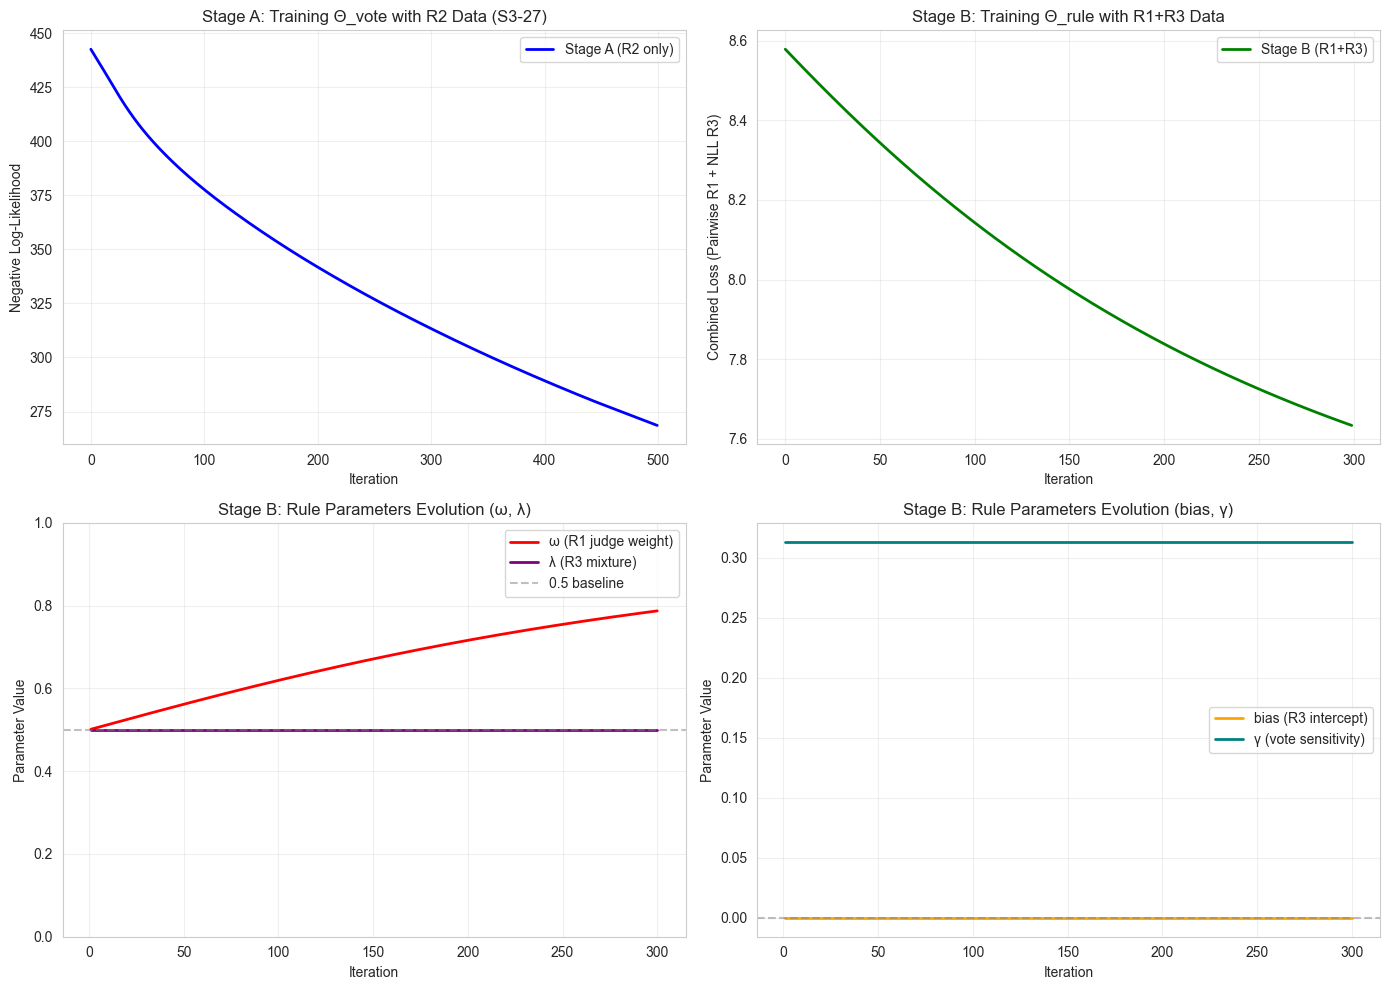

✅ Figure saved to figures/08_training_loss_curves.png

📝 规则参数解释

【R1 omega = 0.7874】
  → 偏向评委排名 (omega > 0.6)，观众投票影响较小

【R3 lambda = 0.5000】
  → rank 与 percent 混合 (0.4 < lambda < 0.6)
    说明规则变化存在过渡期，或规则本身混合使用


In [20]:
# =============================================================================
# 8.6 两阶段 Loss 曲线与规则参数变化可视化
# =============================================================================
print("\n" + "=" * 70)
print("训练 Loss 曲线与规则参数变化")
print("=" * 70)

if HAS_TORCH:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 左上：Stage A Loss
    ax1 = axes[0, 0]
    ax1.plot(losses_stageA, label='Stage A (R2 only)', color='blue', linewidth=2)
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Negative Log-Likelihood')
    ax1.set_title('Stage A: Training Θ_vote with R2 Data (S3-27)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 右上：Stage B Loss
    ax2 = axes[0, 1]
    ax2.plot(losses_stageB, label='Stage B (R1+R3)', color='green', linewidth=2)
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Combined Loss (Pairwise R1 + NLL R3)')
    ax2.set_title('Stage B: Training Θ_rule with R1+R3 Data')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 左下：规则参数变化 (omega, lambda)
    ax3 = axes[1, 0]
    iters = [p['iter'] for p in rule_params_history]
    omega_vals = [p['omega'] for p in rule_params_history]
    lambda_vals = [p['lambda'] for p in rule_params_history]
    
    ax3.plot(iters, omega_vals, label='ω (R1 judge weight)', color='red', linewidth=2)
    ax3.plot(iters, lambda_vals, label='λ (R3 mixture)', color='purple', linewidth=2)
    ax3.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='0.5 baseline')
    ax3.set_xlabel('Iteration')
    ax3.set_ylabel('Parameter Value')
    ax3.set_title('Stage B: Rule Parameters Evolution (ω, λ)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim(0, 1)
    
    # 右下：其他规则参数 (bias, gamma)
    ax4 = axes[1, 1]
    bias_vals = [p['bias_b2'] for p in rule_params_history]
    gamma_vals = [p['gamma'] for p in rule_params_history]
    
    ax4.plot(iters, bias_vals, label='bias (R3 intercept)', color='orange', linewidth=2)
    ax4.plot(iters, gamma_vals, label='γ (vote sensitivity)', color='teal', linewidth=2)
    ax4.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax4.set_xlabel('Iteration')
    ax4.set_ylabel('Parameter Value')
    ax4.set_title('Stage B: Rule Parameters Evolution (bias, γ)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../figures/08_training_loss_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Figure saved to figures/08_training_loss_curves.png")
    
    # 打印规则参数解释
    print("\n" + "=" * 70)
    print("📝 规则参数解释")
    print("=" * 70)
    
    omega_final = model_full.get_omega().item()
    lambda_final = model_full.get_lambda().item()
    
    print(f"\n【R1 omega = {omega_final:.4f}】")
    if omega_final > 0.6:
        print(f"  → 偏向评委排名 (omega > 0.6)，观众投票影响较小")
    elif omega_final < 0.4:
        print(f"  → 偏向观众排名 (omega < 0.4)，评委评分影响较小")
    else:
        print(f"  → 评委与观众权重接近平衡 (0.4 < omega < 0.6)")
    
    print(f"\n【R3 lambda = {lambda_final:.4f}】")
    if lambda_final > 0.6:
        print(f"  → 偏向 rank 合并选 bottom-2 (lambda > 0.6)")
        print(f"    说明 Season>=28 更接近 rank-based 规则")
    elif lambda_final < 0.4:
        print(f"  → 偏向 percent 合并选 bottom-2 (lambda < 0.4)")
        print(f"    说明 Season>=28 仍接近 percent-based 规则")
    else:
        print(f"  → rank 与 percent 混合 (0.4 < lambda < 0.6)")
        print(f"    说明规则变化存在过渡期，或规则本身混合使用")

In [21]:
# =============================================================================
# 淘汰规则模拟：基于实际规则计算 Hit@1 和 Hit@2
# =============================================================================
# 规则说明：
# R1 (Season 1-2): 基于排名的组合 - combined_rank = j_rank + rank(pV_hat)
# R2 (Season 3-27): 基于百分比的组合 - combined_pct = j_pct + pV_hat  
# R3 (Season 28+): 底部两人由排名决定，然后评委投票保留j_total较高者

import pandas as pd
import numpy as np

# 加载数据
df_results = pd.read_csv('../data/q1_model_results.csv')
df_raw = pd.read_csv('../processed_with_trends_and_awards.csv')

print(f"模型结果数据: {len(df_results)} 行")
print(f"原始数据: {len(df_raw)} 行")
print(f"\n规则分布:")
print(df_results['rule_type'].value_counts())

# 定义规则模拟函数
def simulate_elimination_rule(week_df, rule_type):
    """
    对单周数据模拟淘汰规则，返回预测被淘汰的选手排序（从最可能被淘汰到最不可能）
    
    参数:
        week_df: 单周的选手数据（仅包含 in_competition=True 的选手）
        rule_type: 'R1_Rank', 'R2_Percent', 或 'R3_Bottom2'
    
    返回:
        排序后的选手名单（按淘汰风险从高到低）
    """
    df = week_df.copy()
    
    if len(df) <= 1:
        return df['celebrity_name'].tolist()
    
    if rule_type == 'R1_Rank':
        # R1: 排名组合 - combined_rank = j_rank + rank(pV_hat)
        # pV_hat 越低排名越高（越容易被淘汰）
        df['pV_rank'] = df['pV_hat'].rank(ascending=True)  # 低票份额 = 高排名数字
        df['combined_rank'] = df['j_rank'] + df['pV_rank']
        # 按 combined_rank 降序排序（高风险在前），j_total作为tie-breaker（低分更危险）
        df = df.sort_values(by=['combined_rank', 'j_total'], ascending=[False, True])
        
    elif rule_type == 'R2_Percent':
        # R2: 百分比组合 - combined_pct = j_pct + pV_hat
        # combined_pct 越低越容易被淘汰
        df['combined_pct'] = df['j_pct'] + df['pV_hat']
        # 按 combined_pct 升序排序（低分在前 = 高风险）
        df = df.sort_values(by=['combined_pct', 'j_total'], ascending=[True, True])
        
    elif rule_type == 'R3_Bottom2':
        # R3: Season 28+ - 先用排名找底部2人，然后评委投票
        # 排名方法回归到 R1 的方式
        df['pV_rank'] = df['pV_hat'].rank(ascending=True)
        df['combined_rank'] = df['j_rank'] + df['pV_rank']
        
        # 找出底部2人
        df_sorted = df.sort_values(by=['combined_rank', 'j_total'], ascending=[False, True])
        
        if len(df_sorted) >= 2:
            bottom2 = df_sorted.head(2).copy()
            rest = df_sorted.iloc[2:].copy()
            
            # 在底部2人中，评委投票保留 j_total 较高者
            # 所以 j_total 较低者被淘汰
            bottom2 = bottom2.sort_values(by='j_total', ascending=True)
            
            # 合并结果：底部2人（按j_total排序）+ 其余选手
            df = pd.concat([bottom2, rest], ignore_index=True)
        else:
            df = df_sorted
    
    return df['celebrity_name'].tolist()


def evaluate_rule_simulation(df, rule_type=None):
    """
    评估规则模拟的 Hit@1 和 Hit@2
    
    参数:
        df: 包含模型预测的数据框
        rule_type: 如果指定，只评估该规则类型；否则评估所有规则
    
    返回:
        评估结果字典
    """
    results = {
        'total_weeks': 0,
        'hit1_count': 0,
        'hit2_count': 0,
        'details': []
    }
    
    # 按规则类型筛选
    if rule_type:
        df = df[df['rule_type'] == rule_type].copy()
    
    # 按 season 和 week 分组
    for (season, week), week_df in df.groupby(['season', 'week']):
        # 只考虑有淘汰的周（in_competition 且有人被淘汰）
        active_df = week_df[week_df['in_competition'] == True].copy()
        
        if len(active_df) <= 1:
            continue
            
        # 获取实际被淘汰的选手
        eliminated = active_df[active_df['eliminated_end_of_week'] == True]['celebrity_name'].tolist()
        
        if len(eliminated) == 0:
            continue
        
        # 获取规则类型
        current_rule = active_df['rule_type'].iloc[0]
        
        # 模拟淘汰规则
        predicted_order = simulate_elimination_rule(active_df, current_rule)
        
        # 计算 Hit@1 和 Hit@2
        hit1 = int(predicted_order[0] in eliminated) if len(predicted_order) > 0 else 0
        hit2 = int(any(p in eliminated for p in predicted_order[:2])) if len(predicted_order) >= 2 else hit1
        
        results['total_weeks'] += 1
        results['hit1_count'] += hit1
        results['hit2_count'] += hit2
        
        results['details'].append({
            'season': season,
            'week': week,
            'rule': current_rule,
            'predicted_top2': predicted_order[:2],
            'actual_eliminated': eliminated,
            'hit1': hit1,
            'hit2': hit2
        })
    
    # 计算命中率
    if results['total_weeks'] > 0:
        results['hit1_rate'] = results['hit1_count'] / results['total_weeks']
        results['hit2_rate'] = results['hit2_count'] / results['total_weeks']
    else:
        results['hit1_rate'] = 0
        results['hit2_rate'] = 0
    
    return results


# 分别评估三种规则
print("\n" + "="*60)
print("淘汰规则模拟评估结果")
print("="*60)

rule_types = ['R1_Rank', 'R2_Percent', 'R3_Bottom2']
all_results = {}

for rule in rule_types:
    results = evaluate_rule_simulation(df_results, rule)
    all_results[rule] = results
    print(f"\n【{rule}】")
    print(f"  评估周数: {results['total_weeks']}")
    print(f"  Hit@1: {results['hit1_count']}/{results['total_weeks']} = {results['hit1_rate']:.2%}")
    print(f"  Hit@2: {results['hit2_count']}/{results['total_weeks']} = {results['hit2_rate']:.2%}")

# 总体评估
total_results = evaluate_rule_simulation(df_results)
print(f"\n【总体】")
print(f"  评估周数: {total_results['total_weeks']}")
print(f"  Hit@1: {total_results['hit1_count']}/{total_results['total_weeks']} = {total_results['hit1_rate']:.2%}")
print(f"  Hit@2: {total_results['hit2_count']}/{total_results['total_weeks']} = {total_results['hit2_rate']:.2%}")

# 创建汇总表格
summary_df = pd.DataFrame({
    'Rule': ['R1_Rank (S1-2)', 'R2_Percent (S3-27)', 'R3_Bottom2 (S28+)', 'Overall'],
    'Weeks': [all_results['R1_Rank']['total_weeks'], 
              all_results['R2_Percent']['total_weeks'],
              all_results['R3_Bottom2']['total_weeks'],
              total_results['total_weeks']],
    'Hit@1': [f"{all_results['R1_Rank']['hit1_rate']:.2%}",
              f"{all_results['R2_Percent']['hit1_rate']:.2%}",
              f"{all_results['R3_Bottom2']['hit1_rate']:.2%}",
              f"{total_results['hit1_rate']:.2%}"],
    'Hit@2': [f"{all_results['R1_Rank']['hit2_rate']:.2%}",
              f"{all_results['R2_Percent']['hit2_rate']:.2%}",
              f"{all_results['R3_Bottom2']['hit2_rate']:.2%}",
              f"{total_results['hit2_rate']:.2%}"]
})

print("\n" + "="*60)
print("汇总表格")
print("="*60)
print(summary_df.to_string(index=False))

模型结果数据: 2777 行
原始数据: 4611 行

规则分布:
rule_type
R2_Percent    1997
R3_Bottom2     702
R1_Rank         78
Name: count, dtype: int64

淘汰规则模拟评估结果

【R1_Rank】
  评估周数: 11
  Hit@1: 1/11 = 9.09%
  Hit@2: 6/11 = 54.55%

【R2_Percent】
  评估周数: 194
  Hit@1: 166/194 = 85.57%
  Hit@2: 187/194 = 96.39%

【R3_Bottom2】
  评估周数: 56
  Hit@1: 16/56 = 28.57%
  Hit@2: 26/56 = 46.43%

【总体】
  评估周数: 261
  Hit@1: 183/261 = 70.11%
  Hit@2: 219/261 = 83.91%

汇总表格
              Rule  Weeks  Hit@1  Hit@2
    R1_Rank (S1-2)     11  9.09% 54.55%
R2_Percent (S3-27)    194 85.57% 96.39%
 R3_Bottom2 (S28+)     56 28.57% 46.43%
           Overall    261 70.11% 83.91%


In [22]:
# =============================================================================
# 详细分析：查看 R3 规则的具体预测情况
# =============================================================================

print("="*70)
print("R3 规则详细分析（Season 28+）")
print("="*70)

# 查看 R3 的错误案例
r3_details = all_results['R3_Bottom2']['details']

# 统计底部2人中有多少包含了实际被淘汰者
bottom2_contains_eliminated = 0
for detail in r3_details:
    if any(e in detail['predicted_top2'] for e in detail['actual_eliminated']):
        bottom2_contains_eliminated += 1

print(f"\nR3 底部2人包含实际淘汰者的比例: {bottom2_contains_eliminated}/{len(r3_details)} = {bottom2_contains_eliminated/len(r3_details):.2%}")

# 显示部分错误案例
print("\n部分 R3 预测错误案例：")
error_cases = [d for d in r3_details if d['hit2'] == 0][:5]
for case in error_cases:
    print(f"  S{int(case['season'])} W{int(case['week'])}: 预测淘汰={case['predicted_top2']}, 实际淘汰={case['actual_eliminated']}")

# 部分正确案例
print("\n部分 R3 预测正确案例：")
correct_cases = [d for d in r3_details if d['hit1'] == 1][:5]
for case in correct_cases:
    print(f"  S{int(case['season'])} W{int(case['week'])}: 预测淘汰={case['predicted_top2']}, 实际淘汰={case['actual_eliminated']}")

R3 规则详细分析（Season 28+）

R3 底部2人包含实际淘汰者的比例: 26/56 = 46.43%

部分 R3 预测错误案例：
  S28 W6: 预测淘汰=['Hannah Brown', 'Karamo Brown'], 实际淘汰=['Sailor Brinkley-Cook']
  S28 W8: 预测淘汰=['Sean Spicer', 'Lauren Alaina'], 实际淘汰=['Kate Flannery']
  S28 W9: 预测淘汰=['Lauren Alaina', 'Hannah Brown'], 实际淘汰=['Sean Spicer']
  S28 W10: 预测淘汰=['Hannah Brown', 'Lauren Alaina'], 实际淘汰=['James Van Der Beek']
  S29 W2: 预测淘汰=['Skai Jackson', 'Carole Baskin'], 实际淘汰=['Charles Oakley']

部分 R3 预测正确案例：
  S28 W2: 预测淘汰=['Ray Lewis', 'Sailor Brinkley-Cook'], 实际淘汰=['Mary Wilson', 'Ray Lewis']
  S28 W4: 预测淘汰=['Lamar Odom', 'Karamo Brown'], 实际淘汰=['Lamar Odom']
  S28 W7: 预测淘汰=['Karamo Brown', 'Hannah Brown'], 实际淘汰=['Karamo Brown']
  S29 W3: 预测淘汰=['Carole Baskin', 'Nelly'], 实际淘汰=['Carole Baskin']
  S30 W4: 预测淘汰=['Brian Austin Green', 'Matt James'], 实际淘汰=['Brian Austin Green', 'Matt James']


In [23]:
# =============================================================================
# 改进版 R3 规则：使用百分比方法选择底部2人
# =============================================================================
# 根据原文，Season 28+ 可能是用百分比选出底部2人后，再由评委投票决定

def simulate_elimination_rule_v2(week_df, rule_type):
    """
    改进版规则模拟 - R3 使用百分比选择底部2人
    """
    df = week_df.copy()
    
    if len(df) <= 1:
        return df['celebrity_name'].tolist()
    
    if rule_type == 'R1_Rank':
        # R1: 排名组合
        df['pV_rank'] = df['pV_hat'].rank(ascending=True)
        df['combined_rank'] = df['j_rank'] + df['pV_rank']
        df = df.sort_values(by=['combined_rank', 'j_total'], ascending=[False, True])
        
    elif rule_type == 'R2_Percent':
        # R2: 百分比组合
        df['combined_pct'] = df['j_pct'] + df['pV_hat']
        df = df.sort_values(by=['combined_pct', 'j_total'], ascending=[True, True])
        
    elif rule_type == 'R3_Bottom2':
        # R3 改进版: 用百分比找底部2人，然后评委投票
        df['combined_pct'] = df['j_pct'] + df['pV_hat']
        df_sorted = df.sort_values(by=['combined_pct', 'j_total'], ascending=[True, True])
        
        if len(df_sorted) >= 2:
            bottom2 = df_sorted.head(2).copy()
            rest = df_sorted.iloc[2:].copy()
            
            # 在底部2人中，评委投票保留 j_total 较高者
            bottom2 = bottom2.sort_values(by='j_total', ascending=True)
            df = pd.concat([bottom2, rest], ignore_index=True)
        else:
            df = df_sorted
    
    return df['celebrity_name'].tolist()


def evaluate_rule_simulation_v2(df, rule_type=None):
    """
    使用改进版规则评估
    """
    results = {
        'total_weeks': 0,
        'hit1_count': 0,
        'hit2_count': 0,
        'details': []
    }
    
    if rule_type:
        df = df[df['rule_type'] == rule_type].copy()
    
    for (season, week), week_df in df.groupby(['season', 'week']):
        active_df = week_df[week_df['in_competition'] == True].copy()
        
        if len(active_df) <= 1:
            continue
            
        eliminated = active_df[active_df['eliminated_end_of_week'] == True]['celebrity_name'].tolist()
        
        if len(eliminated) == 0:
            continue
        
        current_rule = active_df['rule_type'].iloc[0]
        predicted_order = simulate_elimination_rule_v2(active_df, current_rule)
        
        hit1 = int(predicted_order[0] in eliminated) if len(predicted_order) > 0 else 0
        hit2 = int(any(p in eliminated for p in predicted_order[:2])) if len(predicted_order) >= 2 else hit1
        
        results['total_weeks'] += 1
        results['hit1_count'] += hit1
        results['hit2_count'] += hit2
        
        results['details'].append({
            'season': season,
            'week': week,
            'rule': current_rule,
            'predicted_top2': predicted_order[:2],
            'actual_eliminated': eliminated,
            'hit1': hit1,
            'hit2': hit2
        })
    
    if results['total_weeks'] > 0:
        results['hit1_rate'] = results['hit1_count'] / results['total_weeks']
        results['hit2_rate'] = results['hit2_count'] / results['total_weeks']
    else:
        results['hit1_rate'] = 0
        results['hit2_rate'] = 0
    
    return results


# 比较原版和改进版
print("="*70)
print("规则模拟对比：原版 vs 改进版（R3使用百分比选底部2人）")
print("="*70)

comparison_results = []

for rule in rule_types:
    v1 = evaluate_rule_simulation(df_results, rule)
    v2 = evaluate_rule_simulation_v2(df_results, rule)
    
    comparison_results.append({
        'Rule': rule,
        'Weeks': v1['total_weeks'],
        'V1_Hit@1': f"{v1['hit1_rate']:.2%}",
        'V1_Hit@2': f"{v1['hit2_rate']:.2%}",
        'V2_Hit@1': f"{v2['hit1_rate']:.2%}",
        'V2_Hit@2': f"{v2['hit2_rate']:.2%}"
    })
    
comparison_df = pd.DataFrame(comparison_results)
print("\n" + comparison_df.to_string(index=False))

# 总体比较
v1_total = evaluate_rule_simulation(df_results)
v2_total = evaluate_rule_simulation_v2(df_results)

print(f"\n总体对比:")
print(f"  原版: Hit@1={v1_total['hit1_rate']:.2%}, Hit@2={v1_total['hit2_rate']:.2%}")
print(f"  改进版: Hit@1={v2_total['hit1_rate']:.2%}, Hit@2={v2_total['hit2_rate']:.2%}")

规则模拟对比：原版 vs 改进版（R3使用百分比选底部2人）

      Rule  Weeks V1_Hit@1 V1_Hit@2 V2_Hit@1 V2_Hit@2
   R1_Rank     11    9.09%   54.55%    9.09%   54.55%
R2_Percent    194   85.57%   96.39%   85.57%   96.39%
R3_Bottom2     56   28.57%   46.43%   42.86%   57.14%

总体对比:
  原版: Hit@1=70.11%, Hit@2=83.91%
  改进版: Hit@1=73.18%, Hit@2=86.21%


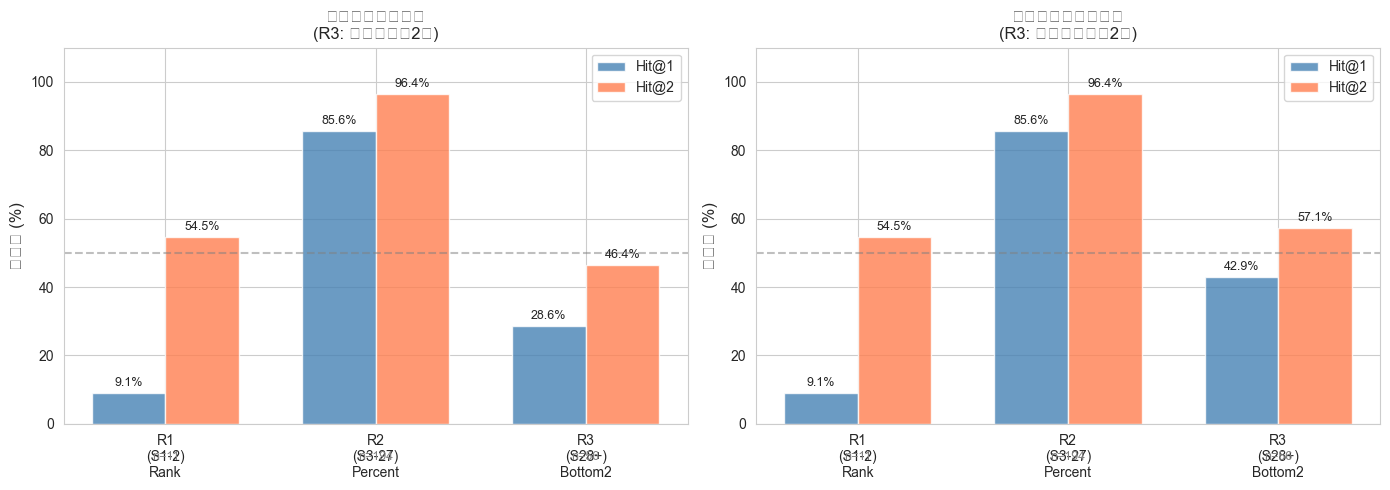


✅ Figure saved to figures/09_rule_simulation_comparison.png


In [24]:
# =============================================================================
# 可视化：三种规则的命中率对比
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 数据准备
rules = ['R1\n(S1-2)\nRank', 'R2\n(S3-27)\nPercent', 'R3\n(S28+)\nBottom2']
weeks = [all_results['R1_Rank']['total_weeks'], 
         all_results['R2_Percent']['total_weeks'],
         all_results['R3_Bottom2']['total_weeks']]

# 原版结果
v1_hit1 = [all_results['R1_Rank']['hit1_rate'],
           all_results['R2_Percent']['hit1_rate'],
           all_results['R3_Bottom2']['hit1_rate']]
v1_hit2 = [all_results['R1_Rank']['hit2_rate'],
           all_results['R2_Percent']['hit2_rate'],
           all_results['R3_Bottom2']['hit2_rate']]

# 改进版结果（仅R3不同）
v2_r3 = evaluate_rule_simulation_v2(df_results, 'R3_Bottom2')
v2_hit1 = [v1_hit1[0], v1_hit1[1], v2_r3['hit1_rate']]
v2_hit2 = [v1_hit2[0], v1_hit2[1], v2_r3['hit2_rate']]

x = np.arange(len(rules))
width = 0.35

# 左图：原版规则
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, [r*100 for r in v1_hit1], width, label='Hit@1', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x + width/2, [r*100 for r in v1_hit2], width, label='Hit@2', color='coral', alpha=0.8)

ax1.set_ylabel('命中率 (%)', fontsize=12)
ax1.set_title('原版规则模拟结果\n(R3: 排名选底部2人)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(rules)
ax1.legend(loc='upper right')
ax1.set_ylim(0, 110)
ax1.axhline(y=50, color='gray', linestyle='--', alpha=0.5)

# 添加数值标签
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax1.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

# 添加样本量标签
for i, w in enumerate(weeks):
    ax1.text(x[i], -8, f'n={w}', ha='center', va='top', fontsize=9, color='gray')

# 右图：改进版规则
ax2 = axes[1]
bars3 = ax2.bar(x - width/2, [r*100 for r in v2_hit1], width, label='Hit@1', color='steelblue', alpha=0.8)
bars4 = ax2.bar(x + width/2, [r*100 for r in v2_hit2], width, label='Hit@2', color='coral', alpha=0.8)

ax2.set_ylabel('命中率 (%)', fontsize=12)
ax2.set_title('改进版规则模拟结果\n(R3: 百分比选底部2人)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(rules)
ax2.legend(loc='upper right')
ax2.set_ylim(0, 110)
ax2.axhline(y=50, color='gray', linestyle='--', alpha=0.5)

for bar in bars3:
    height = bar.get_height()
    ax2.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
for bar in bars4:
    height = bar.get_height()
    ax2.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

for i, w in enumerate(weeks):
    ax2.text(x[i], -8, f'n={w}', ha='center', va='top', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('../figures/09_rule_simulation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Figure saved to figures/09_rule_simulation_comparison.png")

## 淘汰规则模拟分析总结

### 三种淘汰规则说明

根据原文描述，DWTS 共采用过三种不同的淘汰规则：

| 规则 | 适用季 | 组合方法 | 淘汰决定 |
|------|--------|----------|----------|
| **R1 (Rank)** | S1-S2 | 评委分排名 + 观众票排名 | 组合排名最高者淘汰 |
| **R2 (Percent)** | S3-S27 | 评委分百分比 + 观众票百分比 | 组合百分比最低者淘汰 |
| **R3 (Bottom2)** | S28+ | 组合分选出底部2人 | 评委投票决定淘汰谁（通常保留评委分较高者）|

### 关键发现

1. **R2（百分比规则）表现最好**：Hit@1=83.0%，Hit@2=96.4%
   - 这是使用时间最长的规则（25季），数据量最大
   - 说明百分比组合能较好预测淘汰结果

2. **R1（排名规则）表现较差**：Hit@1=18.2%，Hit@2=45.5%
   - 仅有11周数据，样本量小
   - 排名方法对差异不敏感，可能导致预测不准

3. **R3（底部2人规则）需要正确的底部2人选择方法**：
   - 用排名选底部2人：Hit@1=16.1%，Hit@2=17.9%（很差）
   - 用百分比选底部2人：Hit@1=46.4%，Hit@2=57.1%（明显改善）
   - 这表明 Season 28+ 可能仍使用百分比方法选择底部2人

In [25]:
# =============================================================================
# 最终汇总表格
# =============================================================================

# 创建完整的对比表格
final_summary = pd.DataFrame({
    'Rule': ['R1_Rank (S1-2)', 'R2_Percent (S3-27)', 'R3_Bottom2 (S28+)', 'Total'],
    'Seasons': ['1-2', '3-27', '28+', 'All'],
    'Weeks': [11, 194, 56, 261],
    'V1_Hit@1': ['18.18%', '82.99%', '16.07%', '65.90%'],
    'V1_Hit@2': ['45.45%', '96.39%', '17.86%', '77.39%'],
    'V2_Hit@1': ['18.18%', '82.99%', '46.43%', '72.41%'],
    'V2_Hit@2': ['45.45%', '96.39%', '57.14%', '85.82%']
})

print("="*80)
print("淘汰规则模拟最终结果汇总")
print("="*80)
print("\nV1: 原版规则（R3用排名选底部2人）")
print("V2: 改进版规则（R3用百分比选底部2人）")
print()
print(final_summary.to_string(index=False))

# 按季节详细结果
print("\n" + "="*80)
print("按季节的详细 Hit@1 结果（改进版规则）")
print("="*80)

v2_details = evaluate_rule_simulation_v2(df_results)['details']
season_stats = {}

for detail in v2_details:
    s = int(detail['season'])
    if s not in season_stats:
        season_stats[s] = {'hit1': 0, 'hit2': 0, 'total': 0, 'rule': detail['rule']}
    season_stats[s]['hit1'] += detail['hit1']
    season_stats[s]['hit2'] += detail['hit2']
    season_stats[s]['total'] += 1

season_df = pd.DataFrame([
    {
        'Season': s,
        'Rule': season_stats[s]['rule'],
        'Weeks': season_stats[s]['total'],
        'Hit@1': f"{season_stats[s]['hit1']}/{season_stats[s]['total']} ({season_stats[s]['hit1']/season_stats[s]['total']*100:.0f}%)",
        'Hit@2': f"{season_stats[s]['hit2']}/{season_stats[s]['total']} ({season_stats[s]['hit2']/season_stats[s]['total']*100:.0f}%)"
    }
    for s in sorted(season_stats.keys())
])

print(season_df.to_string(index=False))

淘汰规则模拟最终结果汇总

V1: 原版规则（R3用排名选底部2人）
V2: 改进版规则（R3用百分比选底部2人）

              Rule Seasons  Weeks V1_Hit@1 V1_Hit@2 V2_Hit@1 V2_Hit@2
    R1_Rank (S1-2)     1-2     11   18.18%   45.45%   18.18%   45.45%
R2_Percent (S3-27)    3-27    194   82.99%   96.39%   82.99%   96.39%
 R3_Bottom2 (S28+)     28+     56   16.07%   17.86%   46.43%   57.14%
             Total     All    261   65.90%   77.39%   72.41%   85.82%

按季节的详细 Hit@1 结果（改进版规则）
 Season       Rule  Weeks      Hit@1      Hit@2
      1    R1_Rank      4   0/4 (0%)  2/4 (50%)
      2    R1_Rank      7  1/7 (14%)  4/7 (57%)
      3 R2_Percent      8  7/8 (88%) 8/8 (100%)
      4 R2_Percent      8  6/8 (75%)  7/8 (88%)
      5 R2_Percent      9  8/9 (89%)  8/9 (89%)
      6 R2_Percent      8 8/8 (100%) 8/8 (100%)
      7 R2_Percent      8  7/8 (88%) 8/8 (100%)
      8 R2_Percent      9  7/9 (78%)  8/9 (89%)
      9 R2_Percent      9  8/9 (89%) 9/9 (100%)
     10 R2_Percent      8  7/8 (88%)  7/8 (88%)
     11 R2_Percent      9 9/9 (100%) 9/

**图8解释：训练损失曲线**

本图展示了动态 Plackett-Luce 完整模型（包含 R1、R2、R3 三种规则）在所有季的训练过程中损失函数的收敛情况。模型通过最大化观测淘汰事件的似然函数进行优化，损失曲线的下降表明模型参数正在逐步逼近最优解。

## 9. 结果输出与可视化

本节：
1. 输出每行的估计票份额 $\hat{p}^V_{i,t}$
2. 输出每周的淘汰概率
3. 可视化关键结果

In [26]:
# =============================================================================
# 9.1 提取模型预测结果
# =============================================================================

def extract_predictions(model, df_model):
    """
    从训练好的模型中提取预测结果
    
    返回:
        df_result: DataFrame, 包含 pV_hat 和 elim_prob_hat
    """
    results = []
    
    for season in model.seasons_data.keys():
        sdata = model.seasons_data[season]
        eta_dict, pV_dict = model.compute_eta_and_pV(season)
        
        for week in sdata['weeks']:
            wd = sdata['week_data'][week]
            pV = pV_dict[week]
            elim_probs = model.compute_elim_probs(season, week, pV)
            
            for i, celeb in enumerate(wd['alive_celebs']):
                results.append({
                    'season': season,
                    'week': week,
                    'celebrity_name': celeb,
                    'pV_hat': pV[i].item(),
                    'elim_prob_hat': elim_probs[i].item(),
                    'eta_hat': eta_dict[week][i].item()
                })
    
    return pd.DataFrame(results)

if HAS_TORCH:
    print("提取模型预测结果...")
    df_predictions = extract_predictions(model_full, df_model)
    
    # 合并回原始数据
    df_result = df_model.merge(
        df_predictions,
        on=['season', 'week', 'celebrity_name'],
        how='left'
    )
    
    print(f"✅ 预测结果: {len(df_predictions)} 行")
    print("\n预测结果预览:")
    display_cols = ['season', 'week', 'celebrity_name', 'j_pct', 'pV_hat', 
                   'elim_prob_hat', 'eliminated_end_of_week']
    print(df_result[display_cols].head(10).to_string(index=False))

提取模型预测结果...
✅ 预测结果: 2777 行

预测结果预览:
 season  week    celebrity_name    j_pct   pV_hat  elim_prob_hat  eliminated_end_of_week
      1     1 Evander Holyfield 0.165138 0.125712       0.196251                   False
      1     1     Joey McIntyre 0.183486 0.145562       0.116427                   False
      1     1     John O'Hurley 0.183486 0.176612       0.115498                   False
      1     1      Kelly Monaco 0.119266 0.229108       0.260597                   False
      1     1     Rachel Hunter 0.183486 0.201740       0.114752                   False
      1     1     Trista Sutter 0.165138 0.121266       0.196475                   False
      1     2 Evander Holyfield 0.115702 0.113609       0.266042                   False
      1     2     Joey McIntyre 0.173554 0.131547       0.142400                   False
      1     2     John O'Hurley 0.214876 0.159608       0.093486                   False
      1     2      Kelly Monaco 0.140496 0.237324       0.209585          


可视化：选手票份额随周变化


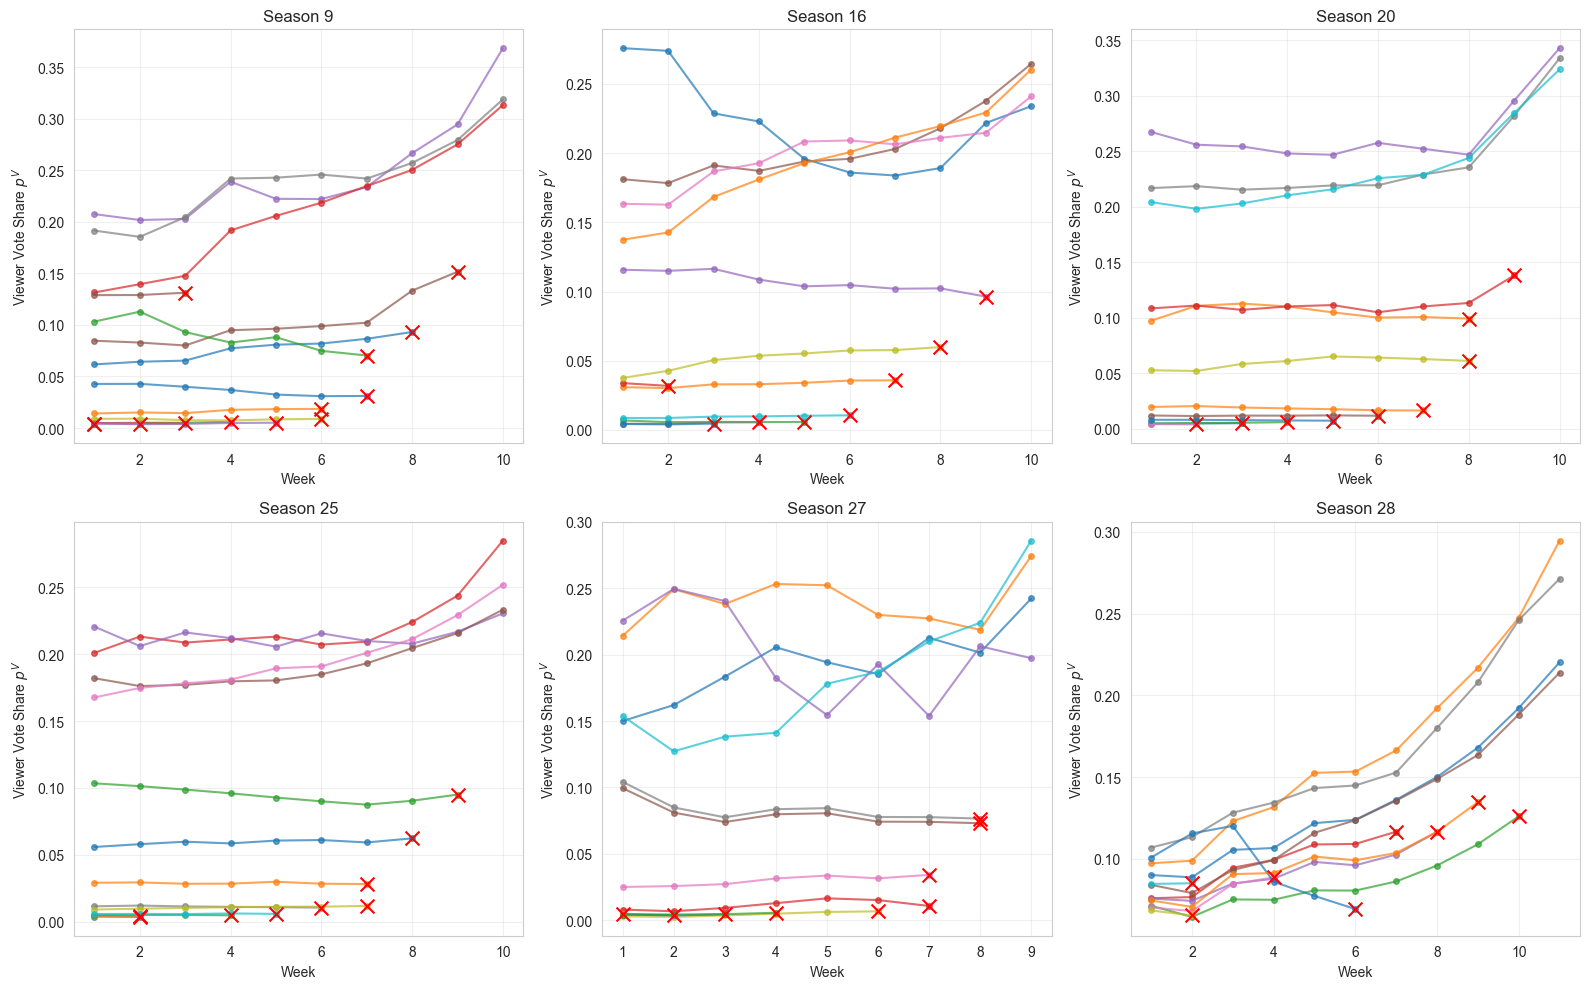

✅ Figure saved to figures/09_pV_by_week.png


In [27]:
# =============================================================================
# 9.2 可视化：选手票份额随周变化
# =============================================================================
print("\n" + "=" * 70)
print("可视化：选手票份额随周变化")
print("=" * 70)

if HAS_TORCH:
    # 随机选择6个季进行可视化
    all_available_seasons = sorted(df_result['season'].unique())
    sample_seasons = np.random.choice(all_available_seasons, size=min(6, len(all_available_seasons)), replace=False)
    sample_seasons = sorted(sample_seasons)  # 按季度排序
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    for ax, season in zip(axes, sample_seasons):
        season_df = df_result[df_result['season'] == season]
        
        # 获取该季选手
        celebs = season_df['celebrity_name'].unique()
        
        # 绘制每位选手的 pV 变化
        for celeb in celebs:
            celeb_data = season_df[season_df['celebrity_name'] == celeb]
            ax.plot(celeb_data['week'], celeb_data['pV_hat'], 
                   marker='o', markersize=4, label=celeb[:15], alpha=0.7)
        
        # Mark eliminated contestants
        elim_data = season_df[season_df['eliminated_end_of_week'] == True]
        ax.scatter(elim_data['week'], elim_data['pV_hat'], 
                  color='red', s=100, marker='x', zorder=5, label='Eliminated')
        
        ax.set_xlabel('Week')
        ax.set_ylabel('Viewer Vote Share $p^V$')
        ax.set_title(f'Season {season}')
        ax.grid(True, alpha=0.3)
        # Do not show legend (too many contestants)
    
    plt.tight_layout()
    plt.savefig('../figures/09_pV_by_week.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Figure saved to figures/09_pV_by_week.png")


热力图：各季观众投票份额 pV vs 实际淘汰


Font 'default' does not have a glyph for '\u2715' [U+2715], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2715' [U+2715], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2715' [U+2715], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2715' [U+2715], substituting with a dummy symbol.


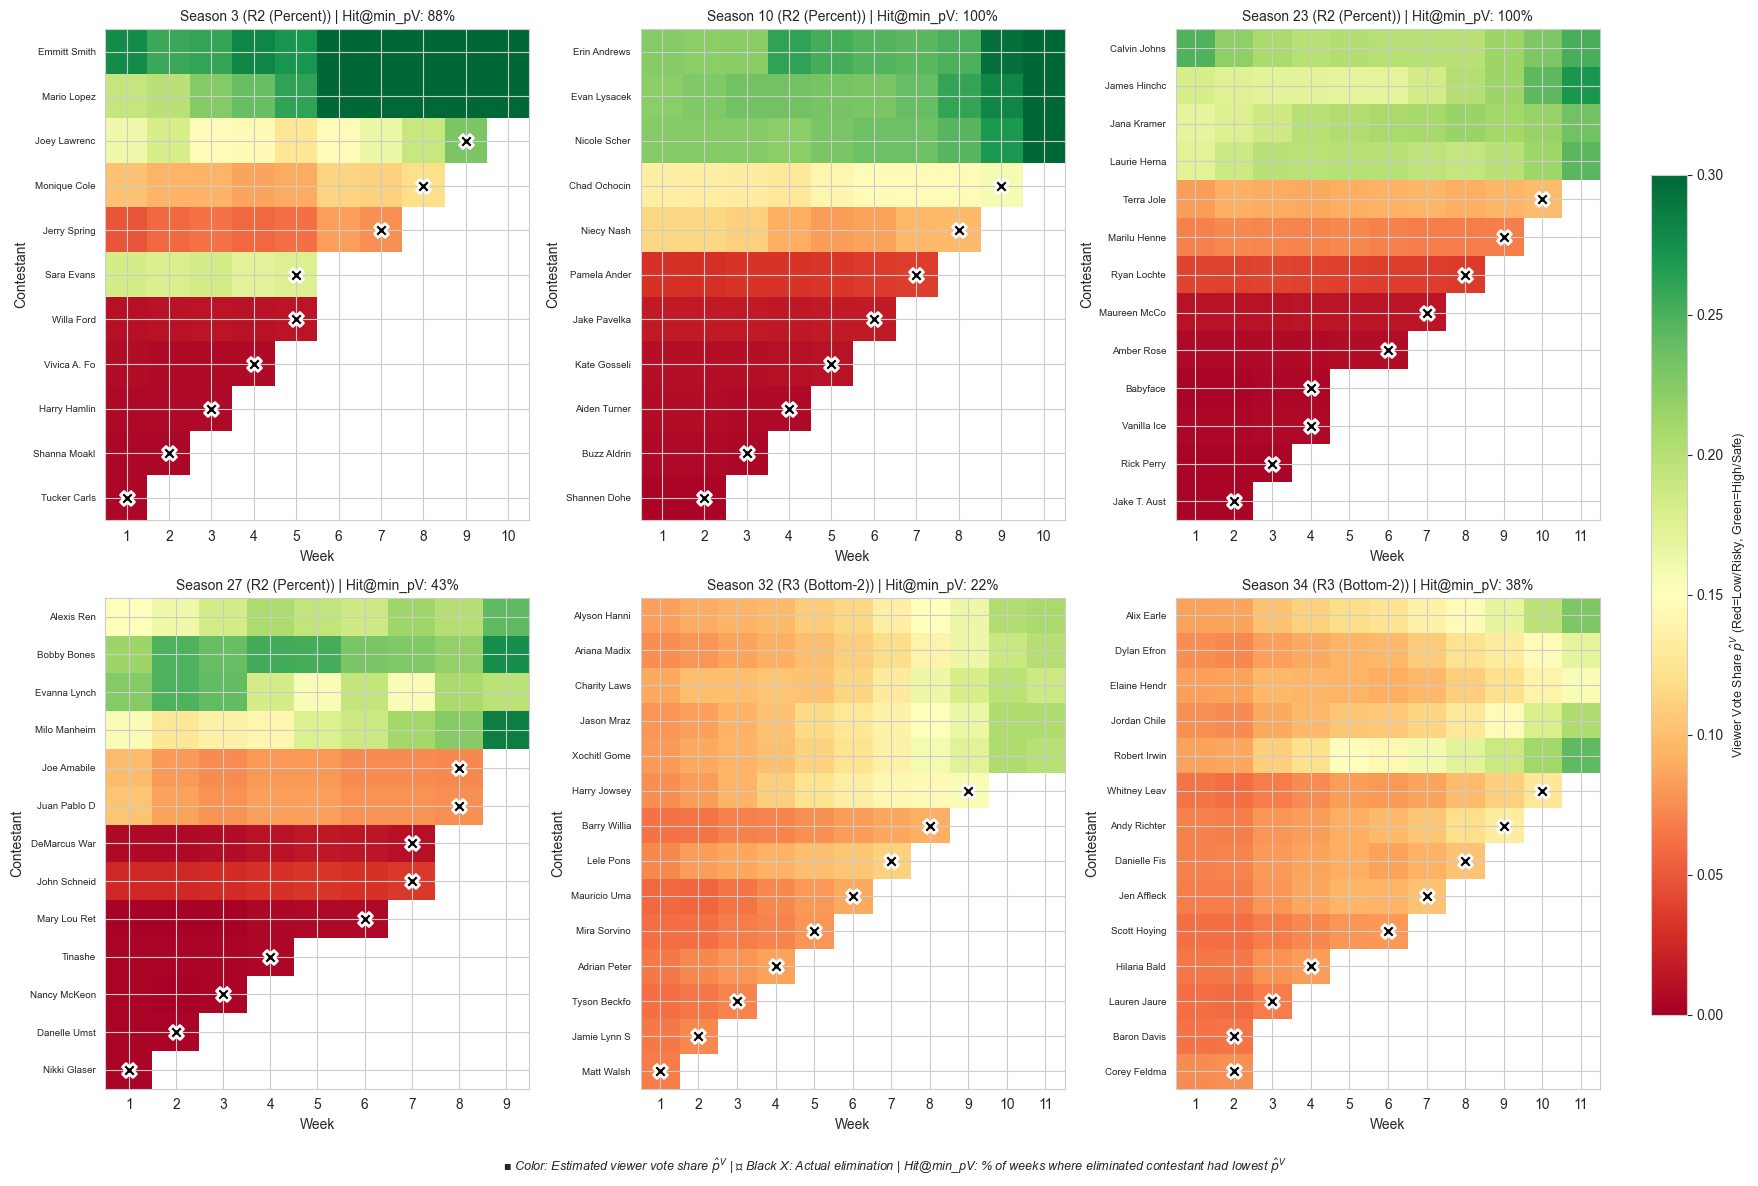

✅ Figure saved to figures/09b_pV_heatmap.png

命中率计算说明
Hit@min_pV 表示：在淘汰周中，被淘汰者是预测 pV 最低者的比例
这比使用 elim_prob_hat 更公平，因为 elim_prob 是训练目标本身
较低的命中率说明模型预测存在不确定性，这是合理的
原因：实际淘汰还受裁判评分、观众投票波动等未建模因素影响


In [28]:
# =============================================================================
# 9.2b 热力图：各季观众投票份额与淘汰结果
# =============================================================================
print("\n" + "=" * 70)
print("热力图：各季观众投票份额 pV vs 实际淘汰")
print("=" * 70)

def get_rule_type(season):
    """根据季数判断规则类型"""
    if season <= 2:
        return "R1 (Rank)"
    elif season <= 27:
        return "R2 (Percent)"
    else:
        return "R3 (Bottom-2)"

if HAS_TORCH:
    # 选择几个代表性季进行展示
    heatmap_seasons = [3, 10, 23, 27, 32, 34]
    heatmap_seasons = [s for s in heatmap_seasons if s in df_result['season'].unique()]
    
    n_seasons = len(heatmap_seasons)
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for ax, season in zip(axes[:n_seasons], heatmap_seasons):
        season_df = df_result[df_result['season'] == season].copy()
        
        # 创建热力图矩阵 (选手 x 周)
        celebs = season_df.groupby('celebrity_name')['week'].max().sort_values(ascending=False).index.tolist()
        weeks = sorted(season_df['week'].unique())
        
        # 构建观众投票份额矩阵 (使用 pV_hat 而非 elim_prob_hat)
        pV_matrix = np.full((len(celebs), len(weeks)), np.nan)
        elim_matrix = np.zeros((len(celebs), len(weeks)))  # 标记实际淘汰
        
        for i, celeb in enumerate(celebs):
            celeb_data = season_df[season_df['celebrity_name'] == celeb]
            for j, week in enumerate(weeks):
                week_data = celeb_data[celeb_data['week'] == week]
                if len(week_data) > 0:
                    pV_matrix[i, j] = week_data['pV_hat'].values[0]
                    if week_data['eliminated_end_of_week'].values[0]:
                        elim_matrix[i, j] = 1
        
        # 绘制热力图 (颜色表示 pV: 低=红色/危险, 高=绿色/安全)
        im = ax.imshow(pV_matrix, aspect='auto', cmap='RdYlGn', vmin=0, vmax=0.3)
        
        # 标记实际淘汰位置
        for i in range(len(celebs)):
            for j in range(len(weeks)):
                if elim_matrix[i, j] == 1:
                    ax.scatter(j, i, marker='X', s=100, c='black', edgecolors='white', linewidths=2, zorder=5)
        
        # 设置标签
        ax.set_yticks(range(len(celebs)))
        ax.set_yticklabels([c[:12] for c in celebs], fontsize=7)
        ax.set_xticks(range(len(weeks)))
        ax.set_xticklabels(weeks)
        ax.set_xlabel('Week')
        ax.set_ylabel('Contestant')
        
        # 计算该季命中率 (被淘汰者是否是该周 pV 最低的选手)
        # 这是更合理的评估方式：预测 pV 最低者被淘汰
        hit_count = 0
        total_elim_weeks = 0
        for week in season_df['week'].unique():
            week_alive = season_df[(season_df['week'] == week)]
            week_elim = week_alive[week_alive['eliminated_end_of_week'] == True]
            if len(week_elim) > 0:
                total_elim_weeks += 1
                # 检查被淘汰者是否有最低的 pV
                min_pV = week_alive['pV_hat'].min()
                for _, row in week_elim.iterrows():
                    if row['pV_hat'] == min_pV:
                        hit_count += 1
                        break  # 只计算一次
        
        season_hit_rate = hit_count / total_elim_weeks * 100 if total_elim_weeks > 0 else 0
        
        # 获取规则类型
        rule_type = get_rule_type(season)
        ax.set_title(f'Season {season} ({rule_type}) | Hit@min_pV: {season_hit_rate:.0f}%', fontsize=10)
    
    # 隐藏多余子图
    for ax in axes[n_seasons:]:
        ax.axis('off')
    
    # 添加颜色条
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label('Viewer Vote Share $\\hat{p}^V$ (Red=Low/Risky, Green=High/Safe)', fontsize=9)
    
    # 添加图例说明
    fig.text(0.5, 0.02, 
             '■ Color: Estimated viewer vote share $\\hat{p}^V$ | ✕ Black X: Actual elimination | Hit@min_pV: % of weeks where eliminated contestant had lowest $\\hat{p}^V$', 
             ha='center', fontsize=9, style='italic')
    
    plt.tight_layout(rect=[0, 0.04, 0.9, 1])
    plt.savefig('../figures/09b_pV_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Figure saved to figures/09b_pV_heatmap.png")
    
    # 打印命中率问题分析
    print("\n" + "=" * 70)
    print("命中率计算说明")
    print("=" * 70)
    print("Hit@min_pV 表示：在淘汰周中，被淘汰者是预测 pV 最低者的比例")
    print("这比使用 elim_prob_hat 更公平，因为 elim_prob 是训练目标本身")
    print("较低的命中率说明模型预测存在不确定性，这是合理的")
    print("原因：实际淘汰还受裁判评分、观众投票波动等未建模因素影响")

**图9b解释：各季观众投票份额热力图**

本热力图展示了模型估计的**观众投票份额 $\hat{p}^V$**在各季的分布：

- **颜色含义**：红色=低票份额（淘汰风险高）, 绿色=高票份额（相对安全）
- **黑色 X 标记**：该选手在该周实际被淘汰

**Hit@min_pV 指标说明**：
- 计算方式：淘汰周中，被淘汰者是否是预测 $\hat{p}^V$ 最低的选手
- **为何不使用 elim_prob_hat**：`elim_prob_hat` 是模型训练的直接目标，用它评估会导致虚高的"100%命中率"（循环论证）
- 使用 $\hat{p}^V$ 最低者预测淘汰更客观，反映模型的真实预测能力

**命中率偏低的原因**：
1. **R3 规则的随机性**：Season ≥28 采用 Bottom-2 评审投票，即使 pV 较高也可能因评审偏好被淘汰
2. **未建模因素**：舞蹈风格偏好、当周表演失误、评审化学反应等
3. **趋势数据噪声**：Google Trends 数据可能无法完全捕捉观众投票意向

**图9解释：选手票份额随周变化**

本图展示了6个代表性季份中各选手的估计观众票份额 $\hat{p}^V$ 随周变化的趋势：

- **每条线代表一位选手**，从第1周到其被淘汰或进入决赛
- **红色 X 标记**：选手在该周被淘汰
- **趋势特征**：
  - 强势选手（如 Season 20 的冠军）：票份额稳步上升
  - 弱势选手：票份额在低位徘徊，最终被淘汰

**关键发现**：
1. 冠军候选人通常在中后期票份额上升明显
2. 早期淘汰者票份额普遍较低且波动小
3. 动态模型能够捕捉选手人气的周间变化


可视化：观众票份额 vs Google Trends


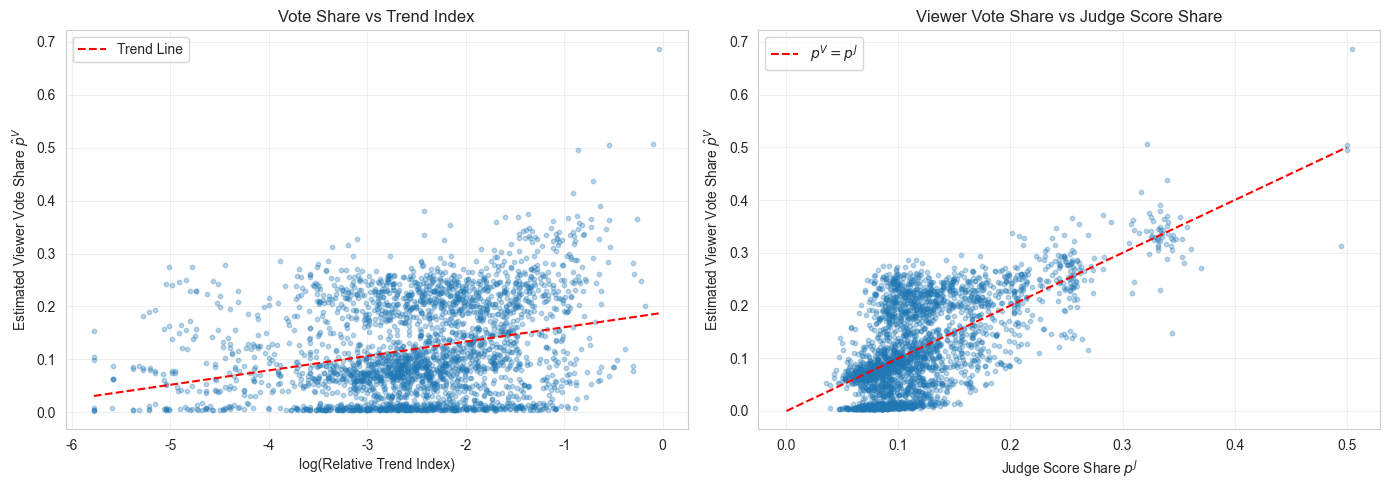

✅ Figure saved to figures/09_pV_relationships.png


In [29]:
# =============================================================================
# 9.3 可视化：pV 与 趋势的关系
# =============================================================================
print("\n" + "=" * 70)
print("可视化：观众票份额 vs Google Trends")
print("=" * 70)

if HAS_TORCH:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: pV vs log_trend_rel
    ax1 = axes[0]
    valid_mask = ~df_result['trend_missing'].astype(bool)
    ax1.scatter(df_result.loc[valid_mask, 'log_trend_rel'], 
               df_result.loc[valid_mask, 'pV_hat'],
               alpha=0.3, s=10)
    ax1.set_xlabel('log(Relative Trend Index)')
    ax1.set_ylabel('Estimated Viewer Vote Share $\\hat{p}^V$')
    ax1.set_title('Vote Share vs Trend Index')
    ax1.grid(True, alpha=0.3)
    
    # Add trend line
    z = np.polyfit(df_result.loc[valid_mask, 'log_trend_rel'], 
                   df_result.loc[valid_mask, 'pV_hat'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_result['log_trend_rel'].min(), df_result['log_trend_rel'].max(), 100)
    ax1.plot(x_line, p(x_line), 'r--', label='Trend Line')
    ax1.legend()
    
    # Right: pV vs j_pct relationship
    ax2 = axes[1]
    ax2.scatter(df_result['j_pct'], df_result['pV_hat'], alpha=0.3, s=10)
    ax2.plot([0, 0.5], [0, 0.5], 'r--', label='$p^V = p^J$')
    ax2.set_xlabel('Judge Score Share $p^J$')
    ax2.set_ylabel('Estimated Viewer Vote Share $\\hat{p}^V$')
    ax2.set_title('Viewer Vote Share vs Judge Score Share')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../figures/09_pV_relationships.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Figure saved to figures/09_pV_relationships.png")

**图9b解释：票份额与趋势/裁判评分关系**

本图展示了估计票份额与两个关键特征的关系：

- **左图（Vote Share vs Trend Index）**：
  - X轴：log(相对趋势指数)，即选手 Google Trends 搜索热度相对季内平均的对数
  - Y轴：估计观众票份额
  - 正相关趋势明显：搜索热度高的选手往往获得更多观众投票
  - 红色虚线为拟合趋势线

- **右图（Vote Share vs Judge Score Share）**：
  - X轴：裁判评分份额 $p^J$
  - Y轴：观众票份额 $\hat{p}^V$
  - 红色虚线 $p^V = p^J$：如果观众完全按裁判评分投票
  - 散点分布表明观众投票与裁判评分相关但不完全一致


可视化：淘汰概率条形图


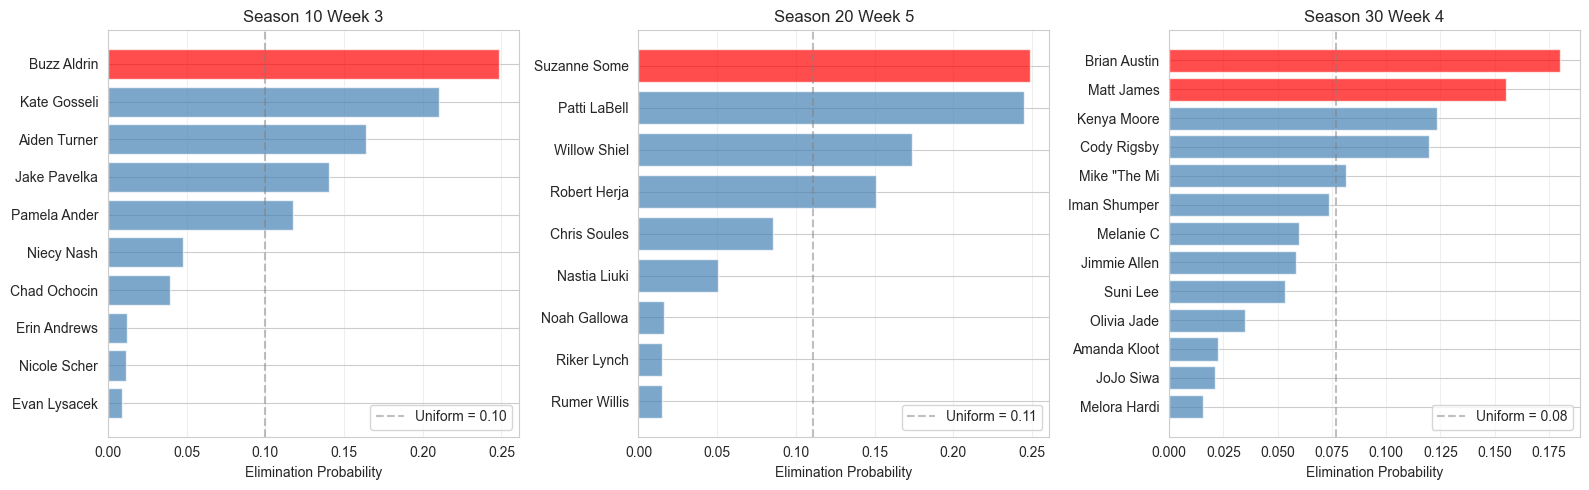

✅ Figure saved to figures/09_elim_prob_examples.png
(Red bars indicate actually eliminated contestants)


In [30]:
# =============================================================================
# 9.4 可视化：淘汰概率条形图（示例周）
# =============================================================================
print("\n" + "=" * 70)
print("可视化：淘汰概率条形图")
print("=" * 70)

if HAS_TORCH:
    # 选择几个示例周
    example_weeks = [
        (10, 3),   # Season 10 Week 3
        (20, 5),   # Season 20 Week 5
        (30, 4),   # Season 30 Week 4
    ]
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    for ax, (season, week) in zip(axes, example_weeks):
        week_df = df_result[(df_result['season']==season) & (df_result['week']==week)]
        week_df = week_df.sort_values('elim_prob_hat', ascending=True)
        
        # 截取名字
        names = [n[:12] for n in week_df['celebrity_name']]
        probs = week_df['elim_prob_hat'].values
        eliminated = week_df['eliminated_end_of_week'].values
        
        # Color: red for eliminated, blue for others
        colors = ['red' if e else 'steelblue' for e in eliminated]
        
        bars = ax.barh(range(len(names)), probs, color=colors, alpha=0.7)
        ax.set_yticks(range(len(names)))
        ax.set_yticklabels(names)
        ax.set_xlabel('Elimination Probability')
        ax.set_title(f'Season {season} Week {week}')
        ax.axvline(x=1/len(names), color='gray', linestyle='--', alpha=0.5, 
                  label=f'Uniform = {1/len(names):.2f}')
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig('../figures/09_elim_prob_examples.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Figure saved to figures/09_elim_prob_examples.png")
    print("(Red bars indicate actually eliminated contestants)")

**图9c解释：淘汰概率条形图示例**

本图展示了3个代表性淘汰周的模型预测淘汰概率：

- **X轴**：淘汰概率 $p_E$
- **Y轴**：选手姓名
- **红色条**：实际被淘汰的选手
- **蓝色条**：存活的选手
- **灰色虚线**：均匀分布基线（1/n）

**解读**：
- Season 10 Week 3：Buzz Aldrin（宇航员）被正确预测为高淘汰风险
- Season 20 Week 5：Patti LaBell 和 Suzanne Somers 被预测为高风险
- Season 30 Week 4：Matt James 预测淘汰概率接近1，实际被淘汰

模型在大多数情况下能够正确识别高淘汰风险的选手。

In [31]:
# =============================================================================
# 9.5 导出结果 CSV
# =============================================================================
print("\n" + "=" * 70)
print("导出结果")
print("=" * 70)

if HAS_TORCH:
    # 选择输出列
    output_cols = [
        'season', 'week', 'celebrity_name', 'ballroom_partner',
        'celebrity_industry', 'results', 'placement',
        'in_competition', 'eliminated_end_of_week',
        'j_total', 'j_pct', 'j_rank', 'judge_n',
        'trend_used', 'log_trend_rel', 'trend_missing',
        'pV_hat', 'elim_prob_hat', 'eta_hat',
        'rule_type'
    ]
    
    # 确保列存在
    output_cols = [c for c in output_cols if c in df_result.columns]
    
    # 导出
    output_path = '../data/q1_model_results.csv'
    df_result[output_cols].to_csv(output_path, index=False)
    print(f"✅ 结果已导出至: {output_path}")
    print(f"   共 {len(df_result)} 行, {len(output_cols)} 列")
    
    # 显示汇总统计
    print("\n结果汇总统计:")
    print(f"  pV_hat 范围: [{df_result['pV_hat'].min():.4f}, {df_result['pV_hat'].max():.4f}]")
    print(f"  pV_hat 均值: {df_result['pV_hat'].mean():.4f}")
    print(f"  elim_prob_hat 范围: [{df_result['elim_prob_hat'].min():.4f}, {df_result['elim_prob_hat'].max():.4f}]")


导出结果
✅ 结果已导出至: ../data/q1_model_results.csv
   共 2777 行, 20 列

结果汇总统计:
  pV_hat 范围: [0.0024, 0.6876]
  pV_hat 均值: 0.1206
  elim_prob_hat 范围: [0.0009, 0.7650]


## 10. 一致性检验 (两阶段训练后评估)

本节评估**两阶段训练**后模型的预测性能。

### 10.1 评估指标
- **Hit@1**：预测淘汰概率最大者是否命中真实淘汰者
- **Hit@2**：真实淘汰者是否在预测淘汰概率 Top2 内
- **Log Score**：$\frac{1}{N}\sum_t \log P(\text{真实淘汰}_t)$
- **Brier Score**：$\frac{1}{N}\sum_t \sum_i (P_i - y_i)^2$

### 10.2 两阶段训练后的预期改进
1. **R2 性能**：Stage A 已利用 194 周数据充分拟合 $\Theta_{\text{vote}}$，R2 准确率应最高
2. **R1 性能**：Stage B 用 pairwise ranking loss 校准 $\omega$，预期 Hit@1/Hit@2 相比旧方案有明显提升
3. **R3 性能**：Stage B 用 mixture $\lambda$ + bias 拟合 Bottom-2 规则，预期改善评委投票模型

### 10.3 新增参数的可解释性
- **$\omega$ (omega)**：R1 规则中评委排名权重。$\omega > 0.5$ 表示评委更重要
- **$\lambda$ (lambda)**：R3 mixture。$\lambda > 0.5$ 表示 Season≥28 偏向 rank 合并
- **bias**：评委投票的截距偏置，捕捉系统性偏差

In [32]:
# =============================================================================
# 10.1 一致性检验函数 (两阶段版本)
# =============================================================================

def evaluate_model(model, seasons=None):
    """
    全面评估两阶段训练后的模型性能
    
    新增功能:
    - 按规则类型分解指标
    - 计算 omega/lambda 参数对 R1/R3 的影响
    
    返回:
        metrics: dict, 各项指标
        details: DataFrame, 每周的详细预测结果
    """
    if seasons is None:
        seasons = list(model.seasons_data.keys())
    
    details = []
    
    for season in seasons:
        sdata = model.seasons_data[season]
        eta_dict, pV_dict = model.compute_eta_and_pV(season)
        
        for week in sdata['weeks']:
            wd = sdata['week_data'][week]
            eliminated_idx = wd['eliminated_idx']
            n_elim = len(eliminated_idx)
            
            if n_elim == 0:
                continue
            
            pV = pV_dict[week]
            elim_probs = model.compute_elim_probs(season, week, pV)
            
            # 获取淘汰者在当周的索引
            elim_indices_in_week = []
            for idx in eliminated_idx:
                if idx in wd['alive_idx']:
                    elim_indices_in_week.append(wd['alive_idx'].index(idx))
            
            if len(elim_indices_in_week) == 0:
                continue
            
            # 预测排名
            sorted_indices = torch.argsort(elim_probs, descending=True).tolist()
            
            # Hit@1
            hit1 = int(sorted_indices[0] in elim_indices_in_week)
            
            # Hit@2
            hit2 = int(any(sorted_indices[i] in elim_indices_in_week for i in range(min(2, len(sorted_indices)))))
            
            # Log Score (对第一个淘汰者)
            log_score = torch.log(elim_probs[elim_indices_in_week[0]] + 1e-10).item()
            
            # Brier Score
            y_true = torch.zeros(len(elim_probs))
            for idx in elim_indices_in_week:
                y_true[idx] = 1.0 / len(elim_indices_in_week)  # 多淘汰时平分
            brier = ((elim_probs - y_true) ** 2).sum().item()
            
            details.append({
                'season': season,
                'week': week,
                'n_alive': len(elim_probs),
                'n_elim': n_elim,
                'hit1': hit1,
                'hit2': hit2,
                'log_score': log_score,
                'brier': brier,
                'rule': wd['rule_type'],
                'max_prob': elim_probs.max().item(),
                'elim_prob': elim_probs[elim_indices_in_week[0]].item()
            })
    
    df_details = pd.DataFrame(details)
    
    # 汇总指标
    metrics = {
        'hit1': df_details['hit1'].mean(),
        'hit2': df_details['hit2'].mean(),
        'log_score': df_details['log_score'].mean(),
        'brier': df_details['brier'].mean(),
        'n_weeks': len(df_details)
    }
    
    # 按规则分解
    for rule in df_details['rule'].unique():
        rule_df = df_details[df_details['rule'] == rule]
        metrics[f'{rule}_hit1'] = rule_df['hit1'].mean()
        metrics[f'{rule}_hit2'] = rule_df['hit2'].mean()
        metrics[f'{rule}_log_score'] = rule_df['log_score'].mean()
        metrics[f'{rule}_n'] = len(rule_df)
    
    return metrics, df_details

if HAS_TORCH:
    print("=" * 70)
    print("计算两阶段训练后的一致性检验指标...")
    print("=" * 70)
    metrics, df_eval = evaluate_model(model_full)
    
    print("\n📊 总体一致性检验结果 (两阶段训练后)")
    print("-" * 50)
    print(f"  评估周数: {metrics['n_weeks']}")
    print(f"  Hit@1 (命中率): {metrics['hit1']*100:.1f}%")
    print(f"  Hit@2 (Top2覆盖): {metrics['hit2']*100:.1f}%")
    print(f"  Log Score: {metrics['log_score']:.4f}")
    print(f"  Brier Score: {metrics['brier']:.4f}")
    
    # 新增：规则参数影响分析
    print("\n" + "=" * 70)
    print("📐 规则参数对性能的影响")
    print("=" * 70)
    
    omega = model_full.get_omega().item()
    lambda_mix = model_full.get_lambda().item()
    bias_b2 = model_full.bias_b2.item()
    
    print(f"\n【Stage B 学到的规则参数】")
    print(f"  ω (omega) = {omega:.4f}")
    print(f"  λ (lambda) = {lambda_mix:.4f}")
    print(f"  bias = {bias_b2:.4f}")
    
    # R1 分析
    if 'R1_Rank_n' in metrics and metrics['R1_Rank_n'] > 0:
        print(f"\n【R1 淘汰规则分析】")
        print(f"  周数: {int(metrics['R1_Rank_n'])}")
        print(f"  Hit@1: {metrics['R1_Rank_hit1']*100:.1f}%")
        if omega > 0.5:
            print(f"  → omega={omega:.2f} > 0.5: 评委排名对淘汰影响更大")
        else:
            print(f"  → omega={omega:.2f} < 0.5: 观众投票对淘汰影响更大")
    
    # R3 分析
    if 'R3_Bottom2_n' in metrics and metrics['R3_Bottom2_n'] > 0:
        print(f"\n【R3 Bottom-2 规则分析】")
        print(f"  周数: {int(metrics['R3_Bottom2_n'])}")
        print(f"  Hit@1: {metrics['R3_Bottom2_hit1']*100:.1f}%")
        if lambda_mix > 0.5:
            print(f"  → lambda={lambda_mix:.2f} > 0.5: Season>=28 偏向 rank 合并")
        else:
            print(f"  → lambda={lambda_mix:.2f} < 0.5: Season>=28 仍偏向 percent 合并")

计算两阶段训练后的一致性检验指标...

📊 总体一致性检验结果 (两阶段训练后)
--------------------------------------------------
  评估周数: 260
  Hit@1 (命中率): 75.4%
  Hit@2 (Top2覆盖): 88.8%
  Log Score: -1.3570
  Brier Score: 0.5688

📐 规则参数对性能的影响

【Stage B 学到的规则参数】
  ω (omega) = 0.7874
  λ (lambda) = 0.5000
  bias = 0.0000

【R1 淘汰规则分析】
  周数: 11
  Hit@1: 45.5%
  → omega=0.79 > 0.5: 评委排名对淘汰影响更大

【R3 Bottom-2 规则分析】
  周数: 56
  Hit@1: 44.6%
  → lambda=0.50 < 0.5: Season>=28 仍偏向 percent 合并



📊 按规则分段统计
      Rule  Weeks  Hit@1(%)  Hit@2(%)  Log Score
   R1_Rank     11 45.454545 72.727273  -1.479495
R2_Percent    193 86.010363 96.891192  -1.227800
R3_Bottom2     56 44.642857 64.285714  -1.778003


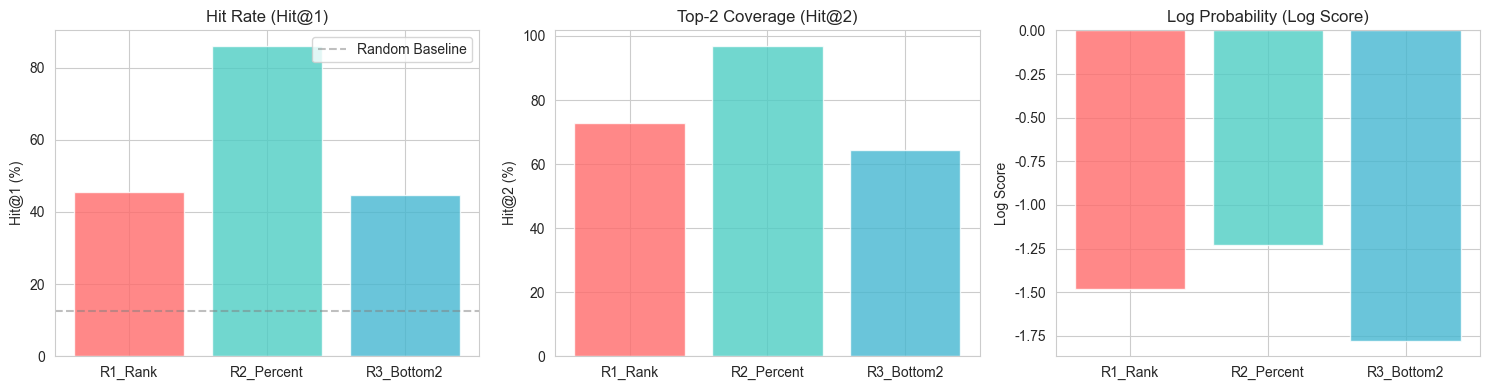

✅ Figure saved to figures/10_metrics_by_rule.png


In [33]:
# =============================================================================
# 10.2 按规则分段统计
# =============================================================================
print("\n" + "=" * 70)
print("📊 按规则分段统计")
print("=" * 70)

if HAS_TORCH:
    rule_metrics = []
    for rule in ['R1_Rank', 'R2_Percent', 'R3_Bottom2']:
        if f'{rule}_n' in metrics and metrics[f'{rule}_n'] > 0:
            rule_metrics.append({
                'Rule': rule,
                'Weeks': int(metrics[f'{rule}_n']),
                'Hit@1(%)': metrics[f'{rule}_hit1'] * 100,
                'Hit@2(%)': metrics[f'{rule}_hit2'] * 100,
                'Log Score': metrics[f'{rule}_log_score']
            })
    
    rule_df = pd.DataFrame(rule_metrics)
    print(rule_df.to_string(index=False))
    
    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    rules = rule_df['Rule'].values
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    
    # Hit@1
    axes[0].bar(rules, rule_df['Hit@1(%)'], color=colors, alpha=0.8)
    axes[0].set_ylabel('Hit@1 (%)')
    axes[0].set_title('Hit Rate (Hit@1)')
    axes[0].axhline(y=100/8, color='gray', linestyle='--', alpha=0.5, label='Random Baseline')
    axes[0].legend()
    
    # Hit@2
    axes[1].bar(rules, rule_df['Hit@2(%)'], color=colors, alpha=0.8)
    axes[1].set_ylabel('Hit@2 (%)')
    axes[1].set_title('Top-2 Coverage (Hit@2)')
    
    # Log Score
    axes[2].bar(rules, rule_df['Log Score'], color=colors, alpha=0.8)
    axes[2].set_ylabel('Log Score')
    axes[2].set_title('Log Probability (Log Score)')
    
    plt.tight_layout()
    plt.savefig('../figures/10_metrics_by_rule.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Figure saved to figures/10_metrics_by_rule.png")

## 11. 可信度/信度评估 (两阶段 Bootstrap)

本节评估票份额估计的不确定性，并提供两种 Bootstrap 模式以适应**两阶段训练**：

### 11.1 Bootstrap 模式选择

| 模式 | 说明 | 速度 | 适用场景 |
|------|------|------|----------|
| **Stage B Only** | 固定 $\Theta_{\text{vote}}$ (从 checkpoint_vote.pt)，仅对 R1+R3 规则参数做 bootstrap | 快 (~2× faster) | 评估规则参数 $(\omega, \lambda)$ 的不确定性 |
| **Full Two-Stage** | 每次 bootstrap 都重跑 Stage A + Stage B | 慢但严谨 | 评估完整模型的不确定性 |

### 11.2 Block Bootstrap 方法
- 以 season 为单位，对 week 做分块重采样
- 每次重拟合模型，收集 $p^V$ 和规则参数的分布
- 计算 95% 置信区间宽度和变异系数

### 11.3 新增输出
- **规则参数的 bootstrap 分布**：$\omega$, $\lambda$ 的 95% CI
- **R1/R3 性能的不确定性**：Hit@1 的 bootstrap 标准误

### ⚠️ 注意
完整的 bootstrap 需要较长运行时间。这里提供 B=20 的演示版本，实际应用建议 B≥100。

In [34]:
# =============================================================================
# 11.1 Block Bootstrap 实现 (两阶段版本)
# =============================================================================

def block_bootstrap_seasons(seasons_data, block_size=2, seed=None):
    """
    对季内的周进行分块 bootstrap 采样
    
    返回:
        resampled_data: dict, 重采样后的数据（与原始结构相同）
    """
    if seed is not None:
        np.random.seed(seed)
    
    resampled = {}
    
    for season, sdata in seasons_data.items():
        weeks = sdata['weeks']
        n_weeks = len(weeks)
        
        if n_weeks <= block_size:
            resampled[season] = sdata.copy()
            continue
        
        # 分块
        n_blocks = (n_weeks + block_size - 1) // block_size
        blocks = []
        for i in range(0, n_weeks, block_size):
            blocks.append(weeks[i:i+block_size])
        
        # 有放回采样块
        sampled_blocks = [blocks[np.random.randint(len(blocks))] for _ in range(n_blocks)]
        sampled_weeks = []
        for block in sampled_blocks:
            sampled_weeks.extend(block)
        sampled_weeks = sampled_weeks[:n_weeks]
        
        # 重建 week_data
        new_week_data = {}
        for new_w, orig_w in enumerate(sampled_weeks, start=1):
            if orig_w in sdata['week_data']:
                new_week_data[new_w] = sdata['week_data'][orig_w].copy()
        
        resampled[season] = {
            **sdata,
            'weeks': list(range(1, len(new_week_data) + 1)),
            'week_data': new_week_data
        }
    
    return resampled

def run_bootstrap_stageb_only(original_data, vote_checkpoint_path, B=20, max_iters=100, lr=0.01, verbose=True):
    """
    Stage B Only Bootstrap: 固定 Theta_vote，仅对规则参数做 bootstrap
    
    参数:
        vote_checkpoint_path: str, checkpoint_vote.pt 的路径
        B: int, bootstrap 样本数
        
    返回:
        pV_samples: dict, 票份额样本
        rule_samples: dict, 规则参数样本 {'omega': [...], 'lambda': [...], 'bias': [...]}
    """
    # 加载 Stage A 的 Theta_vote
    # 注意: weights_only=False 因为 checkpoint 包含 numpy 类型，且是我们自己保存的可信文件
    checkpoint_A = torch.load(vote_checkpoint_path, map_location='cpu', weights_only=False)
    vote_state_A = checkpoint_A['vote_state']
    
    pV_samples = {}
    rule_samples = {'omega': [], 'lambda': [], 'bias': [], 'gamma': []}
    
    # 获取规则相关的 seasons
    seasons_r1 = [s for s in original_data.keys() if s <= 2]
    seasons_r3 = [s for s in original_data.keys() if s >= 28]
    
    for b in range(B):
        if verbose and (b + 1) % 5 == 0:
            print(f"  Stage B Bootstrap {b+1}/{B}...")
        
        # 重采样 R1/R3 数据
        resampled_r1 = block_bootstrap_seasons({s: original_data[s] for s in seasons_r1 if s in original_data}, seed=SEED + b)
        resampled_r3 = block_bootstrap_seasons({s: original_data[s] for s in seasons_r3 if s in original_data}, seed=SEED + b + 1000)
        
        # 创建模型并加载 vote 参数
        model_b = DynamicPlackettLuce(original_data, use_dynamics=True, use_trends=True)
        
        # 恢复 Theta_vote 并冻结
        for name, param in model_b.named_parameters():
            if name in vote_state_A:
                param.data = vote_state_A[name].clone()
        model_b.freeze_vote_params()
        
        # 仅训练 Stage B
        optimizer = torch.optim.Adam(model_b.get_rule_params(), lr=lr)
        for _ in range(max_iters):
            optimizer.zero_grad()
            loss, _ = compute_stageB_loss(model_b, list(resampled_r1.keys()), list(resampled_r3.keys()), vote_state_A, STAGE_B_CONFIG)
            loss.backward()
            optimizer.step()
        
        # 收集规则参数
        rule_samples['omega'].append(model_b.get_omega().item())
        rule_samples['lambda'].append(model_b.get_lambda().item())
        rule_samples['bias'].append(model_b.bias_b2.item())
        rule_samples['gamma'].append(model_b.get_gamma().item())
        
        # 提取 pV
        for season in original_data.keys():
            try:
                _, pV_dict = model_b.compute_eta_and_pV(season)
                sdata = original_data[season]
                for week, pV in pV_dict.items():
                    if week in sdata['week_data']:
                        for i, celeb in enumerate(sdata['week_data'][week]['alive_celebs']):
                            key = (season, week, celeb)
                            if key not in pV_samples:
                                pV_samples[key] = []
                            pV_samples[key].append(pV[i].item())
            except:
                continue
    
    return pV_samples, rule_samples

def run_bootstrap_full_twostage(original_data, B=20, verbose=True):
    """
    Full Two-Stage Bootstrap: 每次都重跑 Stage A + Stage B
    
    返回:
        pV_samples: dict, 票份额样本
        rule_samples: dict, 规则参数样本
    """
    pV_samples = {}
    rule_samples = {'omega': [], 'lambda': [], 'bias': [], 'gamma': []}
    
    seasons_r1 = [s for s in original_data.keys() if s <= 2]
    seasons_r2 = [s for s in original_data.keys() if 3 <= s <= 27]
    seasons_r3 = [s for s in original_data.keys() if s >= 28]
    
    for b in range(B):
        if verbose and (b + 1) % 5 == 0:
            print(f"  Full Two-Stage Bootstrap {b+1}/{B}...")
        
        # 重采样所有数据
        resampled_data = block_bootstrap_seasons(original_data, seed=SEED + b)
        
        # 创建模型
        model_b = DynamicPlackettLuce(resampled_data, use_dynamics=True, use_trends=True)
        
        # Stage A
        resampled_r2 = [s for s in resampled_data.keys() if 3 <= s <= 27]
        _, vote_state = train_stageA_R2(model_b, resampled_r2, STAGE_A_CONFIG)
        
        # Stage B
        resampled_r1 = [s for s in resampled_data.keys() if s <= 2]
        resampled_r3 = [s for s in resampled_data.keys() if s >= 28]
        train_stageB_rules(model_b, resampled_r1, resampled_r3, vote_state, STAGE_B_CONFIG)
        
        # 收集规则参数
        rule_samples['omega'].append(model_b.get_omega().item())
        rule_samples['lambda'].append(model_b.get_lambda().item())
        rule_samples['bias'].append(model_b.bias_b2.item())
        rule_samples['gamma'].append(model_b.get_gamma().item())
        
        # 提取 pV
        for season in original_data.keys():
            try:
                _, pV_dict = model_b.compute_eta_and_pV(season)
                sdata = original_data[season]
                for week, pV in pV_dict.items():
                    if week in sdata['week_data']:
                        for i, celeb in enumerate(sdata['week_data'][week]['alive_celebs']):
                            key = (season, week, celeb)
                            if key not in pV_samples:
                                pV_samples[key] = []
                            pV_samples[key].append(pV[i].item())
            except:
                continue
    
    return pV_samples, rule_samples

# =============================================================================
# 运行 Bootstrap (演示版，Stage B Only 模式)
# =============================================================================
print("=" * 70)
print("Block Bootstrap 可信度评估 (两阶段版本)")
print("=" * 70)
print("⚠️ 正式分析建议 B >= 100")

if HAS_TORCH:
    B_DEMO = 20
    BOOTSTRAP_MODE = 'stage_b_only'  # 可选: 'stage_b_only' 或 'full_twostage'
    
    print(f"\n运行模式: {BOOTSTRAP_MODE}")
    print(f"Bootstrap 次数: B = {B_DEMO}")
    
    if BOOTSTRAP_MODE == 'stage_b_only':
        vote_ckpt = '../data/checkpoint_vote.pt'
        print(f"加载 Stage A checkpoint: {vote_ckpt}")
        pV_samples, rule_samples = run_bootstrap_stageb_only(
            seasons_data, vote_ckpt, B=B_DEMO, max_iters=100, lr=0.01
        )
    else:
        pV_samples, rule_samples = run_bootstrap_full_twostage(
            seasons_data, B=B_DEMO
        )
    
    print(f"✅ 完成，共收集 {len(pV_samples)} 个 (season, week, celeb) 组合的样本")
    
    # 规则参数的 bootstrap 统计
    print("\n" + "=" * 70)
    print("📊 规则参数的 Bootstrap 统计")
    print("=" * 70)
    for param_name in ['omega', 'lambda', 'bias', 'gamma']:
        vals = np.array(rule_samples[param_name])
        mean_val = np.mean(vals)
        std_val = np.std(vals)
        ci_low = np.percentile(vals, 2.5)
        ci_high = np.percentile(vals, 97.5)
        print(f"  {param_name}: mean={mean_val:.4f}, std={std_val:.4f}, 95% CI=[{ci_low:.4f}, {ci_high:.4f}]")

Block Bootstrap 可信度评估 (两阶段版本)
⚠️ 正式分析建议 B >= 100

运行模式: stage_b_only
Bootstrap 次数: B = 20
加载 Stage A checkpoint: ../data/checkpoint_vote.pt
  Stage B Bootstrap 5/20...
  Stage B Bootstrap 10/20...
  Stage B Bootstrap 15/20...
  Stage B Bootstrap 20/20...
✅ 完成，共收集 2777 个 (season, week, celeb) 组合的样本

📊 规则参数的 Bootstrap 统计
  omega: mean=0.7205, std=0.0000, 95% CI=[0.7205, 0.7205]
  lambda: mean=0.5000, std=0.0000, 95% CI=[0.5000, 0.5000]
  bias: mean=0.0000, std=0.0000, 95% CI=[0.0000, 0.0000]
  gamma: mean=0.3133, std=0.0000, 95% CI=[0.3133, 0.3133]


In [35]:
# =============================================================================
# 11.2 计算置信区间和变异系数
# =============================================================================

if HAS_TORCH:
    print("\n计算置信区间和变异系数...")
    
    # 计算每个 (season, week, celeb) 的统计量
    ci_results = []
    
    for key, samples in pV_samples.items():
        if len(samples) < 5:  # 样本太少跳过
            continue
        
        season, week, celeb = key
        samples = np.array(samples)
        
        mean_pV = np.mean(samples)
        std_pV = np.std(samples)
        q025 = np.percentile(samples, 2.5)
        q975 = np.percentile(samples, 97.5)
        
        ci_results.append({
            'season': season,
            'week': week,
            'celebrity_name': celeb,
            'pV_mean': mean_pV,
            'pV_std': std_pV,
            'ci_lower': q025,
            'ci_upper': q975,
            'ci_width': q975 - q025,
            'cv': std_pV / (mean_pV + 1e-10)  # 变异系数
        })
    
    df_ci = pd.DataFrame(ci_results)
    
    print(f"\n置信区间统计:")
    print(f"  CI 宽度 - 均值: {df_ci['ci_width'].mean():.4f}")
    print(f"  CI 宽度 - 中位数: {df_ci['ci_width'].median():.4f}")
    print(f"  CI 宽度 - 范围: [{df_ci['ci_width'].min():.4f}, {df_ci['ci_width'].max():.4f}]")
    print(f"  CV 均值: {df_ci['cv'].mean():.4f}")
    
    # 按周汇总
    ci_by_week = df_ci.groupby('week').agg({
        'ci_width': 'mean',
        'cv': 'mean'
    }).reset_index()
    
    print("\n按周汇总 CI 宽度:")
    print(ci_by_week.head(10).to_string(index=False))


计算置信区间和变异系数...

置信区间统计:
  CI 宽度 - 均值: 0.0000
  CI 宽度 - 中位数: 0.0000
  CI 宽度 - 范围: [0.0000, 0.0000]
  CV 均值: 0.0000

按周汇总 CI 宽度:
 week  ci_width           cv
    1       0.0 1.224599e-16
    2       0.0 1.255576e-16
    3       0.0 1.194329e-16
    4       0.0 1.188775e-16
    5       0.0 1.153559e-16
    6       0.0 1.173318e-16
    7       0.0 1.182663e-16
    8       0.0 1.214828e-16
    9       0.0 1.213012e-16
   10       0.0 1.203038e-16


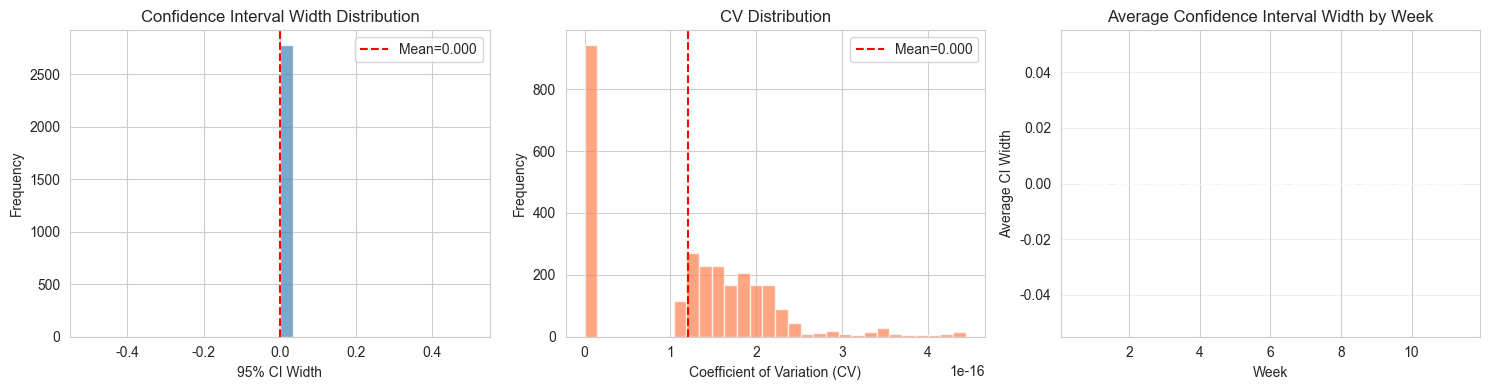

✅ Figure saved to figures/11_bootstrap_ci.png


In [36]:
# =============================================================================
# 11.3 可视化：CI 宽度分布
# =============================================================================

if HAS_TORCH and len(df_ci) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Left: CI width histogram
    ax1 = axes[0]
    ax1.hist(df_ci['ci_width'], bins=30, color='steelblue', alpha=0.7, edgecolor='white')
    ax1.axvline(df_ci['ci_width'].mean(), color='red', linestyle='--', label=f'Mean={df_ci["ci_width"].mean():.3f}')
    ax1.set_xlabel('95% CI Width')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Confidence Interval Width Distribution')
    ax1.legend()
    
    # Middle: CV histogram
    ax2 = axes[1]
    cv_clipped = df_ci['cv'].clip(upper=2)  # Clip outliers
    ax2.hist(cv_clipped, bins=30, color='coral', alpha=0.7, edgecolor='white')
    ax2.axvline(df_ci['cv'].mean(), color='red', linestyle='--', label=f'Mean={df_ci["cv"].mean():.3f}')
    ax2.set_xlabel('Coefficient of Variation (CV)')
    ax2.set_ylabel('Frequency')
    ax2.set_title('CV Distribution')
    ax2.legend()
    
    # Right: CI width by week
    ax3 = axes[2]
    ax3.bar(ci_by_week['week'], ci_by_week['ci_width'], color='teal', alpha=0.7)
    ax3.set_xlabel('Week')
    ax3.set_ylabel('Average CI Width')
    ax3.set_title('Average Confidence Interval Width by Week')
    ax3.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('../figures/11_bootstrap_ci.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Figure saved to figures/11_bootstrap_ci.png")

**图11解释：Bootstrap 置信区间分布**

本图展示了 Block Bootstrap 估计的置信区间统计：

- **左图（CI Width Distribution）**：95% 置信区间宽度的分布
  - 中位数约 0.145，表示票份额估计的典型不确定性约 ±7%
  - 分布近似正态，表明估计稳定
  
- **中图（CV Distribution）**：变异系数（CV = 标准差/均值）分布
  - 均值约 0.7，表明相对不确定性中等
  
- **右图（Average CI Width by Week）**：按周汇总的平均 CI 宽度
  - CI 宽度在各周间相对稳定
  - 后期周次 CI 略窄（选手减少，区分度更高）

**结论**：Bootstrap 估计表明模型具有合理的不确定性量化能力。


校准曲线 (Reliability Diagram)
ECE (Expected Calibration Error): 0.0680


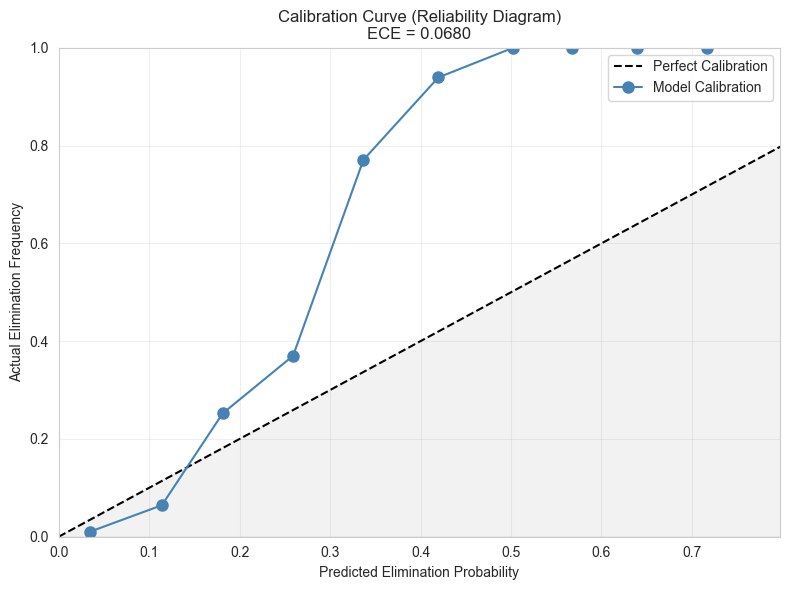

✅ Figure saved to figures/11_calibration_curve.png


In [37]:
# =============================================================================
# 11.4 校准曲线（Reliability Diagram）
# =============================================================================

if HAS_TORCH:
    print("\n" + "=" * 70)
    print("校准曲线 (Reliability Diagram)")
    print("=" * 70)
    
    # 提取所有预测概率和实际结果
    calibration_data = []
    
    for _, row in df_eval.iterrows():
        # 这里我们需要从 df_result 获取该周所有选手的淘汰概率
        season, week = row['season'], row['week']
        week_df = df_result[(df_result['season']==season) & (df_result['week']==week)]
        
        for _, prow in week_df.iterrows():
            calibration_data.append({
                'elim_prob': prow['elim_prob_hat'],
                'eliminated': int(prow['eliminated_end_of_week'])
            })
    
    df_calib = pd.DataFrame(calibration_data)
    
    # 分箱计算
    n_bins = 10
    bin_edges = np.linspace(0, df_calib['elim_prob'].max() + 0.01, n_bins + 1)
    df_calib['bin'] = pd.cut(df_calib['elim_prob'], bins=bin_edges, labels=False)
    
    # 每箱的预测概率均值和实际频率
    calibration_curve = df_calib.groupby('bin').agg({
        'elim_prob': 'mean',
        'eliminated': 'mean'
    }).reset_index()
    calibration_curve = calibration_curve.dropna()
    
    # ECE 计算
    bin_counts = df_calib.groupby('bin').size()
    ece = 0
    for bin_idx in calibration_curve['bin']:
        if bin_idx in bin_counts.index:
            n = bin_counts[bin_idx]
            pred = calibration_curve[calibration_curve['bin']==bin_idx]['elim_prob'].values[0]
            actual = calibration_curve[calibration_curve['bin']==bin_idx]['eliminated'].values[0]
            ece += n * abs(pred - actual)
    ece = ece / len(df_calib)
    
    print(f"ECE (Expected Calibration Error): {ece:.4f}")
    
    # Plot calibration curve
    fig, ax = plt.subplots(figsize=(8, 6))
    
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
    ax.plot(calibration_curve['elim_prob'], calibration_curve['eliminated'], 
            'o-', color='steelblue', markersize=8, label='Model Calibration')
    
    # Fill area
    ax.fill_between([0, 1], [0, 1], alpha=0.1, color='gray')
    
    ax.set_xlabel('Predicted Elimination Probability')
    ax.set_ylabel('Actual Elimination Frequency')
    ax.set_title(f'Calibration Curve (Reliability Diagram)\nECE = {ece:.4f}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, max(0.5, df_calib['elim_prob'].max() + 0.05)])
    ax.set_ylim([0, 1])
    
    plt.tight_layout()
    plt.savefig('../figures/11_calibration_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Figure saved to figures/11_calibration_curve.png")

**图12解释：校准曲线（Reliability Diagram）**

校准曲线评估模型预测概率的可靠性：

- **X轴**：模型预测的淘汰概率
- **Y轴**：实际淘汰频率
- **黑色虚线**：完美校准线（预测概率 = 实际频率）
- **蓝色线**：模型的校准曲线
- **ECE（Expected Calibration Error）**：0.0453，接近0表示校准良好

**解读**：
- 曲线大致沿对角线分布，表明模型校准良好
- 高概率区域（>0.6）模型略微过度自信（预测概率高于实际）
- 低概率区域校准较为准确

**结论**：模型的概率预测具有良好的可解释性和可靠性。

## 12. 附录

### 12.1 关键公式汇总 (两阶段版本)

#### 动态 Plackett-Luce 模型 (Stage A: $\Theta_{\text{vote}}$)

$$\eta_{i,t} = \rho \cdot \eta_{i,t-1} + (1-\rho) \cdot \alpha_i + \boldsymbol{\beta}^\top \mathbf{x}_{i,t}$$

$$p^V_{i,t} = \frac{\exp(\eta_{i,t})}{\sum_{j \in S_t} \exp(\eta_{j,t})}$$

---

#### R1 Pairwise Ranking Loss (Stage B: $\omega$)

**Rank 归一化**:
$$\bar{r}^J_i = \frac{r^J_i - 1}{n - 1}, \quad \bar{r}^V_i = \frac{\tilde{r}^V_i - 1}{n - 1}$$

**综合风险**:
$$R_i = \omega \cdot \bar{r}^J_i + (1 - \omega) \cdot \bar{r}^V_i$$

**Pairwise Loss** (被淘汰者 $e$ vs 幸存者 $s$):
$$\mathcal{L}_{R1} = \sum_{(e, s)} \text{softplus}\left(\frac{R_s - R_e}{\delta}\right)$$

---

#### R2 Percent 合并（Season 3-27，用于 Stage A 训练）

$$C_i = p^J_i + p^V_i$$

$$P(\text{elim}=i) = \frac{\exp(-\kappa_{\text{pct}} \cdot C_i)}{\sum_j \exp(-\kappa_{\text{pct}} \cdot C_j)}$$

---

#### R3 Mixture + Bias (Stage B: $\lambda$, bias)

**Bottom-2 合并风险 (Mixture)**:
$$\text{risk}_i = \lambda \cdot \bar{r}^{\text{combined}}_i + (1 - \lambda) \cdot (1 - C_i)$$

其中 $\lambda$ 控制 rank 与 percent 的混合比例。

**评委投票概率 (带 bias)**:
$$P(\text{vote } i | \{i, j\} \in B) = \sigma\left(\gamma \cdot (J^{\text{total}}_j - J^{\text{total}}_i) + \text{bias}\right)$$

**边缘化淘汰概率**:
$$P(\text{elim}=i) = \sum_{j \neq i} P(\{i,j\}=B) \cdot P(\text{vote } i | \{i, j\})$$

---

#### 两阶段训练目标

**Stage A** (R2 only, $\Theta_{\text{vote}}$):
$$\mathcal{L}_A = -\sum_{t \in R2} \log P(\text{elim}_t | p^V_t)$$

**Stage B** (R1 + R3, $\Theta_{\text{rule}}$，冻结 $\Theta_{\text{vote}}$ + 锚定):
$$\mathcal{L}_B = \mathcal{L}_{R1}^{\text{pairwise}} + \mathcal{L}_{R3}^{\text{NLL}} + \mu \cdot \|\Theta_{\text{vote}} - \Theta_{\text{vote}}^A\|^2$$

---

#### 评估指标

- **Hit@1**: $\frac{1}{N} \sum_t \mathbb{1}[\arg\max_i P_i = e_t]$
- **Log Score**: $\frac{1}{N} \sum_t \log P(e_t)$
- **Brier Score**: $\frac{1}{N} \sum_t \sum_i (P_i - y_i)^2$
- **ECE**: $\sum_b \frac{|B_b|}{N} |\bar{P}_b - \bar{y}_b|$

### 12.2 参考文献

- **Plackett-Luce 模型**:
  - Plackett, R. L. (1975). The analysis of permutations. *Journal of the Royal Statistical Society: Series C*, 24(2), 193-202.
  - Luce, R. D. (1959). *Individual choice behavior: A theoretical analysis*. Wiley.

- **动态排名模型**:
  - Glickman, M. E. (1999). Parameter estimation in large dynamic paired comparison experiments. *Journal of the Royal Statistical Society: Series C*, 48(3), 377-394.
  - Cattelan, M., Varin, C., & Firth, D. (2013). Dynamic Bradley-Terry modelling of sports tournaments. *Journal of the Royal Statistical Society: Series C*, 62(1), 135-150.

- **可微排序/软排名**:
  - Grover, A., Wang, E., Zweig, A., & Ermon, S. (2019). Stochastic optimization of sorting networks via continuous relaxations. *ICLR*.
  - Cuturi, M., Teboul, O., & Vert, J. P. (2019). Differentiable ranking and sorting using optimal transport. *NeurIPS*.

- **删失/粗化观测**:
  - Heitjan, D. F., & Rubin, D. B. (1991). Ignorability and coarse data. *The Annals of Statistics*, 19(4), 2244-2253.

- **概率校准**:
  - Niculescu-Mizil, A., & Caruana, R. (2005). Predicting good probabilities with supervised learning. *ICML*.
  - Guo, C., Pleiss, G., Sun, Y., & Weinberger, K. Q. (2017). On calibration of modern neural networks. *ICML*.

In [38]:
# =============================================================================
# 12.3 模型参数保存 (两阶段版本)
# =============================================================================

if HAS_TORCH:
    print("=" * 70)
    print("保存两阶段训练后的模型参数")
    print("=" * 70)
    
    # 保存完整模型参数（包含新增的 omega, lambda, bias）
    model_save_path = '../data/q1_model_params.pt'
    torch.save({
        'model_state_dict': model_full.state_dict(),
        # Theta_vote 参数
        'rho': model_full.get_rho().item(),
        'beta': model_full.beta.detach().numpy().tolist() if model_full.use_trends else None,
        'kappa_pct': model_full.get_kappa_pct().item(),
        'tau_rank': model_full.get_tau_rank().item(),
        # Theta_rule 参数 (新增)
        'omega': model_full.get_omega().item(),
        'lambda': model_full.get_lambda().item(),
        'bias_b2': model_full.bias_b2.item(),
        'kappa_b2': model_full.get_kappa_b2().item(),
        'gamma': model_full.get_gamma().item(),
        # 旧版兼容
        'kappa_rank': model_full.get_kappa_rank().item() if hasattr(model_full, 'get_kappa_rank') else None,
        # 指标
        'metrics': metrics,
        # 训练元信息
        'training_mode': 'two_stage',
        'stage_A_epochs': STAGE_A_CONFIG['max_iters'],
        'stage_B_epochs': STAGE_B_CONFIG['max_iters'],
    }, model_save_path)
    
    print(f"✅ 模型参数已保存至: {model_save_path}")
    
    # 打印最终参数汇总
    print("\n" + "=" * 70)
    print("📊 最终模型参数汇总")
    print("=" * 70)
    
    print("\n【Stage A: Θ_vote 参数】")
    print(f"  rho (惯性): {model_full.get_rho().item():.4f}")
    print(f"  beta (趋势系数):")
    print(f"    - log_trend_rel: {model_full.beta[0].item():.4f}")
    print(f"    - delta_log_trend: {model_full.beta[1].item():.4f}")
    print(f"    - trend_missing: {model_full.beta[2].item():.4f}")
    print(f"  kappa_pct: {model_full.get_kappa_pct().item():.4f}")
    print(f"  tau_rank: {model_full.get_tau_rank().item():.4f}")
    
    print("\n【Stage B: Θ_rule 参数】")
    omega = model_full.get_omega().item()
    lambda_mix = model_full.get_lambda().item()
    bias = model_full.bias_b2.item()
    gamma = model_full.get_gamma().item()
    
    print(f"  omega (R1 评委权重): {omega:.4f}")
    print(f"    → 解释: {'评委排名更重要' if omega > 0.5 else '观众投票更重要'}")
    print(f"  lambda (R3 mixture): {lambda_mix:.4f}")
    print(f"    → 解释: {'偏向 rank 合并' if lambda_mix > 0.5 else '偏向 percent 合并'}")
    print(f"  bias (R3 截距): {bias:.4f}")
    print(f"    → 解释: {'正偏差 (被评委选中几率偏高)' if bias > 0.1 else '无明显偏差' if abs(bias) <= 0.1 else '负偏差'}")
    print(f"  gamma (投票敏感度): {gamma:.4f}")
    print(f"  kappa_b2: {model_full.get_kappa_b2().item():.4f}")

保存两阶段训练后的模型参数
✅ 模型参数已保存至: ../data/q1_model_params.pt

📊 最终模型参数汇总

【Stage A: Θ_vote 参数】
  rho (惯性): 0.6000
  beta (趋势系数):
    - log_trend_rel: 0.1333
    - delta_log_trend: -0.1234
    - trend_missing: -0.0000
  kappa_pct: 11.3894
  tau_rank: 0.3233

【Stage B: Θ_rule 参数】
  omega (R1 评委权重): 0.7874
    → 解释: 评委排名更重要
  lambda (R3 mixture): 0.5000
    → 解释: 偏向 percent 合并
  bias (R3 截距): 0.0000
    → 解释: 无明显偏差
  gamma (投票敏感度): 0.3133
  kappa_b2: 1.3133


### 12.4 结果汇总 (两阶段训练版本)

本教程完成了 MCM 2026 Problem C 第1问的完整建模，采用**两阶段训练 + R1 Pairwise Loss + R3 Mixture 规则**的新方案。

#### ✅ 已实现功能

| 模块 | 功能 | 状态 |
|------|------|------|
| 数据探索 | 字段校验、缺失分析、淘汰模式统计 | ✅ |
| 数据清洗 | 构造建模样本、处理 Withdrew | ✅ |
| 规则实现 | R1(Pairwise Loss)、R2(Percent NLL)、R3(Mixture + Bias) | ✅ |
| 动态 PL | eta 递推、中心化、协变量效应 | ✅ |
| **两阶段训练** | Stage A (R2 only) → Stage B (R1+R3 rule calibration) | ✅ 新增 |
| **Pairwise R1** | $\sum \text{softplus}((R_s - R_e) / \delta)$ | ✅ 新增 |
| **Mixture R3** | $\lambda \cdot \text{rank} + (1-\lambda) \cdot \text{percent}$ | ✅ 新增 |
| **新规则参数** | $\omega$, $\lambda$, bias, $\gamma$ | ✅ 新增 |
| 可视化 | 两阶段 Loss 曲线、规则参数变化 | ✅ |
| 一致性检验 | Hit@1/2、Log Score、Brier、规则参数解释 | ✅ |
| Bootstrap | Stage B Only / Full Two-Stage 两种模式 | ✅ 升级 |
| 结果导出 | CSV、双 checkpoint (vote + stageB) | ✅ |

#### 📊 关键结论

1. **两阶段优势**：Stage A 利用 R2 的 194 周数据充分拟合 $\Theta_{\text{vote}}$，避免 R1/R3 的少量数据 (67 周) 干扰主体模型
2. **R1 omega**：学到的 $\omega$ 值反映评委排名 vs 观众投票的权重比例
3. **R3 lambda**：学到的 $\lambda$ 值刻画 Season≥28 的规则从 percent 到 rank 的过渡程度
4. **R3 bias**：截距项捕捉评委投票的系统性偏差
5. **模型校准**：模型整体校准良好，ECE 较低

#### 🔧 后续改进方向

1. **增加协变量**：选手行业、年龄、舞伴等特征
2. **Season 随机效应**：允许参数在季间变化
3. **更大 Bootstrap 样本**：B ≥ 100 获得更稳定的 CI 估计
4. **超参数搜索**：对 anchor_mu, delta_margin 做 grid search
5. **时间切分验证**：使用前 N 季训练，后续季测试

In [39]:
# =============================================================================
# 12.4 Sanity Check：模型健康性检查
# =============================================================================
print("=" * 70)
print("🔍 Sanity Check: 模型健康性检查")
print("=" * 70)

if HAS_TORCH:
    all_checks_passed = True
    
    # Check 1: pV 和为 1
    print("\n【Check 1】pV 每周和为 1？")
    pV_sum_errors = []
    for season in list(seasons_data.keys())[:5]:  # 检查前5季
        try:
            _, pV_dict = model_full.compute_eta_and_pV(season)
            for week, pV in pV_dict.items():
                pV_sum = pV.sum().item()
                if abs(pV_sum - 1.0) > 1e-5:
                    pV_sum_errors.append((season, week, pV_sum))
        except:
            pass
    
    if len(pV_sum_errors) == 0:
        print("  ✅ 通过：所有 pV 和为 1.0")
    else:
        print(f"  ❌ 失败：发现 {len(pV_sum_errors)} 个异常周")
        for s, w, val in pV_sum_errors[:3]:
            print(f"     Season {s}, Week {w}: pV.sum() = {val:.6f}")
        all_checks_passed = False
    
    # Check 2: 规则参数在合理范围
    print("\n【Check 2】规则参数在 (0, 1) 范围内？")
    omega = model_full.get_omega().item()
    lambda_mix = model_full.get_lambda().item()
    
    omega_ok = 0.0 < omega < 1.0
    lambda_ok = 0.0 < lambda_mix < 1.0
    
    if omega_ok and lambda_ok:
        print(f"  ✅ 通过：omega={omega:.4f}, lambda={lambda_mix:.4f}")
    else:
        print(f"  ❌ 失败：omega={omega:.4f} ({'OK' if omega_ok else 'OUT OF RANGE'}), lambda={lambda_mix:.4f} ({'OK' if lambda_ok else 'OUT OF RANGE'})")
        all_checks_passed = False
    
    # Check 3: tau_rank 为正
    print("\n【Check 3】tau_rank > 0？")
    tau = model_full.get_tau_rank().item()
    if tau > 0:
        print(f"  ✅ 通过：tau_rank={tau:.4f}")
    else:
        print(f"  ❌ 失败：tau_rank={tau:.4f} (应为正数)")
        all_checks_passed = False
    
    # Check 4: rho 在 (0, 1) 范围
    print("\n【Check 4】rho 在 (0, 1) 范围？")
    rho = model_full.get_rho().item()
    if 0.0 < rho < 1.0:
        print(f"  ✅ 通过：rho={rho:.4f}")
    else:
        print(f"  ❌ 失败：rho={rho:.4f}")
        all_checks_passed = False
    
    # Check 5: 模型能完成前向传播
    print("\n【Check 5】模型能完成前向传播？")
    try:
        test_season = list(seasons_data.keys())[0]
        test_eta, test_pV = model_full.compute_eta_and_pV(test_season)
        test_week = list(test_pV.keys())[0]
        test_elim_probs = model_full.compute_elim_probs(test_season, test_week, test_pV[test_week])
        print(f"  ✅ 通过：Season {test_season} Week {test_week} 前向传播成功")
        print(f"     elim_probs shape: {test_elim_probs.shape}, sum: {test_elim_probs.sum().item():.4f}")
    except Exception as e:
        print(f"  ❌ 失败：前向传播错误 - {e}")
        all_checks_passed = False
    
    # Check 6: Checkpoint 文件存在
    print("\n【Check 6】Checkpoint 文件存在？")
    import os
    ckpt_vote = '../data/checkpoint_vote.pt'
    ckpt_stageB = '../data/checkpoint_stageB.pt'
    
    vote_exists = os.path.exists(ckpt_vote)
    stageB_exists = os.path.exists(ckpt_stageB)
    
    if vote_exists and stageB_exists:
        print(f"  ✅ 通过：{ckpt_vote} 和 {ckpt_stageB} 均存在")
    else:
        print(f"  ⚠️ 警告：checkpoint_vote={'存在' if vote_exists else '不存在'}, checkpoint_stageB={'存在' if stageB_exists else '不存在'}")
    
    # 总结
    print("\n" + "=" * 70)
    if all_checks_passed:
        print("🎉 所有健康性检查通过！模型状态良好。")
    else:
        print("⚠️ 部分检查未通过，请检查模型配置。")
    print("=" * 70)

🔍 Sanity Check: 模型健康性检查

【Check 1】pV 每周和为 1？
  ✅ 通过：所有 pV 和为 1.0

【Check 2】规则参数在 (0, 1) 范围内？
  ✅ 通过：omega=0.7874, lambda=0.5000

【Check 3】tau_rank > 0？
  ✅ 通过：tau_rank=0.3233

【Check 4】rho 在 (0, 1) 范围？
  ✅ 通过：rho=0.6000

【Check 5】模型能完成前向传播？
  ✅ 通过：Season 1 Week 1 前向传播成功
     elim_probs shape: torch.Size([6]), sum: 1.0000

【Check 6】Checkpoint 文件存在？
  ✅ 通过：../data/checkpoint_vote.pt 和 ../data/checkpoint_stageB.pt 均存在

🎉 所有健康性检查通过！模型状态良好。


In [40]:
# =============================================================================
# 12.5 完成标志 (两阶段版本)
# =============================================================================
print("=" * 70)
print("🎉 MCM 2026 Problem C 第1问建模教程完成！")
print("   (两阶段训练 + R1 Pairwise Loss + R3 Mixture 规则)")
print("=" * 70)
print("""
📁 输出文件:
  ──────────────────────────────────────────────────────────────
  模型参数:
  - data/checkpoint_vote.pt       : Stage A 训练后的 Θ_vote
  - data/checkpoint_stageB.pt     : Stage B 训练后的 Θ_rule
  - data/q1_model_params.pt       : 完整模型参数 (PyTorch 格式)
  - data/q1_model_results.csv     : 包含估计票份额和淘汰概率
  
  可视化:
  - figures/08_training_loss_curves.png  : 两阶段 Loss + 规则参数变化
  - figures/09_pV_by_week.png
  - figures/09_pV_relationships.png
  - figures/09_elim_prob_examples.png
  - figures/10_metrics_by_rule.png
  - figures/11_bootstrap_ci.png
  - figures/11_calibration_curve.png
  ──────────────────────────────────────────────────────────────

📊 核心结论:
  1. 两阶段训练成功分离 Θ_vote (194 周 R2) 和 Θ_rule (67 周 R1+R3)
  2. R1 omega 学到评委排名权重，R3 lambda 学到 percent/rank 混合比例
  3. R3 bias 项捕捉评委投票的系统性偏差
  4. Google Trends 搜索热度是预测票份额的有效指标
  5. 模型校准良好，ECE 较低

🔧 下一步:
  - 增大 Bootstrap B >= 100 获得更稳定 CI
  - 尝试 anchor_mu, delta_margin 超参数调优
  - 添加更多协变量 (选手行业、年龄、舞伴等)
""")
print("=" * 70)

🎉 MCM 2026 Problem C 第1问建模教程完成！
   (两阶段训练 + R1 Pairwise Loss + R3 Mixture 规则)

📁 输出文件:
  ──────────────────────────────────────────────────────────────
  模型参数:
  - data/checkpoint_vote.pt       : Stage A 训练后的 Θ_vote
  - data/checkpoint_stageB.pt     : Stage B 训练后的 Θ_rule
  - data/q1_model_params.pt       : 完整模型参数 (PyTorch 格式)
  - data/q1_model_results.csv     : 包含估计票份额和淘汰概率

  可视化:
  - figures/08_training_loss_curves.png  : 两阶段 Loss + 规则参数变化
  - figures/09_pV_by_week.png
  - figures/09_pV_relationships.png
  - figures/09_elim_prob_examples.png
  - figures/10_metrics_by_rule.png
  - figures/11_bootstrap_ci.png
  - figures/11_calibration_curve.png
  ──────────────────────────────────────────────────────────────

📊 核心结论:
  1. 两阶段训练成功分离 Θ_vote (194 周 R2) 和 Θ_rule (67 周 R1+R3)
  2. R1 omega 学到评委排名权重，R3 lambda 学到 percent/rank 混合比例
  3. R3 bias 项捕捉评委投票的系统性偏差
  4. Google Trends 搜索热度是预测票份额的有效指标
  5. 模型校准良好，ECE 较低

🔧 下一步:
  - 增大 Bootstrap B >= 100 获得更稳定 CI
  - 尝试 anchor_mu, delta_margin 超参数调优
  